<a href="https://colab.research.google.com/github/MatchLab-Imperial/deep-learning-course/blob/master/07_VAE_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Variational Autoencoders

<a href="https://ibb.co/GMMVqft"><img src="https://i.ibb.co/X55zqf3/vae.jpg" alt="vae" border="0"></a>

Image taken from [here](http://kvfrans.com/variational-autoencoders-explained/)

In the autoencoder tutorial we showed how to learn a meaningful representation of the data by using an autoencoder. In an autoencoder, the input image was transformed into a vector which encoded the information from the image in a lower dimensionality space. Then, we decoded that vector to get a reconstruction of the input image. However, the model was focused on encoding existing data for representation learning or similar purposes. To tackle the generation of new data, we will use a Variational Autoencoder (VAE) approach. The image shows an overview of the VAE method.

Parts of the code are taken from [here](https://tiao.io/post/tutorial-on-variational-autoencoders-with-a-concise-keras-implementation/), which contains a more in-depth explanation.


Before starting to define the different parts of the VAE, let's import the needed modules for this tutorial.

In [1]:
!pip install torchinfo

In [2]:
import datetime
import sys

from IPython.display import HTML, clear_output, display
from PIL import Image as pil_image
import ipywidgets as widgets
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits import mplot3d
import numpy as np
from scipy import stats
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from tqdm.notebook import tqdm
import torchinfo

%matplotlib inline


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def set_seed(seed: int) -> None:
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Now let's do a quick recap of the Variational AutoEncoder (VAE) theory. As stated in the lecture, we want to find the $\hat{\theta}$ that approximates $P_\theta(x)$ by doing:

$$
\hat{\theta} = \text{argmax}_\theta \sum_{i=1}^n \mathbb{E}_{Q_\phi(z|x_i)}[\log(P_\theta(x_i|z))] - \text{KL}(Q_\phi(z|x_i) || P_\theta(z))
$$
Se will minimize the negative of that term in order to maximize it, where
we will train our model using a stochastic approach by sampling mini-batches from the dataset. First, we define the two losses we will use. The loss `nll` is the first term of the equation, whereas the `kl` is the second term of the loss.

In [3]:
# Negative log likelihood loss (Bernoulli)
def nll(y_true, y_pred, reduction='sum'):
    loss = F.binary_cross_entropy(y_pred, y_true, reduction='none').sum(dim=-1)

    if reduction == 'sum':
        return loss.sum()
    elif reduction == 'mean':
        return loss.mean()
    else:
        return loss

# KL Divergence
def kl(mu, log_var, reduction='sum'):
    loss = -0.5 * (1 + log_var - mu.pow(2) - log_var.exp()).sum(dim=1)
    if reduction == 'sum':
        return loss.sum()
    elif reduction == 'mean':
        return loss.mean()
    else:
        return loss

In the last block, we just defined the two losses we will use. Here we build the whole VAE model. First, we build the encoder. The goal of the encoder $\phi$ is to approximate $P_\theta(z|x_i)$ via $Q_\phi(z|x_i)$.  We assume that $P(z)$ is a Normal distribution with zero mean and unit variance. We also assume that $Q(z|x)={N}(\mu_x, \sigma_x)$ so the encoder tries to recover the parameters $\mu_x, \sigma_x$ for the different $x$ (which are the input images), i.e. the encoder outputs for each latent dimension a mean and standard deviation. The code for this encoder is the following:

```python
# Define latent dimension
self.latent_dim = latent_dim

# Encoder
self.encoder = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=5, stride=2, padding=2),
    nn.LeakyReLU(0.2),
    nn.Conv2d(64, 128, kernel_size=5, stride=2, padding=2),
    nn.LeakyReLU(0.2),
    nn.Flatten()
)

# Compute μ and log(σ²)
self.z_mu = nn.Linear(128*7*7, latent_dim)
self.z_log_var = nn.Linear(128*7*7, latent_dim)
```


As we mentioned, the encoder will output the parameters $\mu_x, \sigma_x$. Now we will sample from the normal distribution defined by those parameters to pass it to the decoder. However, we now face one of the problems of implementing a VAE: we want to optimize both decoder and encoder at the same time to i) encourage good reconstruction and ii) to make $z$ follow a normal distribution. What is the problem here? Using a standard sampling method, i.e by directly sampling using the mean and standard deviation output by the encoder, we cannot train it in an end-to-end manner as sampling is not a differentiable operation.

We need a trick to solve this issue. We can use one of the properties of the Normal probability distribution, which is that sampling $N(\mu_\psi, \sigma_\psi)$ is the same as $z = \mu_\psi + \sigma_\psi \odot \epsilon,\ \epsilon \sim N(0, I)$. Now, the sampling process is just a factor multiplying by the prediction $\sigma_\phi$ of the encoder, meaning we can propagate the gradients from the output back to the encoder. This is called the reparametrisation trick. We use this trick in the following block.


```python
def reparameterize(self, mu, log_var):
    ##### Reparametrisation trick
    # Log_var to sigma
    std = torch.exp(0.5 * log_var)
    # Define a separate noise input (which must be provided during training)
    eps = torch.randn_like(std)
    # Multiply sigma with the external noise and add mu to obtain the latent vector
    return mu + eps * std
```

Now we define the decoder, which will take the sampling from $\mathcal{N}(\mu_\psi, \sigma_\psi)$ as input and output an image.


```python
# Decoder
self.decoder = nn.Sequential(
    nn.Linear(latent_dim, 128*7*7),
    nn.LeakyReLU(0.2),
    nn.Unflatten(1, (128, 7, 7)),
    nn.Upsample(scale_factor=2),
    nn.Conv2d(128, 64, kernel_size=5, padding=2),
    nn.LeakyReLU(0.2),
    nn.Upsample(scale_factor=2),
    nn.Conv2d(64, 1, kernel_size=5, padding=2),
    nn.Sigmoid(),
    nn.Flatten()
)
```

We have defined both the encoder and the decoder, and we are ready to train the model. We now build the model, which will have two inputs: the image `x`  for the encoder; and the sample `eps` (which refers to the sample from $\mathcal{N}(0, 1)$ we mentioned before) for the decoder, which will use $\mu_x, \sigma_x$ via the reparametrisation trick. The code below will put together all the previous parts as a single class and compile.

In [4]:
# VAE Model
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()
        # Define latent dimension
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(0.2),
            nn.Flatten()
        )

        # Compute μ and log(σ²)
        self.z_mu = nn.Linear(128*7*7, latent_dim)
        self.z_log_var = nn.Linear(128*7*7, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128*7*7),
            nn.LeakyReLU(0.2),
            nn.Unflatten(1, (128, 7, 7)),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, kernel_size=5, padding=2),
            nn.LeakyReLU(0.2),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 1, kernel_size=5, padding=2),
            nn.Sigmoid(),
            nn.Flatten()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.z_mu(h), self.z_log_var(h)

    def reparameterize(self, mu, log_var):
        ##### Reparametrisation trick
        # Log_var to sigma
        std = torch.exp(0.5 * log_var)
        # Define a separate noise input (which must be provided during training)
        eps = torch.randn_like(std)
        # Multiply sigma with the external noise and add mu to obtain the latent vector
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        return self.decode(z), mu, log_var

torchinfo.summary(VAE(latent_dim=2), input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
VAE                                      [1, 784]                  --
├─Sequential: 1-1                        [1, 6272]                 --
│    └─Conv2d: 2-1                       [1, 64, 14, 14]           1,664
│    └─LeakyReLU: 2-2                    [1, 64, 14, 14]           --
│    └─Conv2d: 2-3                       [1, 128, 7, 7]            204,928
│    └─LeakyReLU: 2-4                    [1, 128, 7, 7]            --
│    └─Flatten: 2-5                      [1, 6272]                 --
├─Linear: 1-2                            [1, 2]                    12,546
├─Linear: 1-3                            [1, 2]                    12,546
├─Sequential: 1-4                        [1, 784]                  --
│    └─Linear: 2-6                       [1, 6272]                 18,816
│    └─LeakyReLU: 2-7                    [1, 6272]                 --
│    └─Unflatten: 2-8                    [1, 128, 7, 7]          

Now we train the model for some epochs to see if we can model our data. After the training process we will use this trained VAE to generate new data.

In [5]:
set_seed(42)

# Data
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transforms.ToTensor())

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

latent_dim = 2
model = VAE(latent_dim).to(DEVICE)
optimizer = optim.Adam(model.parameters())

# Training the model
best_loss = float('inf')
patience = 3
no_improve_epochs = 0

for epoch in range(1, 21):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(DEVICE)
        optimizer.zero_grad()

        recon_batch, mu, log_var = model(data)
        nll_loss = nll(data.view(-1, 784), recon_batch)
        kl_loss = kl(mu, log_var)

        loss = nll_loss + kl_loss
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(DEVICE)
            recon_batch, mu, log_var = model(data)
            nll_loss = nll(data.view(-1, 784), recon_batch)
            kl_loss = kl(mu, log_var)
            val_loss += (nll_loss + kl_loss).item()

    train_loss /= len(train_loader.dataset)
    val_loss /= len(test_loader.dataset)
    print(f'Epoch: {epoch}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

    if val_loss < best_loss:
        best_loss = val_loss
        no_improve_epochs = 0
        torch.save(model.state_dict(), 'best_vae_model.pth')
    else:
        no_improve_epochs += 1
        if no_improve_epochs >= patience:
            print(f'Early stopping after {epoch} epochs')
            model.load_state_dict(torch.load('best_vae_model.pth'))
            break

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.51MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.77MB/s]


Epoch: 1, Train Loss: 178.7153, Val Loss: 165.6523
Epoch: 2, Train Loss: 162.6702, Val Loss: 162.1100
Epoch: 3, Train Loss: 159.2719, Val Loss: 157.3142
Epoch: 4, Train Loss: 157.1631, Val Loss: 155.7364
Epoch: 5, Train Loss: 156.0322, Val Loss: 156.3458
Epoch: 6, Train Loss: 154.8896, Val Loss: 156.2405
Epoch: 7, Train Loss: 154.1739, Val Loss: 154.2716
Epoch: 8, Train Loss: 153.3899, Val Loss: 152.9699
Epoch: 9, Train Loss: 152.9159, Val Loss: 152.8726
Epoch: 10, Train Loss: 152.4433, Val Loss: 153.0638
Epoch: 11, Train Loss: 152.0010, Val Loss: 153.4042
Epoch: 12, Train Loss: 151.6588, Val Loss: 152.2636
Epoch: 13, Train Loss: 151.1879, Val Loss: 152.7547
Epoch: 14, Train Loss: 151.1293, Val Loss: 151.3530
Epoch: 15, Train Loss: 150.7998, Val Loss: 151.9220
Epoch: 16, Train Loss: 150.4438, Val Loss: 151.7165
Epoch: 17, Train Loss: 150.2597, Val Loss: 151.2884
Epoch: 18, Train Loss: 150.0957, Val Loss: 151.9243
Epoch: 19, Train Loss: 149.7879, Val Loss: 151.2948
Epoch: 20, Train Loss

Assuming we input into the decoder $\mu_x$ obtained after encoding the image with the encoder, we can retrieve the MSE in the test set using the following piece of code.

In [6]:
# Calculate MSE on test set
model.eval()
total_mse = 0
with torch.no_grad():
    for data, _ in test_loader:
        data = data.to(DEVICE)
        recon_batch, mu, _, = model(data)
        mse = F.mse_loss(recon_batch, data.view(-1, 784), reduction='sum')
        total_mse += mse.item()

print(f"Test MSE: {total_mse / len(test_loader.dataset):.4f}")

Test MSE: 32.6946


We trained an encoder to model $Q(z|x)$ which outputs two parameters per latent dimension for each image $x$, which are  $\mu_x, \sigma_x$. We now plot the distribution of the $\mu_x$ when encoding the different images from the test set.

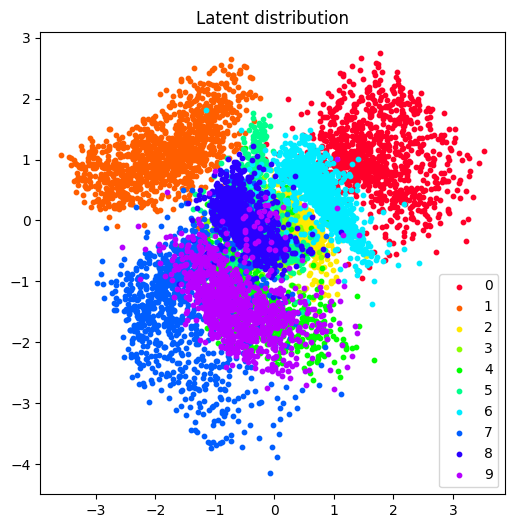

In [7]:
# Plot latent space distribution
model.eval()
latent_vectors = []
labels = []

with torch.no_grad():
    for data, target in test_loader:
        data = data.to(DEVICE)
        mu, _ = model.encode(data)
        latent_vectors.append(mu.cpu())
        labels.append(target.cpu())

z_test = torch.cat(latent_vectors, dim=0).numpy()
y_test = torch.cat(labels, dim=0).numpy()

# Display a 2D plot of the digit classes in the latent space
fig, ax = plt.subplots(figsize=(6,6))
cm = plt.get_cmap('gist_rainbow')
ax.set_prop_cycle(color=[cm(1.*i/(10)) for i in range(10)])
for l in range(10):
    # Only select indices for corresponding label
    ind = y_test == l
    ax.scatter(z_test[ind, 0], z_test[ind, 1], label=str(l), s=10)
ax.legend()
plt.title("Latent distribution")
plt.show()

The distribution of the encoded means shows how they are clustered by class too, as in the autoencoder case. However, in this case, the distribution also follows a kind of circular distribution around the centre due to the Kullback Leibler divergence term in the loss. We made the $\mu_x$ output by the encoder to be close to zero, and $\sigma_x$ to be close to 1.

Now let's start with the generation of data, which is the main reason we trained this model.

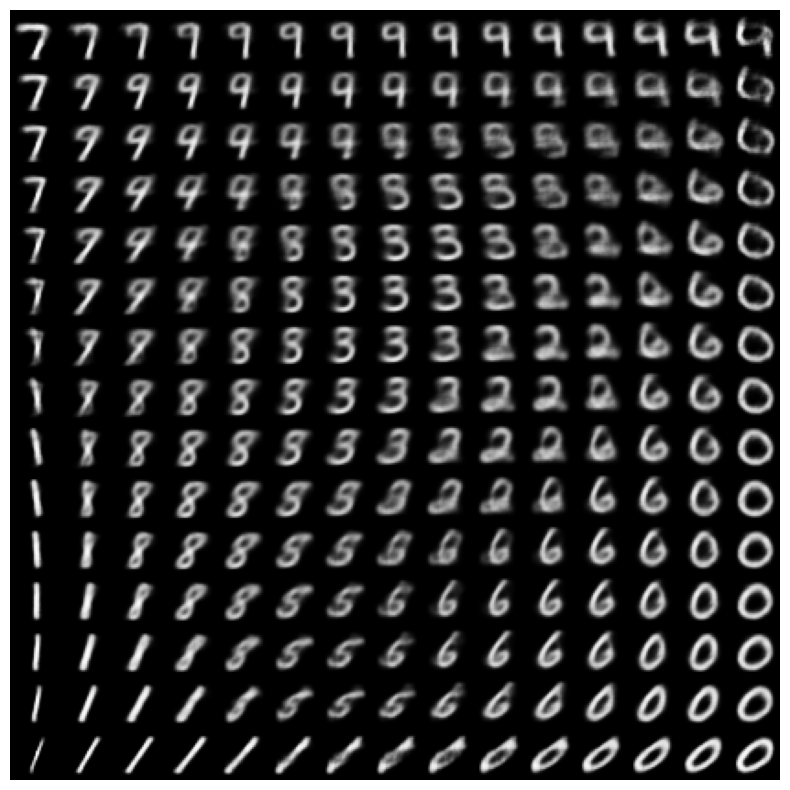

In [8]:
# Display a 2D manifold of the digits
n = 15  # figure with 15x15 digits
digit_size = 28

# Linearly spaced coordinates transformed through inverse CDF of Gaussian
z1 = stats.norm.ppf(np.linspace(0.01, 0.99, n))
z2 = stats.norm.ppf(np.linspace(0.01, 0.99, n))
z_grid = np.dstack(np.meshgrid(z1, z2))

# Generate images from grid
with torch.no_grad():
    z_tensor = torch.FloatTensor(z_grid.reshape(n*n, latent_dim)).to(DEVICE)
    x_pred = model.decoder(z_tensor).cpu().numpy()

x_pred_grid = x_pred.reshape(n, n, digit_size, digit_size)

plt.figure(figsize=(10, 10))
plt.imshow(np.block(list(map(list, x_pred_grid))), cmap='gray')
plt.axis('off')
plt.show()

You can see in the image how there is a smooth transition between the different generated numbers.

Now let's generate a nice animation for the latent variable, where we show the point we used in $z$ to generate the data and the corresponding image generated.

In [9]:
## We create a 2d array
# Number of points to use, increase it for smoother animation
# Using more points makes the function slower
n_points = 50
# theta from 0 to 2pi
theta = np.linspace(0, 2*np.pi, n_points)
# radius of the circle (change it depending on your reprentation space plot)
r = 1
# compute x and y (you can add an offset depending on your latent space)
offset_x = 0
offset_y = 0
x = r*np.cos(theta) + offset_x
y = r*np.sin(theta) + offset_y
latent = np.stack([x, y], -1)

## We now plot as before the 2d scatter with the images from the test set
## and the corresponding label
# Get test latent vectors
model.eval()
with torch.no_grad():
    z_test = []
    for data, _ in test_loader:
        mu, _ = model.encode(data.to(DEVICE))
        z_test.append(mu.cpu())
    z_test = torch.cat(z_test).numpy()

# Create figure
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# First subplot: latent space with test points
ax[0].set_prop_cycle(color=[plt.cm.gist_rainbow(1.*i/10) for i in range(10)])
for l in range(10):
    ind = y_test == l
    ax[0].scatter(z_test[ind, 0], z_test[ind, 1], label=str(l), s=10)
ax[0].legend()
scat = ax[0].scatter(latent[0,0], latent[0,1], s=200, c='k')

# Second subplot: generated image
with torch.no_grad():
    latent_tensor = torch.FloatTensor(latent).to(DEVICE)
    latent_im = model.decoder(latent_tensor).cpu().numpy()

im = ax[1].imshow(latent_im[0].reshape(28, 28), cmap='gray')
ax[1].axis('off')

# Animation update function
def updatefig(i):
    scat.set_offsets(latent[i])
    im.set_array(latent_im[i].reshape(28, 28))
    return im,

# Create animation
anim = animation.FuncAnimation(fig, updatefig, frames=n_points, interval=200, blit=True)
plt.close()
HTML(anim.to_html5_video())

# Generative Adversarial Networks



![](http://2018.igem.org/wiki/images/4/48/T--Vilnius-Lithuania-OG--introduction1.png)
[Image source](https://2018.igem.org/Team:Vilnius-Lithuania-OG/Gan_Introduction)

Generative Adversarial Networks have been shown to improve the generation of data compared to approaches such as VAE.

As you learnt in the lecture, we have two networks playing what is called a min max game between them. The Generator, $G$, tries to generate data that looks similar to real data, whereas the discriminator $D$ tries to distinguish between real and fake data.

We first define $G$ here, and in this case we will use a convolutional network. Notice that we use what is called LeakyReLU for the activation functions, which have been shown to work well when using GANs. $G$ will take a vector of noise sampled from $N(0, 1)$ and output a generated image. We use `tanh` as the last activation because the data will be normalized to be between $[-1, 1]$.

In [10]:
class Generator(nn.Module):
    def __init__(self, dim_latent=1024):
        super(Generator, self).__init__()
        self.dim_latent = dim_latent
        self.main = nn.Sequential(
            # Input is random noise vector of size dim_latent
            nn.Linear(self.dim_latent, 128 * 7 * 7),
            nn.LeakyReLU(0.2),
            nn.Unflatten(1, (128, 7, 7)),  # Reshape to (128, 7, 7)

            # Upsample to (128, 14, 14)
            nn.ConvTranspose2d(
                in_channels=128,
                out_channels=128,
                kernel_size=(4, 4),
                stride=(2, 2),
                padding=(1, 1),
            ),
            nn.LeakyReLU(0.2),

            # Upsample to (128, 28, 28)
            nn.ConvTranspose2d(
                in_channels=128,
                out_channels=128,
                kernel_size=(4, 4),
                stride=(2, 2),
                padding=(1, 1),
            ),
            nn.LeakyReLU(0.2),

            # Output
            nn.Conv2d(
               in_channels=128, out_channels=1, kernel_size=(3, 3), padding=(1, 1)
            ),
            nn.Tanh()  # range [-1, 1]
        )

    def forward(self, input):
        return self.main(input)


# Show model summary
torchinfo.summary(Generator(), input_size=(1, 1024))

Layer (type:depth-idx)                   Output Shape              Param #
Generator                                [1, 1, 28, 28]            --
├─Sequential: 1-1                        [1, 1, 28, 28]            --
│    └─Linear: 2-1                       [1, 6272]                 6,428,800
│    └─LeakyReLU: 2-2                    [1, 6272]                 --
│    └─Unflatten: 2-3                    [1, 128, 7, 7]            --
│    └─ConvTranspose2d: 2-4              [1, 128, 14, 14]          262,272
│    └─LeakyReLU: 2-5                    [1, 128, 14, 14]          --
│    └─ConvTranspose2d: 2-6              [1, 128, 28, 28]          262,272
│    └─LeakyReLU: 2-7                    [1, 128, 28, 28]          --
│    └─Conv2d: 2-8                       [1, 1, 28, 28]            1,153
│    └─Tanh: 2-9                         [1, 1, 28, 28]            --
Total params: 6,954,497
Trainable params: 6,954,497
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 264.36
Input size (MB): 

Here, we define the discriminator $D$. The discriminator is trained with the `nn.BCELoss`, as its job is to discriminate between real and fake data.

In [11]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input: 1x28x28 image
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            # 64x14x14
            nn.Conv2d(64, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            # 64x7x7
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)


# Print model summary
torchinfo.summary(Discriminator(), input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Discriminator                            [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Conv2d: 2-1                       [1, 64, 14, 14]           1,088
│    └─LeakyReLU: 2-2                    [1, 64, 14, 14]           --
│    └─Conv2d: 2-3                       [1, 64, 7, 7]             65,600
│    └─LeakyReLU: 2-4                    [1, 64, 7, 7]             --
│    └─Flatten: 2-5                      [1, 3136]                 --
│    └─Linear: 2-6                       [1, 1]                    3,137
│    └─Sigmoid: 2-7                      [1, 1]                    --
Total params: 69,825
Trainable params: 69,825
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 3.43
Input size (MB): 0.00
Forward/backward pass size (MB): 0.13
Params size (MB): 0.28
Estimated Total Size (MB): 0.41

We defined the combined network, which wraps the generator and discriminator in a single network.

In [12]:
class GAN(nn.Module):
    def __init__(self, dim_latent=1024):
        super(GAN, self).__init__()
        self.dim_latent = dim_latent
        self.generator = Generator(self.dim_latent)
        self.discriminator = Discriminator()

    def generate(self, z):
        return self.generator(z)

    def discriminate(self, image):
        return self.discriminator(image)

    def forward(self, z):
        return self.generator(z)

We also need some other helper functions for the training.

In [13]:
# Data Generation
def create_real_label(batch_size):
    """Create labels as 1 for real images."""
    return torch.ones(batch_size, 1, device=DEVICE)

def create_fake_label(batch_size):
    """Create labels as 0 for generated images."""
    return torch.zeros(batch_size, 1, device=DEVICE)

def create_noise(batch_size, dim_latent=1024):
    """Create random noise."""
    return torch.randn(batch_size, dim_latent, device=DEVICE)


# Plot
def plot_loss(losses):
    """Plot discriminator and generator loss during training"""
    plt.figure(figsize=(10, 5))
    plt.plot(losses["d"], label='Discriminator Loss')
    plt.plot(losses["g"], label='Generator Loss')
    plt.title("Training Losses")
    plt.xlabel("Iteration")
    plt.ylabel("BCELoss")
    plt.legend()
    plt.savefig('./loss.png')
    plt.close()

def generate_and_plot_images(gan, num_images=16, dim=(4,4), figsize=(10,10)):
    """Generate and plot images from the generator"""
    # Generate images
    noise = create_noise(num_images)
    with torch.no_grad():
        images = gan.generate(noise).cpu().numpy()
    images = images.reshape(-1, 28, 28)
    images = (images + 1) / 2.0  # From [-1, 1] to [0, 1] for plotting

    # Reshape and plot
    plt.figure(figsize=figsize)
    for i in range(num_images):
        plt.subplot(dim[0], dim[1], i+1)
        plt.imshow(images[i], cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.savefig('./images.png')
    plt.close()

We will not use the regular training pipeline for GAN, as it is optimized in an adversarial style. In practice, the training at each iteration contains two parts:
* **First part - Training the discriminator:** In this part, only the discriminator is trained.  The generator will output some fake images using noise as input. Then, we will give the discriminator these generated images and some images sampled from the real dataset and train it to distinguish between the two of them.

* **Second part: Training the generator**: We use the generator to output fake images again, and the discriminator will try to guess if these newly generated images are real or fake. However, the aim in this second step is not to update the discriminator, only the generator. This is why in the combined network we made the discriminator not to be trainable. The discriminator is used to pass information (i.e., gradient) to update the generator. Hence, the generator will try to change its weights to make the discriminator think the data comes from the real distribution.

In [14]:
# Discriminator Training
def train_discriminator(image_real, gan, optimizer_d, criterion):
    # Generate labels and noise
    batch_size = image_real.size(0)
    label_real = create_real_label(batch_size)
    label_fake = create_fake_label(batch_size)
    noise = create_noise(batch_size)

    # Generate image
    image_generated = gan.generate(noise).detach()  # Detach is required as only discriminator is updated in this step

    # Train discriminator
    optimizer_d.zero_grad()
    ## Train discriminator to discriminate real images
    label_real_predicted = gan.discriminate(image_real)
    loss_real = criterion(label_real_predicted, label_real)
    ## Train discriminator to discrminate fake images
    label_fake_predicted = gan.discriminate(image_generated)
    loss_fake = criterion(label_fake_predicted, label_fake)
    ## Backpropagate and optimize
    loss = (loss_real + loss_fake) / 2.0  # Dividing by 2 to keep the loss scale
    loss.backward()
    optimizer_d.step()

    return loss.item()

In [15]:
# Generator Training
def train_generator(image_real, gan, optimizer_g, criterion):
    # Generate labels and noise
    batch_size = image_real.size(0)
    label_real = create_real_label(batch_size)
    noise = create_noise(batch_size)

    # Train generator
    optimizer_g.zero_grad()
    ## Generate fake images
    image_generated = gan.generate(noise)
    ## Use discriminator to judge whether the generated images are real or not
    label_predicted = gan.discriminate(image_generated)
    loss = criterion(label_predicted, label_real)
    ## Backpropagate and update
    loss.backward()
    optimizer_g.step()  # Discriminator is not updated as optimizer_g doesn't contain its parameters

    return loss.item()

Let's start the training process. We will use MNIST again. A standard practice for GANs is to normalize images to the range $[-1, 1]$. You could try training it for 50 epochs to see better results.

In [16]:
set_seed(42)

# Training Configuration
epochs = 10
batch_size = 1024
lr = 2.0e-4
betas = (0.5, 0.999)
dim_latent = 1024
plt_frq = 10


# Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# Model, Optimizer, Criterion
gan = GAN(dim_latent).to(DEVICE)
optimizer_d = optim.Adam(gan.discriminator.parameters(), lr=lr, betas=betas)
optimizer_g = optim.Adam(gan.generator.parameters(), lr=lr, betas=betas)
criterion = nn.BCELoss()

# Monitoring
losses = {"d": [], "g": []}
total_iter = 0
saved_images = []
saved_iterations = []

progress_out = widgets.Output()
plot_out = widgets.Output()
display(progress_out)
display(plot_out)

def update_plots(iteration, gan):
    global saved_images, saved_iterations
    with plot_out:
        plot_out.clear_output(wait=True)
        generate_and_plot_images(gan)

        # Read the saved image file and append the image data
        img_data = mpimg.imread('images.png')
        saved_images.append(img_data)
        saved_iterations.append(iteration)

        # Display the last saved image
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        ax.imshow(img_data)
        ax.axis('off')
        ax.set_title(f'Iteration: {iteration}')
        plt.tight_layout()
        display(fig)
        plt.close(fig)


# Training
for epoch in range(1, epochs+1):
    with progress_out:
        pbar = tqdm(total=len(train_loader), desc=f"Epoch {epoch}", leave=True)

        for i, (image_real, _) in enumerate(train_loader):
            total_iter += 1
            image_real = image_real.to(DEVICE)

            # ---------------------
            # Train Discriminator
            # ---------------------
            loss_d = train_discriminator(image_real, gan, optimizer_d, criterion)
            losses["d"].append(loss_d)

            # -----------------
            # Train Generator
            # -----------------
            loss_g = train_generator(image_real, gan, optimizer_g, criterion)
            losses["g"].append(loss_g)

            # Progress bar
            pbar.set_postfix({"loss_d": f"{loss_d:.4f}", "loss_g": f"{loss_g:.4f}"})
            pbar.update(1)

            # Plot periodically
            if total_iter % plt_frq == 0:
                update_plots(total_iter, gan)

        pbar.close()

Output()

Output()

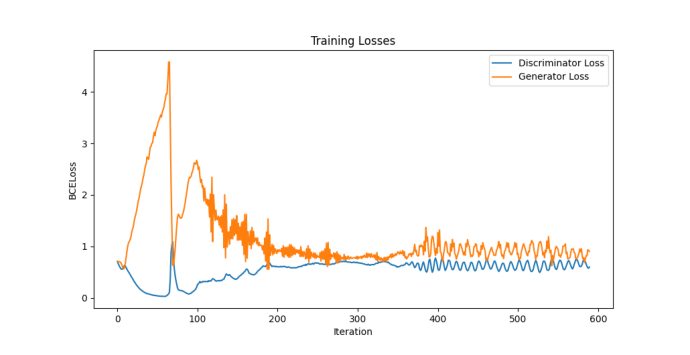

In [17]:
# Plot final losses
plot_loss(losses)
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
img = mpimg.imread('loss.png')
ax.imshow(img)
ax.axis('off')
plt.tight_layout()

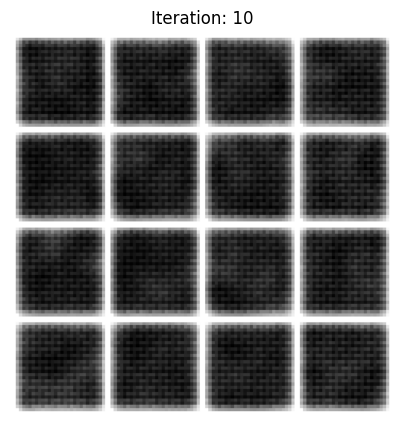

In [18]:
# Create animation
fig_anim, ax_anim = plt.subplots(figsize=(5, 5))
# Use the first saved image data directly
im_anim = ax_anim.imshow(saved_images[0])
ax_anim.axis('off')
title_text = ax_anim.set_title(f'Iteration: {saved_iterations[0]}')

def update_frame(i):
    # Use the saved image data for updating the frame
    im_anim.set_array(saved_images[i])
    title_text.set_text(f'Iteration: {saved_iterations[i]}')
    return im_anim, title_text

anim = animation.FuncAnimation(fig_anim, update_frame, frames=len(saved_images),
                              interval=500, blit=False, repeat=False)

# Display animation
HTML(anim.to_html5_video())

The plots show that: (1) Before 200 iterations, generator loss quickly drops, meaning that it is quickly learning how to generate images from random noise; (2) After 200 iterations, the generator and discriminator loss fluctuates around a certain value, meaning that they are competing with each other and no one is taking a dominant role. It is worth noting that although there is no clear loss drop/convergence in this case, it can be seen from the visualization that the generator is getting more realistic images as the training goes.

Now let’s explore the generator’s latent space using a random walk. Starting from a single randomly sampled latent vector $z \in \mathbb{R}^{1024}$, we iteratively add small random perturbations to create a sequence of latent vectors.
Each step moves slightly in a random direction within the high-dimensional latent space.
By generating images along this trajectory, we can observe how the generator smoothly transforms digits as we “walk” through the latent space.

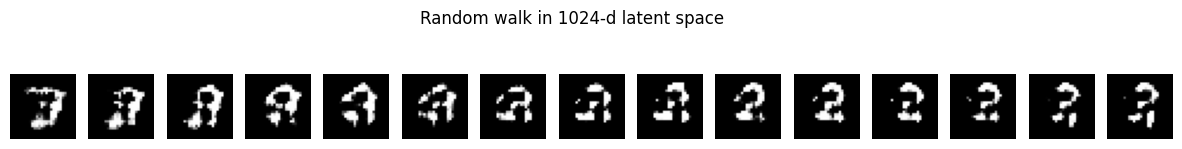

In [19]:
# Change seed here to see different samples
set_seed(0)

# Random walk in latent space (dim_latent = 1024)
n = 15  # number of steps in the walk
digit_size = 28

# Start from a random latent vector
z_start = np.random.normal(0, 1, size=(dim_latent,))

# Define step size for the walk (smaller = smoother changes)
step_size = 0.7

# Collect latent vectors along the walk
z_walk = [z_start]
for i in range(1, n):
    step = np.random.normal(0, step_size, size=(dim_latent,))
    z_next = z_walk[-1] + step
    z_walk.append(z_next)

z_walk = np.stack(z_walk, axis=0).astype(np.float32)

# Generate images from the latent walk
with torch.no_grad():
    z_tensor = torch.from_numpy(z_walk).float().to(DEVICE)
    x_pred = gan.generate(z_tensor).cpu().numpy()

# Rescale from [-1, 1] to [0, 1]
x_pred = (x_pred + 1) / 2.0

# Plot results
plt.figure(figsize=(15, 2))
for i in range(n):
    plt.subplot(1, n, i+1)
    img = x_pred[i].reshape(digit_size, digit_size)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle("Random walk in 1024-d latent space")
plt.show()

**Training instability**

GANs are quite difficult to train as there are several factors that can hurt their performance. Some of the most frequent issues are:

* [Mode collapsing](https://www.youtube.com/watch?v=ktxhiKhWoEE): The generator is not capable of creating diverse images, it only generates a limited set of images.
* Discriminator loss decreases quickly: in some cases the discriminator may be too powerful, so it quickly learns at the beginning which images are fake and which real, leading to small gradients passed to the generator.
* Hyper parameter sensitivity
* Non-convergence

There are some tricks that have been shown to improve convergence, some of them are shared in this [repo](https://github.com/soumith/ganhacks).



# Inception Score


The evaluation of a generative model quantitatively is a problem that is being research. The metric should evaluate the coverage, i.e. how diverse the generated data is, and sample quality, which is related to the visual quality of the sample. A widely used metric is the Inception Score, which is defined as:
$$
\text{IS}(G)= \exp(\mathbb{E}_{x\sim p_a}\ D_{KL}(p(y|x)||p(y)))
$$
Let's explain the term a little bit. We aim to have a high IS, which means that we want a high $D_{KL}$ between $p(y|x)$ and $p(y)$. Ideally, what we want is $p(y|x)$ to be "peaky" and $p(y)$ to be uniform. $p(y|x)$ is the predicted probability vector $y$ given a generated sample $x$ by a model, in this case an Inception model (hence, the name of the score). If the sample $x$ is of high quality, the model should classify it with confidence in one of the available classes, hence the "peaky" $p(y|x)$. The term $p(y)$ is related to the diversity of the data, and is the marginal probability computed as $\int_z p(y|x=G(z))dz$, hence we average the predicted probabilites of the Inception model for the given samples. If the data is diverse, we will see approximately obtain a flat $p(y)$.

In this case, we will be using a pre-trained MNIST classifier as the inception model.

In [20]:
!wget https://raw.githubusercontent.com/MatchLab-Imperial/deep-learning-course/master/asset/07_VAE_GAN/mnist_classifier_best.pth -O mnist_classifier_best.pth

--2026-03-15 22:43:50--  https://raw.githubusercontent.com/MatchLab-Imperial/deep-learning-course/master/asset/07_VAE_GAN/mnist_classifier_best.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 387892 (379K) [application/octet-stream]
Saving to: ‘mnist_classifier_best.pth’

mnist_classifier_be 100%[===================>] 378.80K  --.-KB/s    in 0.004s  

2026-03-15 22:43:50 (90.1 MB/s) - ‘mnist_classifier_best.pth’ saved [387892/387892]



In [21]:
# Inception model
class MNISTClassifier(nn.Module):
    def __init__(self):
        super(MNISTClassifier, self).__init__()
        self.model = nn.Sequential(
            # Conv2d_1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Conv2d_2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Conv2d_3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # Pool and dense
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.model(x)

# Print the model summary
torchinfo.summary(MNISTClassifier(), input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
MNISTClassifier                          [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Conv2d: 2-1                       [1, 32, 28, 28]           320
│    └─BatchNorm2d: 2-2                  [1, 32, 28, 28]           64
│    └─ReLU: 2-3                         [1, 32, 28, 28]           --
│    └─MaxPool2d: 2-4                    [1, 32, 14, 14]           --
│    └─Conv2d: 2-5                       [1, 64, 14, 14]           18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 14, 14]           128
│    └─ReLU: 2-7                         [1, 64, 14, 14]           --
│    └─MaxPool2d: 2-8                    [1, 64, 7, 7]             --
│    └─Conv2d: 2-9                       [1, 128, 7, 7]            73,856
│    └─BatchNorm2d: 2-10                 [1, 128, 7, 7]            256
│    └─ReLU: 2-11                        [1, 128, 7, 7]            --
│   

In [22]:
def compute_inception_score(model, dim_latent, num_images=10000, batch_size=128, denormalize=True, eps=1.0e-16):
    """Compute Inception Score directly from a generator."""
    model.eval()

    # Generate images
    noise = create_noise(num_images, dim_latent)
    with torch.no_grad():
        x_pred = model(noise)

    # Pre-process images
    if len(x_pred.shape) == 2:  # flattened
        x_pred = x_pred.view(num_images, 1, 28, 28)
    if denormalize:
        x_pred = (x_pred + 1.0) / 2.0  # from [-1,1] → [0,1]

    # Compute probabilities
    classifier = MNISTClassifier().to(DEVICE)
    classifier.load_state_dict(torch.load('./mnist_classifier_best.pth'))
    classifier.eval()

    preds = []
    with torch.no_grad():
        for i in range(0, num_images, batch_size):
            logits = classifier(x_pred[i:i+batch_size])
            probs = F.softmax(logits, dim=1)
            preds.append(probs)
    preds = torch.concat(preds, axis=0)

    # Compute inception score
    # Marginal distribution p(y)
    p_y = preds.mean(dim=0, keepdim=True)  # [1, C]

    # KL divergence: sum_y p(y|x) log (p(y|x)/p(y))
    kl_div = preds * (torch.log(preds + eps) - torch.log(p_y + eps))
    kl_div = kl_div.sum(dim=1)  # [N]

    # Mean KL divergence → IS
    return torch.exp(kl_div.mean()).item()

Now let's check the Inception Score for the GAN model we have trained before.

In [23]:
# Compute Inception Score for the trained GAN generator
is_score = compute_inception_score(gan, gan.dim_latent)

print(f"Inception Score: {is_score:.4f}")

Inception Score: 3.6564


# Conditional Generative Adversarial Networks (cGANs)

A [Conditional GAN (cGAN)](https://arxiv.org/abs/1411.1784) is a variant of classical Generative Adversarial Networks, where the task is conditioned on some extra information instead of random noise. They were introduced in 2014, , and set a new state of the art in many image tasks.

In this setting, cGANs expect an input image instead of a random noise vector. A simple example of image translation is the drawing to real object transformation. To do so, imagine that we have two different paired domains, images of the real objects (domain A) and drawing of objects (domain B), and we want to go from one to the other. In classical GANs, we used these two domains for training the architectures, but here we can also condition the input to one of the images in the domain B, and use the relationship between the domains to guide the network to the desired result:

<a href="https://imgbb.com/"><img src="https://i.ibb.co/rF2w5Tt/Screenshot-from-2019-02-25-15-47-18.png" alt="Screenshot-from-2019-02-25-15-47-18" border="0"></a>

As in regular GANs, the discriminator learns to classify between fake (synthesized by the generator) and real {drawing, photo} tuples. Hence, the generator will try to fool the discriminator with better and better synthesised images. In contrast to GANS, as we feed the drawing directly to the generator, the information that the network can use to seek convergence is much wider.

## Image-to-image Translation with cGANs


[Image-to-image Translation with Conditional Adversarial Networks](https://arxiv.org/abs/1611.07004) is a paper presented at the Computer Vision and Pattern Recognition (CVPR) conference in 2017. In their paper, the authors introduced Pix2pix, a conditional GAN, to transform images from one domain to another. The authors in the paper investigated conditional adversarial networks as a general-purpose solution to image-to-image translation problems, see some examples from the paper of different Image-to-Image tasks:

>

![texto alternativo](https://i.ibb.co/Mf08787/examples.jpg)

In this tutorial, we will explain and implement Pix2pix model for colouring images step by step.

## Colouring Black and White Images
The tutorial aims to build the Pix2pix code for colouring images. We will use CIFAR10 dataset to perform the experiment, however, you could try to use any other dataset. For instance, check [this repo](https://github.com/kvfrans/deepcolor) which shows how to colour manga-style images.

The idea is quite simple. First, we will transform images into black and white (BW) and train a generator that will transform them back to RGB images. As in classical GANs, we use the discriminator to differentiate between *Fake* and *Real* images.

Thus, we have domain A (colour) and domain B (B&W).

Let's define a customized data loader that can load both coloured and grayscaled images.

In [42]:
class Cifar(Dataset):
    def __init__(self, name="CIFAR10", root="./data", train=True, download=True):
        self.rgb_norm = transforms.Compose([
            transforms.ToTensor(),                        # [0,1]
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # → [-1,1]
        ])
        self.bw_norm = transforms.Compose([
            transforms.ToTensor(),                        # [0,1]
            transforms.Normalize((0.5,), (0.5,))          # → [-1,1]
        ])

        if name == "CIFAR10":
            self.dataset = datasets.CIFAR10(root=root, train=train, download=download)
        elif name == "CIFAR100":
            self.dataset = datasets.CIFAR100(root=root, train=train, download=download)
        else:
            raise ValueError("Dataset must be CIFAR10 or CIFAR100")

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]  # PIL image, int label

        # RGB normalized [-1,1]
        img_rgb = self.rgb_norm(img)

        # Grayscale normalized [-1,1]
        img_bw = transforms.functional.rgb_to_grayscale(img, num_output_channels=1)
        img_bw = self.bw_norm(img_bw)

        return img_rgb, img_bw

In [25]:
# Check image size
train_dataset = Cifar(train=True)
img_rgb, img_bw = next(iter(train_dataset))

print("RGB image shape:", img_rgb.shape)   # (C, H, W)
print("BW image shape:", img_bw.shape)  # (C, H, W)

100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s] 


RGB image shape: torch.Size([3, 32, 32])
BW image shape: torch.Size([1, 32, 32])


We can visualise images from both domains.

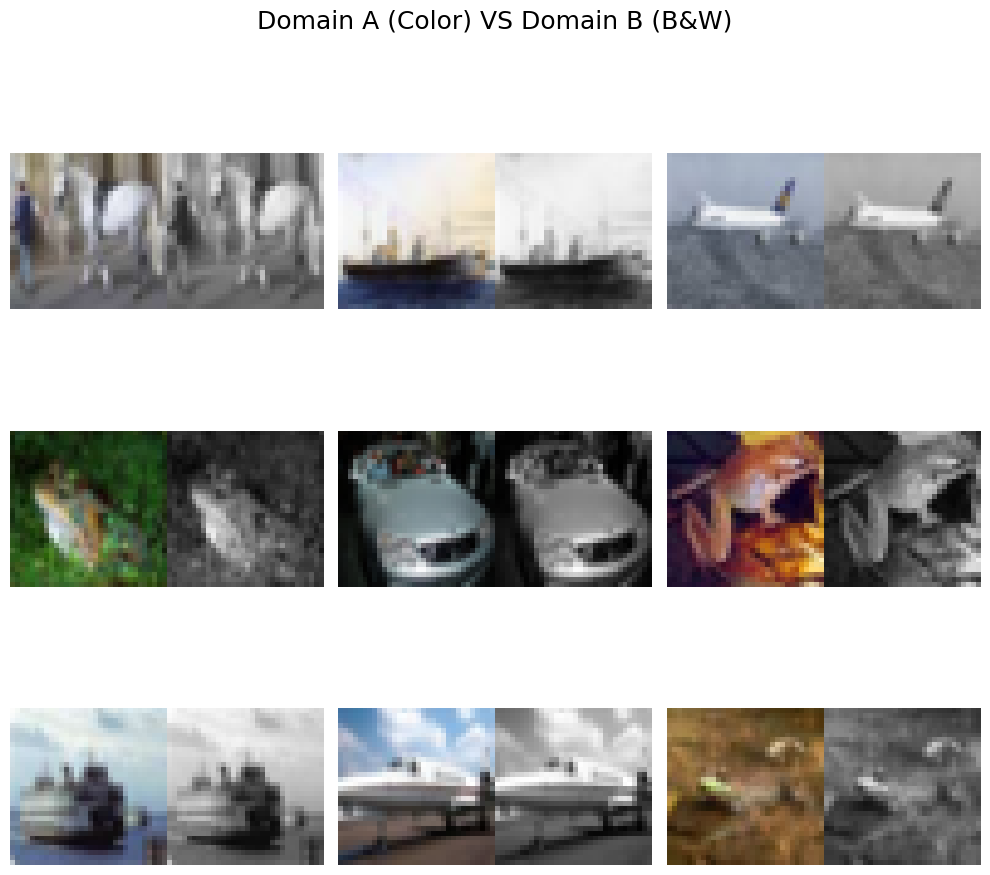

In [26]:
# Change seed to see different samples
set_seed(42)

# Pick a random batch
num_samples = 9
indices = np.random.choice(len(train_dataset), size=num_samples, replace=False)
samples = [train_dataset[i] for i in indices]
imgs_rgb, imgs_bw = zip(*samples)

imgs_rgb = torch.stack(imgs_rgb)
imgs_bw = torch.stack(imgs_bw)

# Convert tensors to numpy and permute dimensions for visualization
imgs_rgb = imgs_rgb.permute(0, 2, 3, 1).cpu().numpy()  # NCHW -> NHWC
imgs_bw = imgs_bw.permute(0, 2, 3, 1).cpu().numpy()      # NCHW -> NHWC

# Denormalize from [-1,1] to [0,1]
imgs_rgb = (imgs_rgb + 1) / 2
imgs_bw = (imgs_bw + 1) / 2

# Repeat grayscale channel to make it 3-channel for visualization
imgs_bw = np.repeat(imgs_bw, 3, axis=3)

# Plot comparison
N = 3
fig, axes = plt.subplots(N, N, figsize=(10, 10))
plt.suptitle('Domain A (Color) VS Domain B (B&W)', fontsize=18)
for row in range(N):
    for col in range(N):
        idx = row * N + col
        combined = np.concatenate((imgs_rgb[idx], imgs_bw[idx]), axis=1)
        axes[row, col].imshow(np.clip(combined, 0, 1))
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## Generator & Discriminator Models

For many image translation problems, there is a great deal of low-level information shared between the input and output. Thus, it is desirable to shuttle this information directly across the net. For example, in the case of image colourization, the input and output share the location of prominent edges. To give the generator a means to circumvent the bottleneck for information like this, we use an architecture with skip connections, following the general shape of the UNet introduced in previous tutorials.

The generator introduced in this tutorial is a simpler version of the one in the paper since we are using low-resolution images (32x32).

In Pix2pix, the authors found that mixing the GAN objective with a more traditional loss, such as L1 loss, improved the final performance. The discriminator’s job remains unchanged, but the generator is tasked to not only fool the discriminator but also to be near the ground-truth output in an L1 sense.

We can define our cGAN generator model.

In [27]:
class CGenerator(nn.Module):
    def __init__(self, im_shape=(32, 32)):
        super(CGenerator, self).__init__()

        # Encoder
        self.conv1 = nn.Conv2d(1, 64, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.pool3 = nn.MaxPool2d(2)
        self.conv4 = nn.Conv2d(256, 512, 3, padding=1)
        self.drop4 = nn.Dropout2d(0.5)
        self.pool4 = nn.MaxPool2d(2)
        self.conv5 = nn.Conv2d(512, 1024, 3, padding=1)
        self.drop5 = nn.Dropout2d(0.5)

        # Decoder with skip connections
        self.up6 = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(1024, 512, 3, padding=1)
        )
        self.conv6 = nn.Conv2d(1024, 512, 3, padding=1)  # Accounts for concatenation

        self.up7 = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(512, 256, 3, padding=1)
        )
        self.conv7 = nn.Conv2d(512, 256, 3, padding=1)

        self.up8 = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(256, 128, 3, padding=1)
        )
        self.conv8 = nn.Conv2d(256, 128, 3, padding=1)

        self.up9 = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, padding=1)
        )
        self.conv9 = nn.Conv2d(128, 64, 3, padding=1)

        self.conv10 = nn.Conv2d(64, 3, 3, padding=1)

    def forward(self, x):
        # Encoder
        conv1 = F.relu(self.conv1(x))
        pool1 = self.pool1(conv1)
        conv2 = F.relu(self.conv2(pool1))
        pool2 = self.pool2(conv2)
        conv3 = F.relu(self.conv3(pool2))
        pool3 = self.pool3(conv3)
        conv4 = F.relu(self.conv4(pool3))
        drop4 = self.drop4(conv4)
        pool4 = self.pool4(drop4)
        conv5 = F.relu(self.conv5(pool4))
        drop5 = self.drop5(conv5)

        # Decoder with skip connections
        up6 = self.up6(drop5)
        merge6 = torch.cat([drop4, up6], dim=1)
        conv6 = F.relu(self.conv6(merge6))

        up7 = self.up7(conv6)
        merge7 = torch.cat([conv3, up7], dim=1)
        conv7 = F.relu(self.conv7(merge7))

        up8 = self.up8(conv7)
        merge8 = torch.cat([conv2, up8], dim=1)
        conv8 = F.relu(self.conv8(merge8))

        up9 = self.up9(conv8)
        merge9 = torch.cat([conv1, up9], dim=1)
        conv9 = F.relu(self.conv9(merge9))

        conv10 = self.conv10(conv9)

        return torch.tanh(conv10)  # Output in [-1, 1] range

torchinfo.summary(CGenerator(), input_size=(1, 1, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
CGenerator                               [1, 3, 32, 32]            --
├─Conv2d: 1-1                            [1, 64, 32, 32]           640
├─MaxPool2d: 1-2                         [1, 64, 16, 16]           --
├─Conv2d: 1-3                            [1, 128, 16, 16]          73,856
├─MaxPool2d: 1-4                         [1, 128, 8, 8]            --
├─Conv2d: 1-5                            [1, 256, 8, 8]            295,168
├─MaxPool2d: 1-6                         [1, 256, 4, 4]            --
├─Conv2d: 1-7                            [1, 512, 4, 4]            1,180,160
├─Dropout2d: 1-8                         [1, 512, 4, 4]            --
├─MaxPool2d: 1-9                         [1, 512, 2, 2]            --
├─Conv2d: 1-10                           [1, 1024, 2, 2]           4,719,616
├─Dropout2d: 1-11                        [1, 1024, 2, 2]           --
├─Sequential: 1-12                       [1, 512, 4, 4]      

Next, we follow the discriminator model definition from the paper:

In [28]:
class CDiscriminator(nn.Module):
    def __init__(self, im_shape=(32, 32)):
        super(CDiscriminator, self).__init__()
        self.im_shape = im_shape

        # Define the model architecture
        self.conv1 = nn.Sequential(
            nn.Conv2d(4, 64, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(0.2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(128, momentum=0.8),
            nn.LeakyReLU(0.2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(256, momentum=0.8),
            nn.LeakyReLU(0.2)
        )
        self.fc = nn.Sequential(
            nn.Linear(256 * (im_shape[0]//8) * (im_shape[1]//8), 1024),
            nn.Linear(1024, 1)
        )

    def forward(self, img_rgb, img_bw):
        # Concatenate inputs along channel dimension
        x = torch.cat((img_rgb, img_bw), dim=1)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

torchinfo.summary(CDiscriminator(), input_data=(torch.randn(1, 3, 32, 32), torch.randn(1, 1, 32, 32)))

Layer (type:depth-idx)                   Output Shape              Param #
CDiscriminator                           [1, 1]                    --
├─Sequential: 1-1                        [1, 64, 16, 16]           --
│    └─Conv2d: 2-1                       [1, 64, 16, 16]           6,464
│    └─LeakyReLU: 2-2                    [1, 64, 16, 16]           --
├─Sequential: 1-2                        [1, 128, 8, 8]            --
│    └─Conv2d: 2-3                       [1, 128, 8, 8]            204,928
│    └─BatchNorm2d: 2-4                  [1, 128, 8, 8]            256
│    └─LeakyReLU: 2-5                    [1, 128, 8, 8]            --
├─Sequential: 1-3                        [1, 256, 4, 4]            --
│    └─Conv2d: 2-6                       [1, 256, 4, 4]            819,456
│    └─BatchNorm2d: 2-7                  [1, 256, 4, 4]            512
│    └─LeakyReLU: 2-8                    [1, 256, 4, 4]            --
├─Sequential: 1-4                        [1, 1]                    --


As before, we can define a simple wrapper that combines the two.

In [29]:
class CGAN(nn.Module):
    def __init__(self, img_shape=(32, 32)):
        super().__init__()
        self.img_shape = img_shape
        self.generator = CGenerator(self.img_shape)
        self.discriminator = CDiscriminator(self.img_shape)

    def generate(self, img):
        return self.generator(img)

    def discriminate(self, img_rgb, img_bw):
        return self.discriminator(img_rgb, img_bw)

    def forward(self, img):
        return self.generator(img)


torchinfo.summary(CGAN(), input_size=(1, 1, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
CGAN                                     [1, 3, 32, 32]            5,227,969
├─CGenerator: 1-1                        [1, 3, 32, 32]            --
│    └─Conv2d: 2-1                       [1, 64, 32, 32]           640
│    └─MaxPool2d: 2-2                    [1, 64, 16, 16]           --
│    └─Conv2d: 2-3                       [1, 128, 16, 16]          73,856
│    └─MaxPool2d: 2-4                    [1, 128, 8, 8]            --
│    └─Conv2d: 2-5                       [1, 256, 8, 8]            295,168
│    └─MaxPool2d: 2-6                    [1, 256, 4, 4]            --
│    └─Conv2d: 2-7                       [1, 512, 4, 4]            1,180,160
│    └─Dropout2d: 2-8                    [1, 512, 4, 4]            --
│    └─MaxPool2d: 2-9                    [1, 512, 2, 2]            --
│    └─Conv2d: 2-10                      [1, 1024, 2, 2]           4,719,616
│    └─Dropout2d: 2-11                   [1, 1024, 2, 

## Training Loop

The training of cGAN is very similar to the vanilla GAN, where we separately train the discriminator and generator. Don't worry too much about this part as the code is provided in case you want to optionally train your own cGANs.

In [30]:
# Conditional Discriminator Training
def train_conditional_discriminator(img_rgb, img_bw, cgan, optimizer_d, criterion):
    # Generate labels
    batch_size = img_rgb.size(0)
    label_real = create_real_label(batch_size)
    label_fake = create_fake_label(batch_size)

    # Generate fake color image
    img_rgb_generated = cgan.generate(img_bw).detach()  # Detach() is required as only the discriminator is updated in this case

    # Discriminate on real and fake pairs
    optimizer_d.zero_grad()

    label_real_predicted = cgan.discriminate(img_rgb, img_bw)
    loss_real = criterion(label_real_predicted, label_real)

    label_fake_predicted = cgan.discriminate(img_rgb_generated, img_bw)
    loss_fake = criterion(label_fake_predicted, label_fake)

    # Backpropagate and update
    loss = (loss_real + loss_fake) / 2
    loss.backward()
    optimizer_d.step()

    # Get accuracy
    real_acc = torch.mean((label_real_predicted > 0.5).float())
    fake_acc = torch.mean((label_fake_predicted < 0.5).float())
    acc = 0.5 * (real_acc + fake_acc)

    return loss.item(), acc.item()

In [31]:
# Conditional Generator Training
def train_conditional_generator(img_rgb, img_bw, cgan, optimizer_g, criterion_gan, criterion_l1, lambda_l1=100):
    # Generate labels
    batch_size = img_rgb.size(0)
    label_real = create_real_label(batch_size)

    # Train generator
    optimizer_g.zero_grad()
    ## Generate fake images
    img_rgb_generated = cgan.generate(img_bw)

    ## Use discriminator to judge whether the generated images are real or not
    label_predicted = cgan.discriminate(img_rgb_generated, img_bw)
    loss_gan = criterion_gan(label_predicted, label_real)

    ## Add reconstruction loss
    loss_l1 = criterion_l1(img_rgb_generated, img_rgb)

    ## Total loss
    loss = loss_gan + lambda_l1 * loss_l1

    ## Backpropagate and update
    loss.backward()
    optimizer_g.step()  # Discriminator is not updated as optimizer_g doesn't contain its parameters

    return loss.item()

We can also define some helper functions to visualize images during training.

In [32]:
def show_colored_images(img_rgb, img_bw, img_rgb_generated):
    # Convert tensors to numpy and denormalize from [-1,1] → [0,1]

    # Grayscale input (BW)
    img_bw_np = img_bw[0].cpu().permute(1, 2, 0).numpy()
    img_bw_np = (img_bw_np * 0.5 + 0.5).squeeze(-1)  # (H,W)

    # Fake RGB (detach to avoid gradients)
    fake_rgb_np = img_rgb_generated[0].detach().cpu().permute(1, 2, 0).numpy()
    fake_rgb_np = (fake_rgb_np * 0.5 + 0.5)  # (H,W,3)

    # Real RGB
    real_rgb_np = img_rgb[0].cpu().permute(1, 2, 0).numpy()
    real_rgb_np = (real_rgb_np * 0.5 + 0.5)  # (H,W,3)

    # Plot
    plt.figure(figsize=(15, 5))

    plt.subplot(131)
    plt.imshow(img_bw_np, cmap="gray")
    plt.title("Input (BW)", fontsize=16)
    plt.axis("off")

    plt.subplot(132)
    plt.imshow(fake_rgb_np)
    plt.title("Generated (Fake RGB)", fontsize=16)
    plt.axis("off")

    plt.subplot(133)
    plt.imshow(real_rgb_np)
    plt.title("Ground Truth (Real RGB)", fontsize=16)
    plt.axis("off")

    plt.show()

def show_colored_two_models(img_rgb, img_bw, img_rgb_generated_mae, img_rgb_generated_cgan):
    # --- Convert tensors to numpy and denormalize [-1,1] → [0,1] ---

    # Grayscale input (BW)
    img_bw_np = img_bw[0].cpu().permute(1, 2, 0).numpy()
    img_bw_np = (img_bw_np * 0.5 + 0.5).squeeze(-1)  # (H,W)

    # Fake RGB from MAE-only model
    fake_rgb_mae_np = img_rgb_generated_mae[0].detach().cpu().permute(1, 2, 0).numpy()
    fake_rgb_mae_np = (fake_rgb_mae_np * 0.5 + 0.5)

    # Fake RGB from cGAN model
    fake_rgb_cgan_np = img_rgb_generated_cgan[0].detach().cpu().permute(1, 2, 0).numpy()
    fake_rgb_cgan_np = (fake_rgb_cgan_np * 0.5 + 0.5)

    # Real RGB
    real_rgb_np = img_rgb[0].cpu().permute(1, 2, 0).numpy()
    real_rgb_np = (real_rgb_np * 0.5 + 0.5)

    # --- Plot ---
    plt.figure(figsize=(20, 5))

    plt.subplot(141)
    plt.imshow(img_bw_np, cmap="gray")
    plt.title("Input (BW)", fontsize=16)
    plt.axis("off")

    plt.subplot(142)
    plt.imshow(fake_rgb_mae_np)
    plt.title("Generated (MAE)", fontsize=16)
    plt.axis("off")

    plt.subplot(143)
    plt.imshow(fake_rgb_cgan_np)
    plt.title("Generated (cGAN)", fontsize=16)
    plt.axis("off")

    plt.subplot(144)
    plt.imshow(real_rgb_np)
    plt.title("Ground Truth (RGB)", fontsize=16)
    plt.axis("off")

    plt.show()

Let's see the training code. Feel free to skip this part and use the provided pre-trained weights.

In [33]:
set_seed(42)

# Training Hyperparameters
img_shape = (32, 32)
num_epochs = 20
batch_size = 128
lr = 2.0e-4
betas = (0.5, 0.999)
lambda_l1 = 100

# Data
train_dataset = Cifar('CIFAR10', train=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Model and optimizer
cgan = CGAN(img_shape).to(DEVICE)
optimizer_g = optim.Adam(cgan.generator.parameters(), lr=lr, betas=betas)
optimizer_d = optim.Adam(cgan.discriminator.parameters(), lr=lr, betas=betas)
cgan.train()

# Loss functions
criterion_gan = nn.MSELoss()  # For adversarial loss
criterion_l1 = nn.L1Loss()    # For pixel-wise loss

# Visualization
plot_out = widgets.Output()
display(plot_out)

def update_plots(img_rgb, img_bw, cgan, iteration=None, save_path="./images.png"):
    """
    Update in-place visualization of Pix2Pix results.
    Shows: Input BW | Generated RGB | Real RGB
    """
    with torch.no_grad():
        img_rgb_generated = cgan.generate(img_bw)

    # Convert tensors → numpy [0,1]
    bw_np = (img_bw[0].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5).squeeze(-1)
    fake_np = (img_rgb_generated[0].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5)
    real_np = (img_rgb[0].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5)

    # Update output widget in place
    with plot_out:
        plot_out.clear_output(wait=True)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        axes[0].imshow(bw_np, cmap="gray")
        axes[0].set_title("Input (BW)")
        axes[0].axis("off")

        axes[1].imshow(fake_np)
        axes[1].set_title("Generated (RGB)")
        axes[1].axis("off")

        axes[2].imshow(real_np)
        axes[2].set_title("Ground Truth (RGB)")
        axes[2].axis("off")

        if iteration is not None:
            plt.suptitle(f"Iteration {iteration}", fontsize=16)

        plt.tight_layout()
        plt.savefig(save_path)
        plt.show()
        plt.close(fig)


# Run training
for epoch in range(num_epochs):
    g_losses, d_losses, d_accs = [], [], []

    pbar = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch}/{num_epochs}")

    for i, (imgs_rgb, imgs_bw) in enumerate(pbar):
        imgs_rgb, imgs_bw = imgs_rgb.to(DEVICE), imgs_bw.to(DEVICE)

        # --- Train Discriminator ---
        d_loss, d_acc = train_conditional_discriminator(
            imgs_rgb, imgs_bw, cgan, optimizer_d, criterion_gan)

        # --- Train Generator ---
        g_loss = train_conditional_generator(
            imgs_rgb, imgs_bw, cgan, optimizer_g, criterion_gan, criterion_l1, lambda_l1)

        # Record metrics
        d_losses.append(d_loss)
        d_accs.append(d_acc)
        g_losses.append(g_loss)

        # Update progress bar
        pbar.set_postfix({
            "D_loss": f"{np.mean(d_losses):.4f}",
            "D_acc": f"{100*np.mean(d_accs):.1f}%",
            "G_loss": f"{np.mean(g_losses):.4f}"
        })

        # Show some images occasionally
        if i % 50 == 0:
            update_plots(imgs_rgb, imgs_bw, cgan, iteration=epoch*len(train_loader) + i)

Output()

Epoch 0/20:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/20:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 2/20:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 3/20:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 15/20:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 16/20:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 17/20:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 18/20:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 19/20:   0%|          | 0/391 [00:00<?, ?it/s]

## Colouring Test Images

We are ready to visualise how the network colours the test images.

In [34]:
!wget https://raw.githubusercontent.com/MatchLab-Imperial/deep-learning-course/master/asset/07_VAE_GAN/cgan_cifar10_epoch20.pth -O cgan_cifar10_epoch20.pth

--2026-03-15 22:55:57--  https://raw.githubusercontent.com/MatchLab-Imperial/deep-learning-course/master/asset/07_VAE_GAN/cgan_cifar10_epoch20.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 96160593 (92M) [application/octet-stream]
Saving to: ‘cgan_cifar10_epoch20.pth’

cgan_cifar10_epoch2 100%[===================>]  91.71M   399MB/s    in 0.2s    

2026-03-15 22:56:04 (399 MB/s) - ‘cgan_cifar10_epoch20.pth’ saved [96160593/96160593]



In [35]:
# Load model from saved file
cgan = CGAN((32, 32)).to(DEVICE)
weight = torch.load('./cgan_cifar10_epoch20.pth')
cgan.load_state_dict(weight)

<All keys matched successfully>

Let's see the results, you can rerun the following code for visualizing more examples:

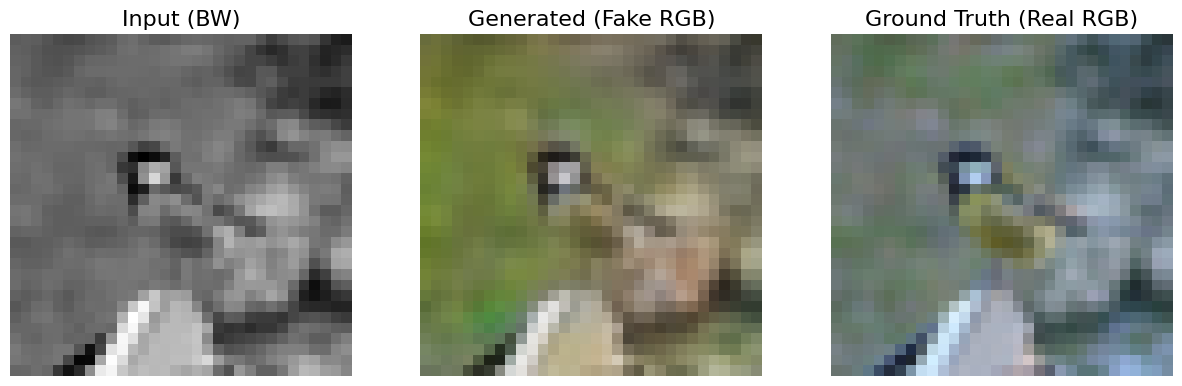

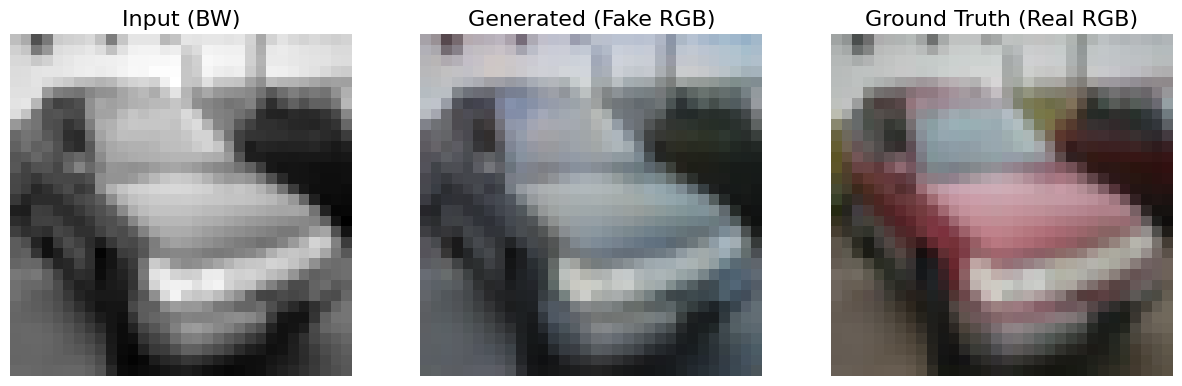

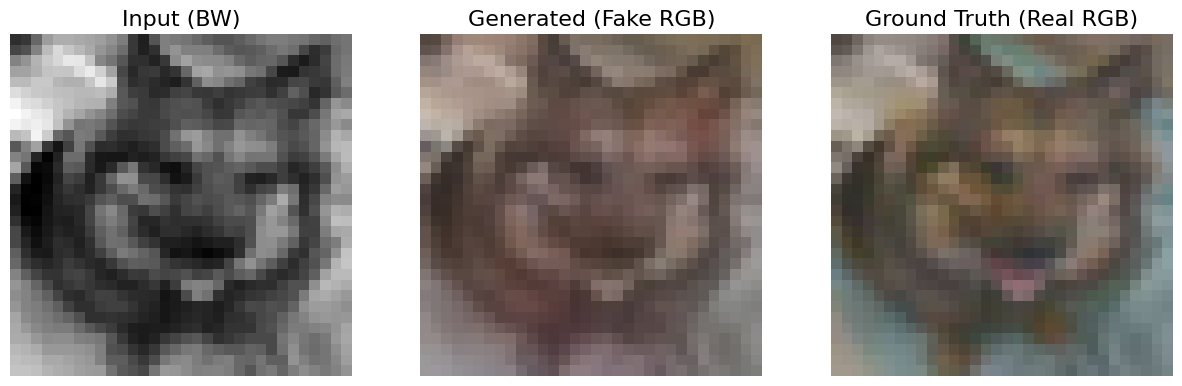

In [36]:
# Change seed here to see different samples
set_seed(42)

# Data
test_dataset = Cifar('CIFAR10', train=False)

# Randomly sample indices for visualization
num_samples = 3
indices = np.random.choice(len(test_dataset), size=num_samples, replace=False)

cgan.eval()
with torch.no_grad():  # Disable gradient calculation for inference
    for idx in indices:
        # Get random batch from test set
        imgs_real, imgs_bw = test_dataset[idx]
        imgs_real = imgs_real.unsqueeze(0).to(DEVICE)
        imgs_bw = imgs_bw.unsqueeze(0).to(DEVICE)

        imgs_real_generated = cgan.generate(imgs_bw)

        # Show results
        show_colored_images(imgs_real, imgs_bw, imgs_real_generated)

The colouring may not be perfect, but the network does a good job at guessing plausible colours. We have shown a simplified version of the Pix2pix method. Training GANs is a hard task, and there are many elements that could be added to improve results. For instance, [this repo](https://github.com/soumith/ganhacks), like many others, shows common tricks to improve GAN performance.

# Coursework



## Task 1: MNIST generation using VAE and GAN

**Report**
* Train the given VAE model in the tutorial also using the same hyper parameters (batch size, optimizer, number of epochs, etc...) but increasing the latent dimensionality to 10. Compute the MSE on the reconstructed `x_test` images and Inception Score (IS). Now train the same model without the KL divergence loss, and compute again the MSE and IS score. Report the results in a table and discuss them. For the IS you can use in this case `compute_inception_score(model, 10, denormalize=False)`.

* Train the GAN given in the tutorial with increased dimensionality of the initial random sample to 10 for 10 epochs and report its IS (use the same table as in the VAE case). Discuss the difference in the obtained IS for VAE and GAN and link it to the qualitative results. For the IS use in this case `compute_inception_score(model, 10, denormalize=True)`.



## Task 2: Quantitative VS Qualitative Results

In this task, we will observe the difference between two trained models for colouring images. One is the model trained during the tutorial, which uses a cGAN approach to predict the RGB pixel-wise values of a B&W image. The other one is a simple UNet autoencoder trained with a Mean Absolute Error (MAE) loss, which is trained to predict directly the RBG image without any GAN based learning strategy. We refer to the first and second models as cGAN and MAE models, respectively. For this task, 20 epochs trained weights for the cGAN and MAE models are provided. If desired, the code to train the MAE model can be found below:

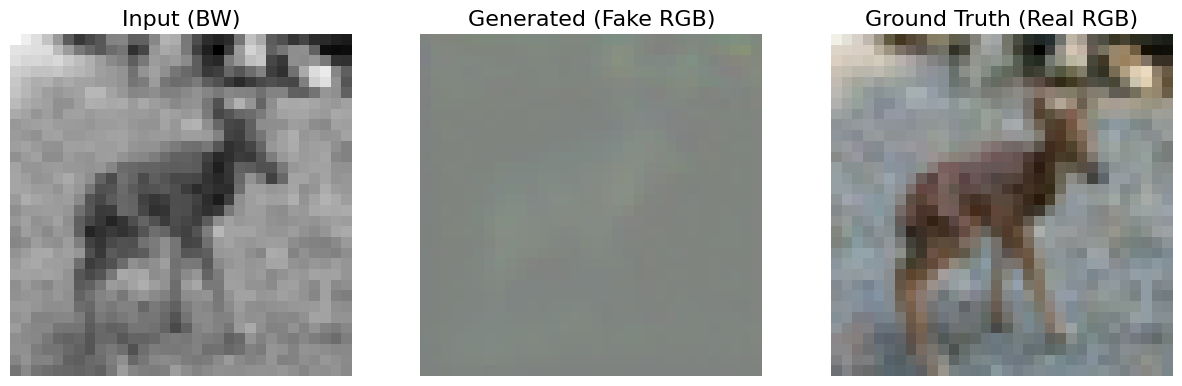

[Epoch 0/20] [Batch 0/391] [G loss: 0.4463] 
[Epoch 0/20] [Batch 10/391] [G loss: 0.3602] 
[Epoch 0/20] [Batch 20/391] [G loss: 0.2831] 
[Epoch 0/20] [Batch 30/391] [G loss: 0.2464] 
[Epoch 0/20] [Batch 40/391] [G loss: 0.2243] 


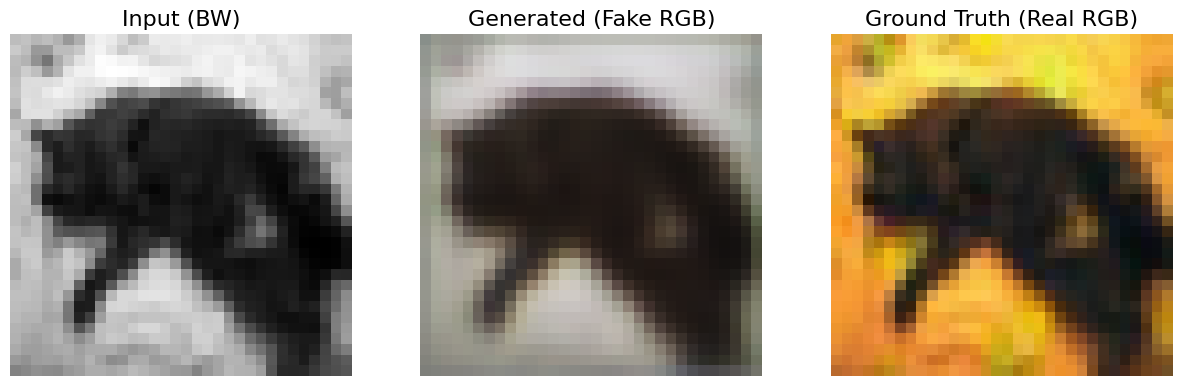

[Epoch 0/20] [Batch 50/391] [G loss: 0.2099] 
[Epoch 0/20] [Batch 60/391] [G loss: 0.1985] 
[Epoch 0/20] [Batch 70/391] [G loss: 0.1900] 
[Epoch 0/20] [Batch 80/391] [G loss: 0.1824] 
[Epoch 0/20] [Batch 90/391] [G loss: 0.1763] 


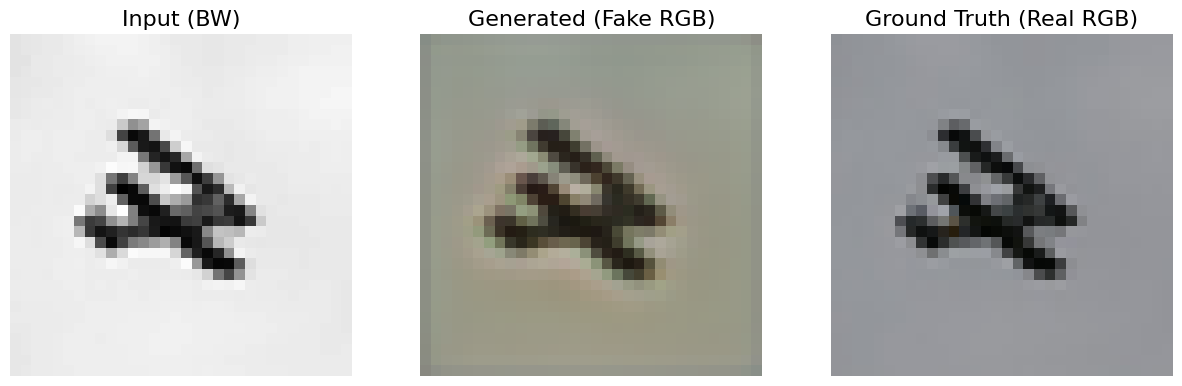

[Epoch 0/20] [Batch 100/391] [G loss: 0.1706] 
[Epoch 0/20] [Batch 110/391] [G loss: 0.1663] 
[Epoch 0/20] [Batch 120/391] [G loss: 0.1621] 
[Epoch 0/20] [Batch 130/391] [G loss: 0.1587] 
[Epoch 0/20] [Batch 140/391] [G loss: 0.1552] 


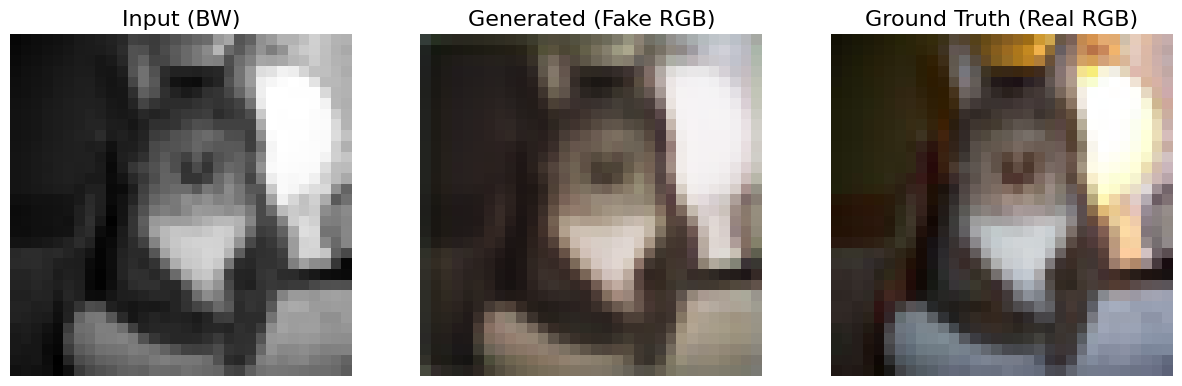

[Epoch 0/20] [Batch 150/391] [G loss: 0.1524] 
[Epoch 0/20] [Batch 160/391] [G loss: 0.1499] 
[Epoch 0/20] [Batch 170/391] [G loss: 0.1476] 
[Epoch 0/20] [Batch 180/391] [G loss: 0.1454] 
[Epoch 0/20] [Batch 190/391] [G loss: 0.1436] 


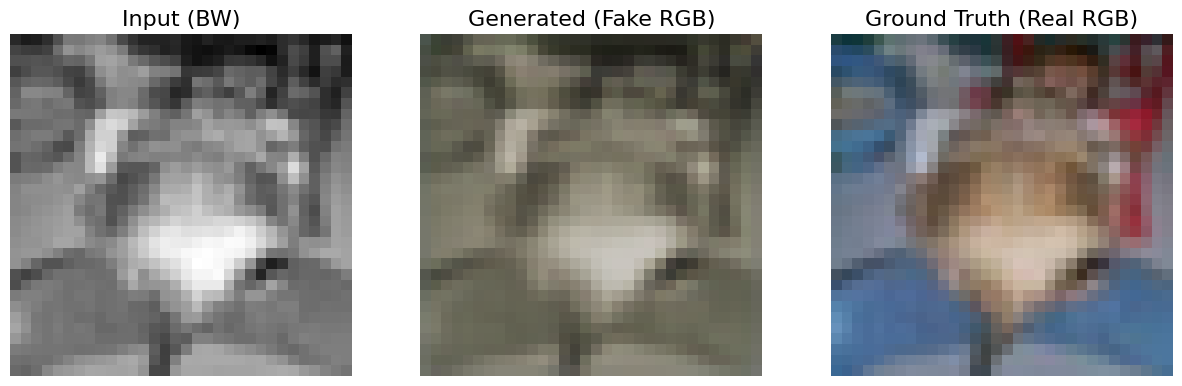

[Epoch 0/20] [Batch 200/391] [G loss: 0.1418] 
[Epoch 0/20] [Batch 210/391] [G loss: 0.1402] 
[Epoch 0/20] [Batch 220/391] [G loss: 0.1386] 
[Epoch 0/20] [Batch 230/391] [G loss: 0.1370] 
[Epoch 0/20] [Batch 240/391] [G loss: 0.1356] 


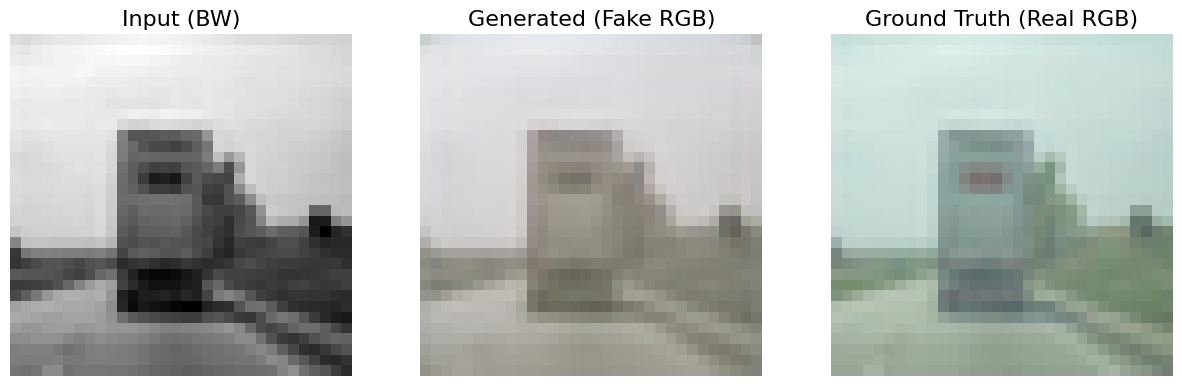

[Epoch 0/20] [Batch 250/391] [G loss: 0.1343] 
[Epoch 0/20] [Batch 260/391] [G loss: 0.1330] 
[Epoch 0/20] [Batch 270/391] [G loss: 0.1319] 
[Epoch 0/20] [Batch 280/391] [G loss: 0.1308] 
[Epoch 0/20] [Batch 290/391] [G loss: 0.1298] 


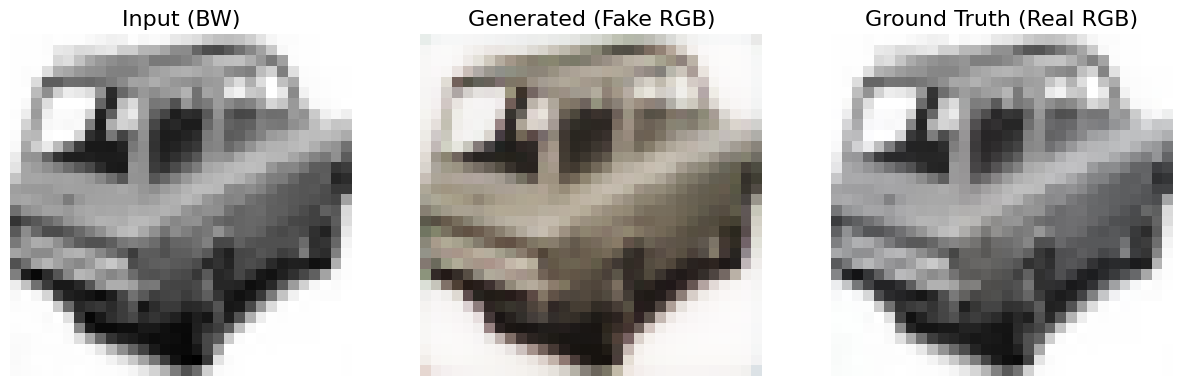

[Epoch 0/20] [Batch 300/391] [G loss: 0.1290] 
[Epoch 0/20] [Batch 310/391] [G loss: 0.1281] 
[Epoch 0/20] [Batch 320/391] [G loss: 0.1273] 
[Epoch 0/20] [Batch 330/391] [G loss: 0.1264] 
[Epoch 0/20] [Batch 340/391] [G loss: 0.1256] 


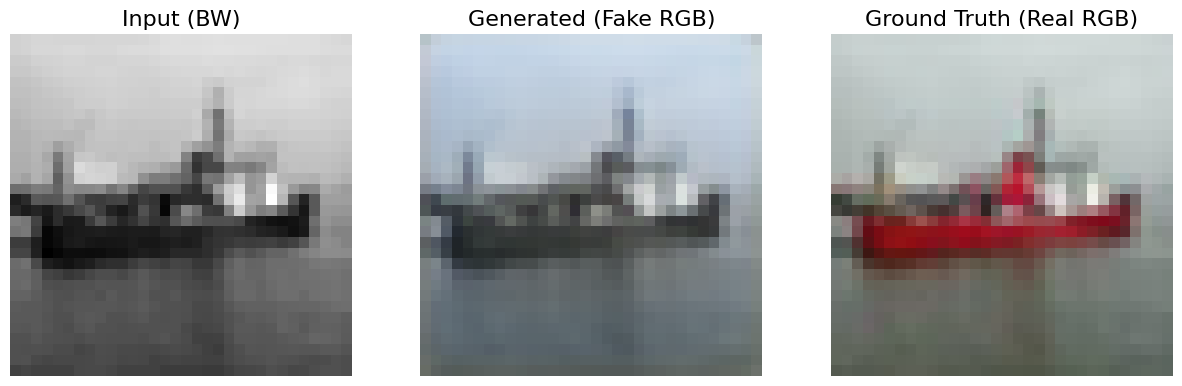

[Epoch 0/20] [Batch 350/391] [G loss: 0.1249] 
[Epoch 0/20] [Batch 360/391] [G loss: 0.1242] 
[Epoch 0/20] [Batch 370/391] [G loss: 0.1235] 
[Epoch 0/20] [Batch 380/391] [G loss: 0.1229] 
[Epoch 0/20] [Batch 390/391] [G loss: 0.1223] 


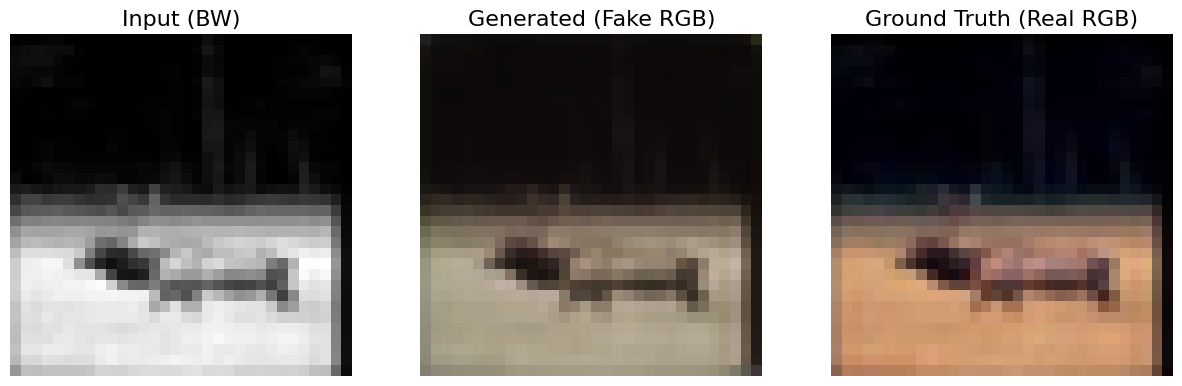

[Epoch 1/20] [Batch 0/391] [G loss: 0.0978] 
[Epoch 1/20] [Batch 10/391] [G loss: 0.0967] 
[Epoch 1/20] [Batch 20/391] [G loss: 0.0971] 
[Epoch 1/20] [Batch 30/391] [G loss: 0.0971] 
[Epoch 1/20] [Batch 40/391] [G loss: 0.0968] 


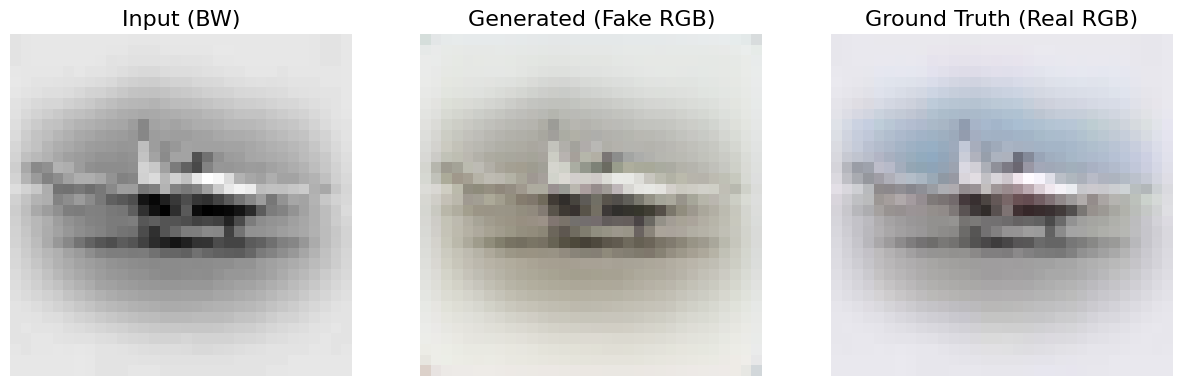

[Epoch 1/20] [Batch 50/391] [G loss: 0.0970] 
[Epoch 1/20] [Batch 60/391] [G loss: 0.0970] 
[Epoch 1/20] [Batch 70/391] [G loss: 0.0971] 
[Epoch 1/20] [Batch 80/391] [G loss: 0.0971] 
[Epoch 1/20] [Batch 90/391] [G loss: 0.0970] 


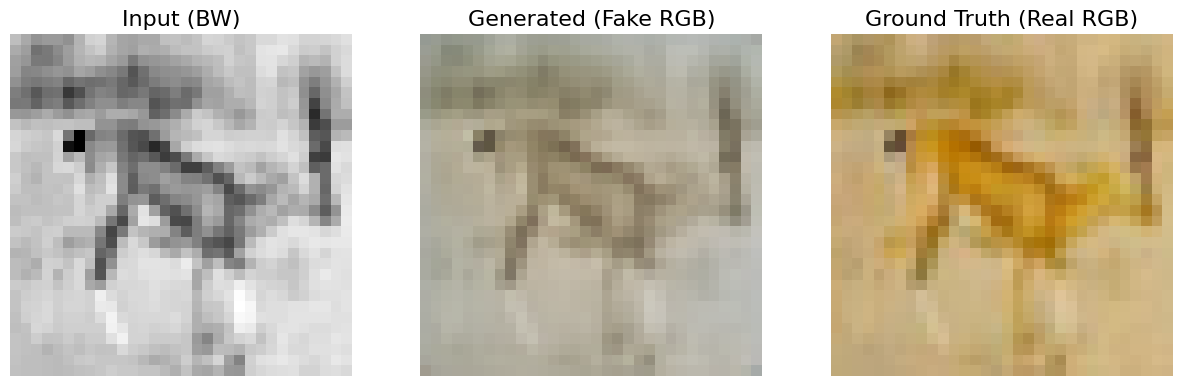

[Epoch 1/20] [Batch 100/391] [G loss: 0.0971] 
[Epoch 1/20] [Batch 110/391] [G loss: 0.0972] 
[Epoch 1/20] [Batch 120/391] [G loss: 0.0972] 
[Epoch 1/20] [Batch 130/391] [G loss: 0.0972] 
[Epoch 1/20] [Batch 140/391] [G loss: 0.0971] 


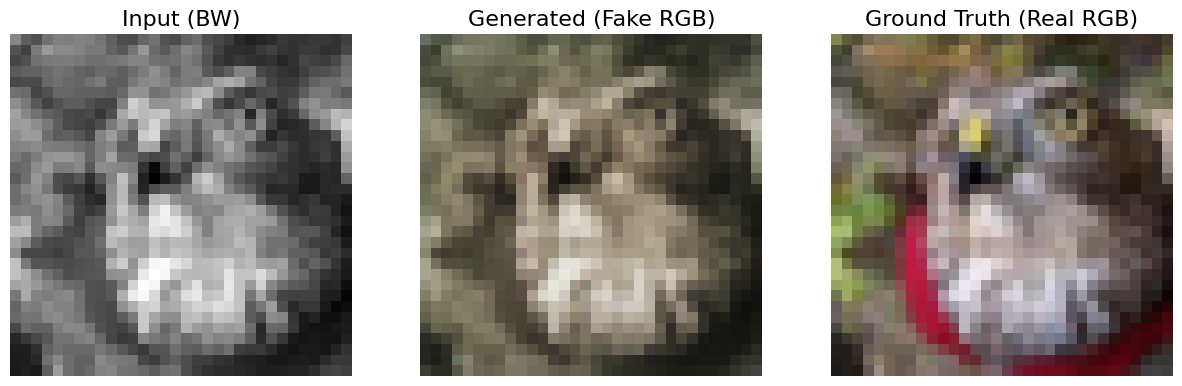

[Epoch 1/20] [Batch 150/391] [G loss: 0.0970] 
[Epoch 1/20] [Batch 160/391] [G loss: 0.0969] 
[Epoch 1/20] [Batch 170/391] [G loss: 0.0968] 
[Epoch 1/20] [Batch 180/391] [G loss: 0.0968] 
[Epoch 1/20] [Batch 190/391] [G loss: 0.0968] 


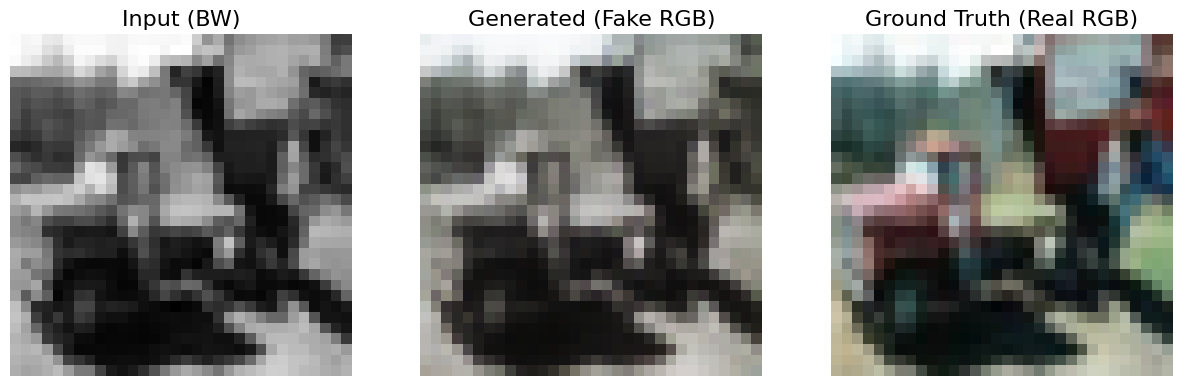

[Epoch 1/20] [Batch 200/391] [G loss: 0.0968] 
[Epoch 1/20] [Batch 210/391] [G loss: 0.0965] 
[Epoch 1/20] [Batch 220/391] [G loss: 0.0965] 
[Epoch 1/20] [Batch 230/391] [G loss: 0.0964] 
[Epoch 1/20] [Batch 240/391] [G loss: 0.0963] 


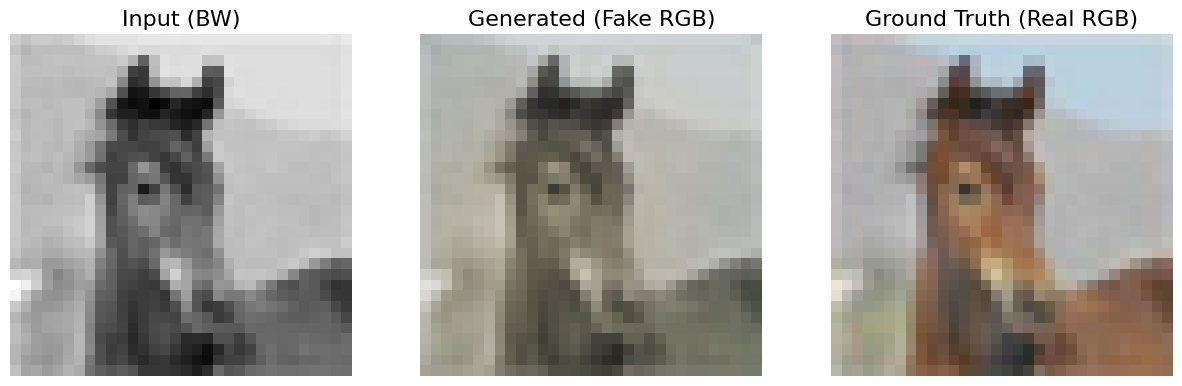

[Epoch 1/20] [Batch 250/391] [G loss: 0.0963] 
[Epoch 1/20] [Batch 260/391] [G loss: 0.0963] 
[Epoch 1/20] [Batch 270/391] [G loss: 0.0961] 
[Epoch 1/20] [Batch 280/391] [G loss: 0.0960] 
[Epoch 1/20] [Batch 290/391] [G loss: 0.0960] 


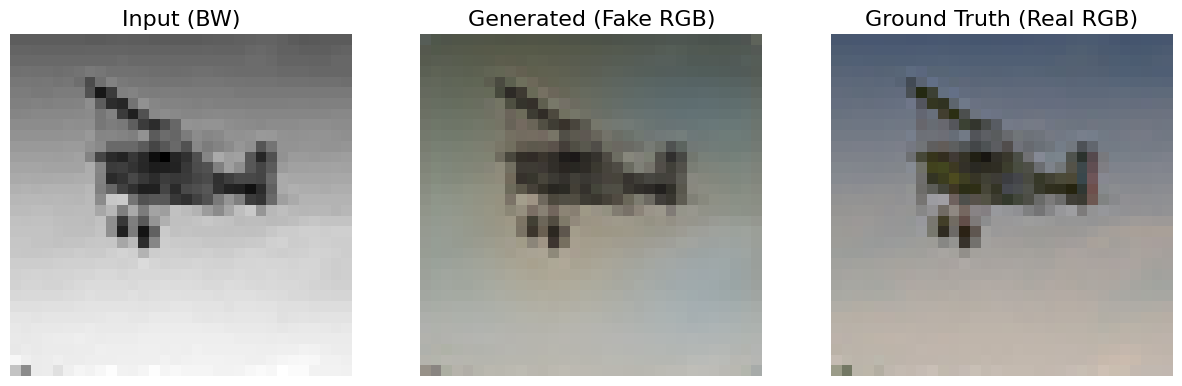

[Epoch 1/20] [Batch 300/391] [G loss: 0.0959] 
[Epoch 1/20] [Batch 310/391] [G loss: 0.0958] 
[Epoch 1/20] [Batch 320/391] [G loss: 0.0958] 
[Epoch 1/20] [Batch 330/391] [G loss: 0.0958] 
[Epoch 1/20] [Batch 340/391] [G loss: 0.0957] 


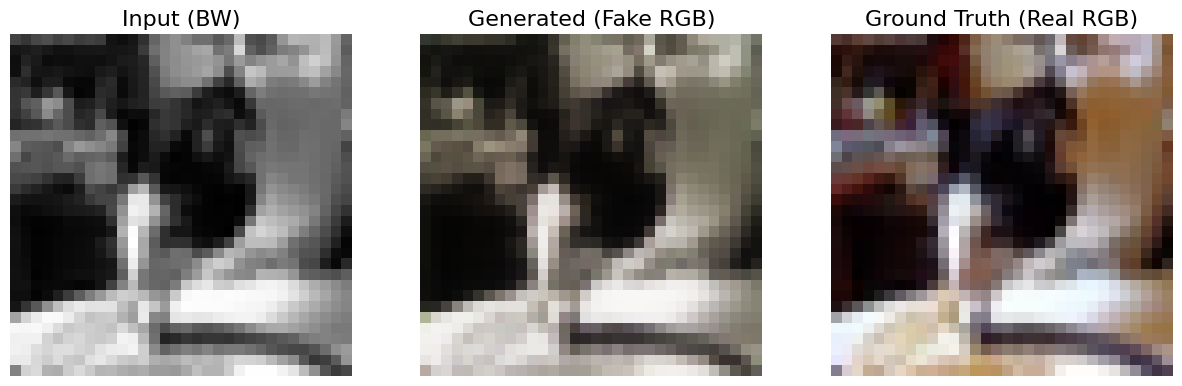

[Epoch 1/20] [Batch 350/391] [G loss: 0.0957] 
[Epoch 1/20] [Batch 360/391] [G loss: 0.0957] 
[Epoch 1/20] [Batch 370/391] [G loss: 0.0957] 
[Epoch 1/20] [Batch 380/391] [G loss: 0.0957] 
[Epoch 1/20] [Batch 390/391] [G loss: 0.0956] 


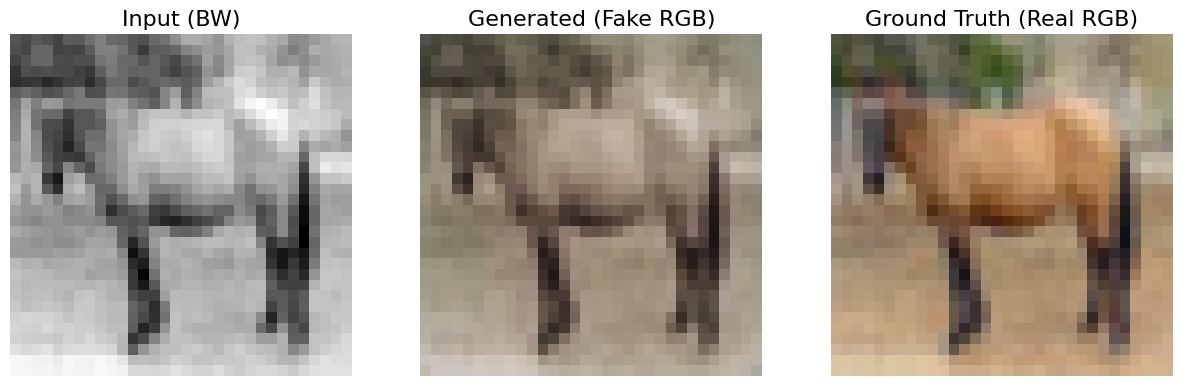

[Epoch 2/20] [Batch 0/391] [G loss: 0.0935] 
[Epoch 2/20] [Batch 10/391] [G loss: 0.0942] 
[Epoch 2/20] [Batch 20/391] [G loss: 0.0943] 
[Epoch 2/20] [Batch 30/391] [G loss: 0.0936] 
[Epoch 2/20] [Batch 40/391] [G loss: 0.0933] 


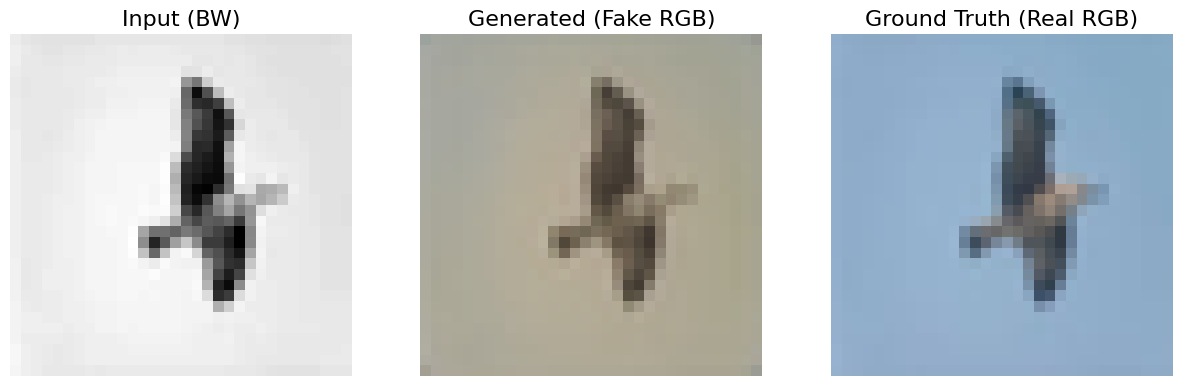

[Epoch 2/20] [Batch 50/391] [G loss: 0.0933] 
[Epoch 2/20] [Batch 60/391] [G loss: 0.0933] 
[Epoch 2/20] [Batch 70/391] [G loss: 0.0935] 
[Epoch 2/20] [Batch 80/391] [G loss: 0.0934] 
[Epoch 2/20] [Batch 90/391] [G loss: 0.0935] 


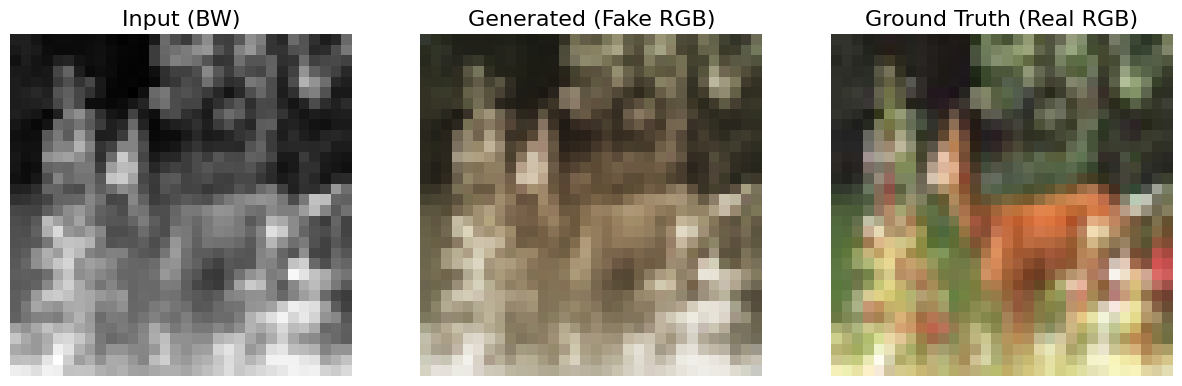

[Epoch 2/20] [Batch 100/391] [G loss: 0.0935] 
[Epoch 2/20] [Batch 110/391] [G loss: 0.0934] 
[Epoch 2/20] [Batch 120/391] [G loss: 0.0934] 
[Epoch 2/20] [Batch 130/391] [G loss: 0.0933] 
[Epoch 2/20] [Batch 140/391] [G loss: 0.0933] 


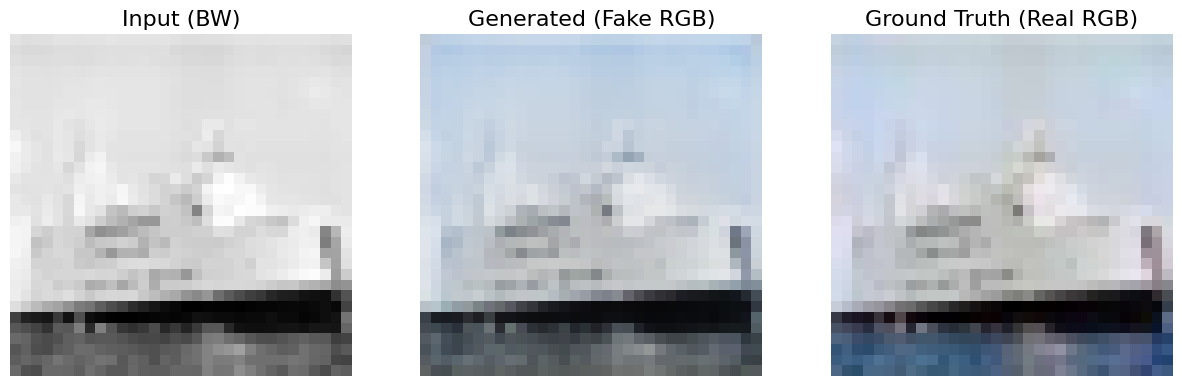

[Epoch 2/20] [Batch 150/391] [G loss: 0.0932] 
[Epoch 2/20] [Batch 160/391] [G loss: 0.0931] 
[Epoch 2/20] [Batch 170/391] [G loss: 0.0930] 
[Epoch 2/20] [Batch 180/391] [G loss: 0.0930] 
[Epoch 2/20] [Batch 190/391] [G loss: 0.0930] 


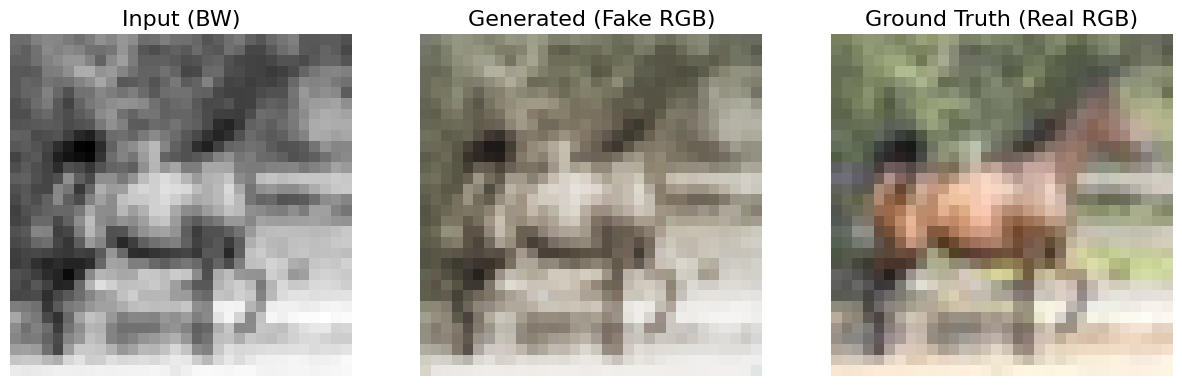

[Epoch 2/20] [Batch 200/391] [G loss: 0.0929] 
[Epoch 2/20] [Batch 210/391] [G loss: 0.0930] 
[Epoch 2/20] [Batch 220/391] [G loss: 0.0928] 
[Epoch 2/20] [Batch 230/391] [G loss: 0.0929] 
[Epoch 2/20] [Batch 240/391] [G loss: 0.0929] 


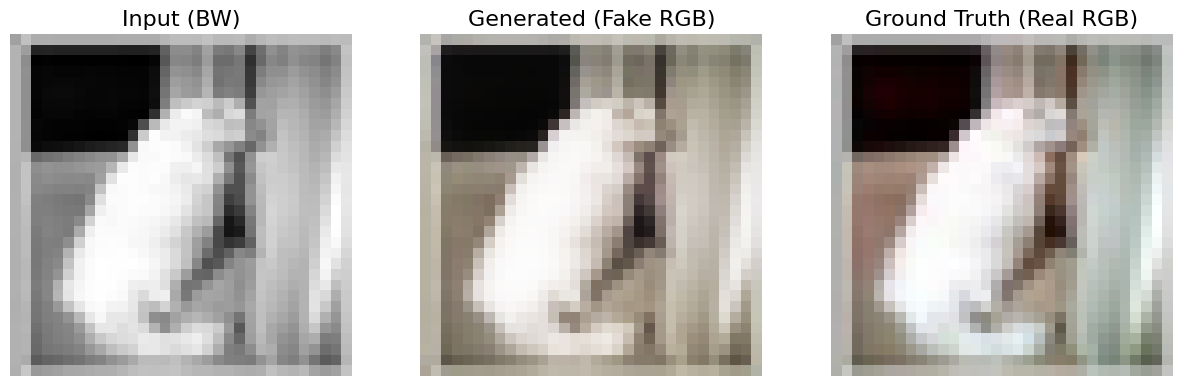

[Epoch 2/20] [Batch 250/391] [G loss: 0.0928] 
[Epoch 2/20] [Batch 260/391] [G loss: 0.0928] 
[Epoch 2/20] [Batch 270/391] [G loss: 0.0929] 
[Epoch 2/20] [Batch 280/391] [G loss: 0.0929] 
[Epoch 2/20] [Batch 290/391] [G loss: 0.0929] 


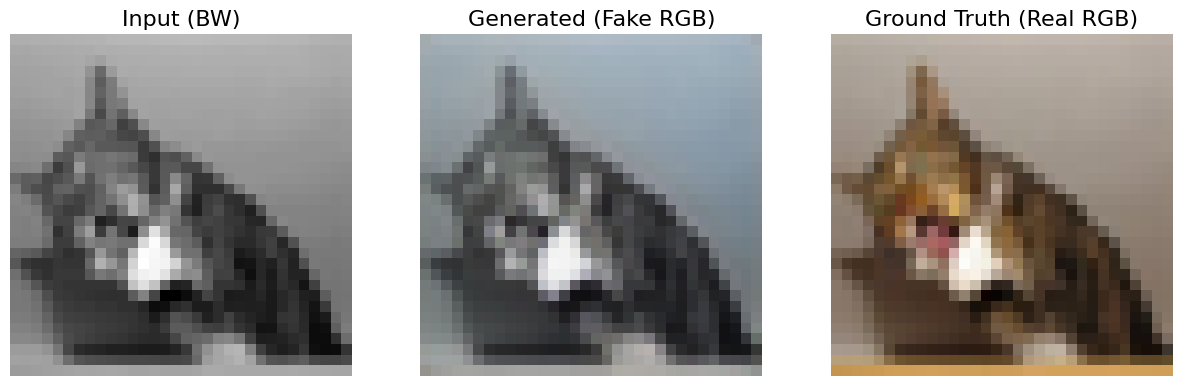

[Epoch 2/20] [Batch 300/391] [G loss: 0.0928] 
[Epoch 2/20] [Batch 310/391] [G loss: 0.0927] 
[Epoch 2/20] [Batch 320/391] [G loss: 0.0927] 
[Epoch 2/20] [Batch 330/391] [G loss: 0.0926] 
[Epoch 2/20] [Batch 340/391] [G loss: 0.0926] 


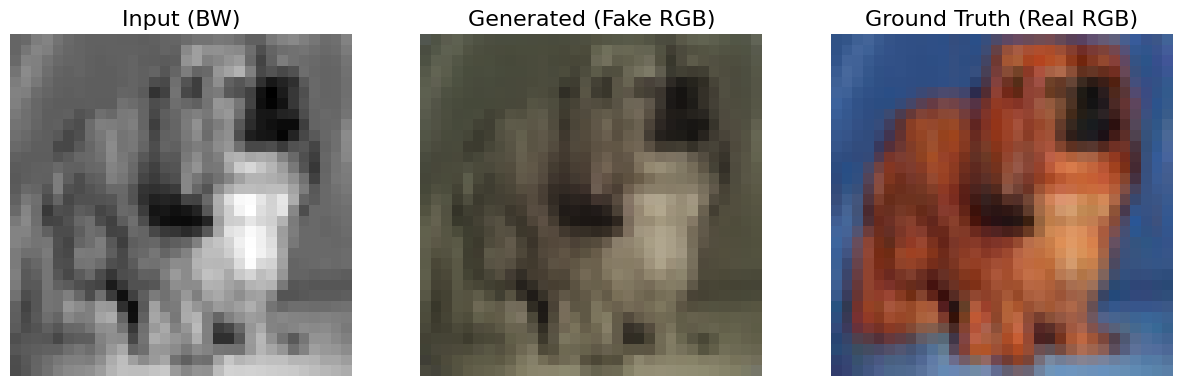

[Epoch 2/20] [Batch 350/391] [G loss: 0.0926] 
[Epoch 2/20] [Batch 360/391] [G loss: 0.0927] 
[Epoch 2/20] [Batch 370/391] [G loss: 0.0927] 
[Epoch 2/20] [Batch 380/391] [G loss: 0.0927] 
[Epoch 2/20] [Batch 390/391] [G loss: 0.0927] 


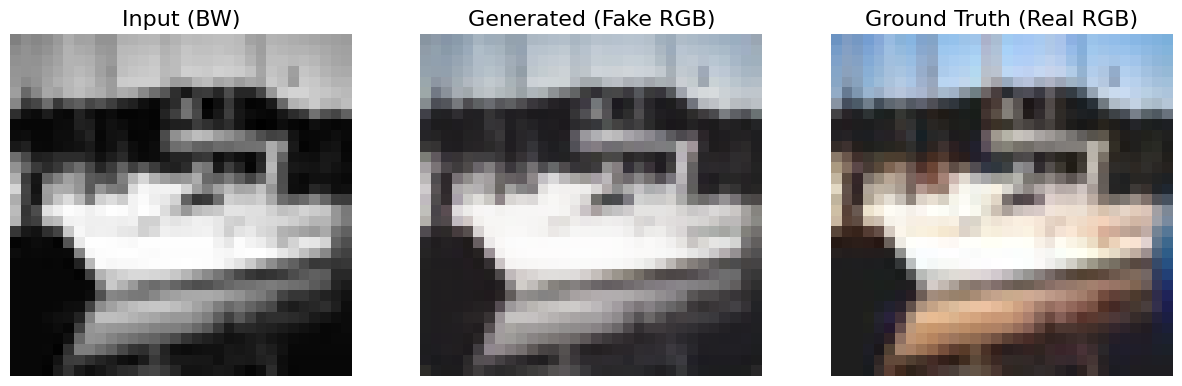

[Epoch 3/20] [Batch 0/391] [G loss: 0.0935] 
[Epoch 3/20] [Batch 10/391] [G loss: 0.0908] 
[Epoch 3/20] [Batch 20/391] [G loss: 0.0906] 
[Epoch 3/20] [Batch 30/391] [G loss: 0.0909] 
[Epoch 3/20] [Batch 40/391] [G loss: 0.0908] 


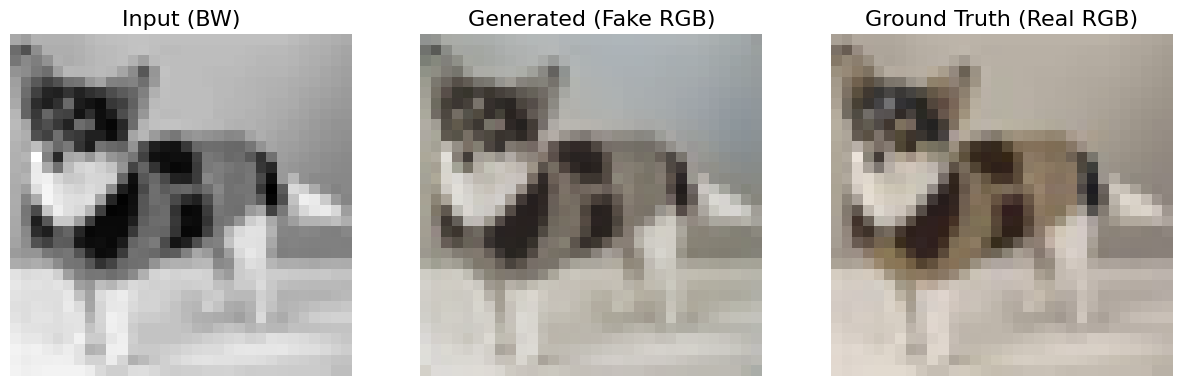

[Epoch 3/20] [Batch 50/391] [G loss: 0.0910] 
[Epoch 3/20] [Batch 60/391] [G loss: 0.0913] 
[Epoch 3/20] [Batch 70/391] [G loss: 0.0915] 
[Epoch 3/20] [Batch 80/391] [G loss: 0.0916] 
[Epoch 3/20] [Batch 90/391] [G loss: 0.0917] 


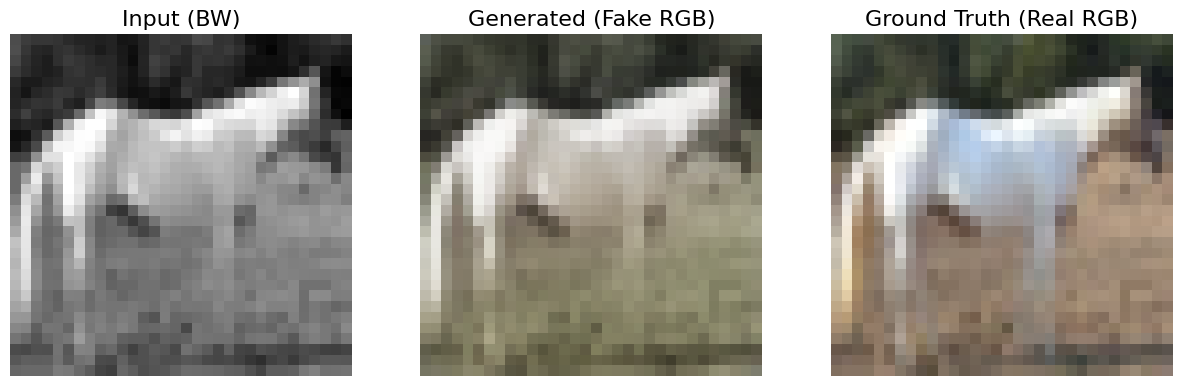

[Epoch 3/20] [Batch 100/391] [G loss: 0.0917] 
[Epoch 3/20] [Batch 110/391] [G loss: 0.0919] 
[Epoch 3/20] [Batch 120/391] [G loss: 0.0918] 
[Epoch 3/20] [Batch 130/391] [G loss: 0.0918] 
[Epoch 3/20] [Batch 140/391] [G loss: 0.0919] 


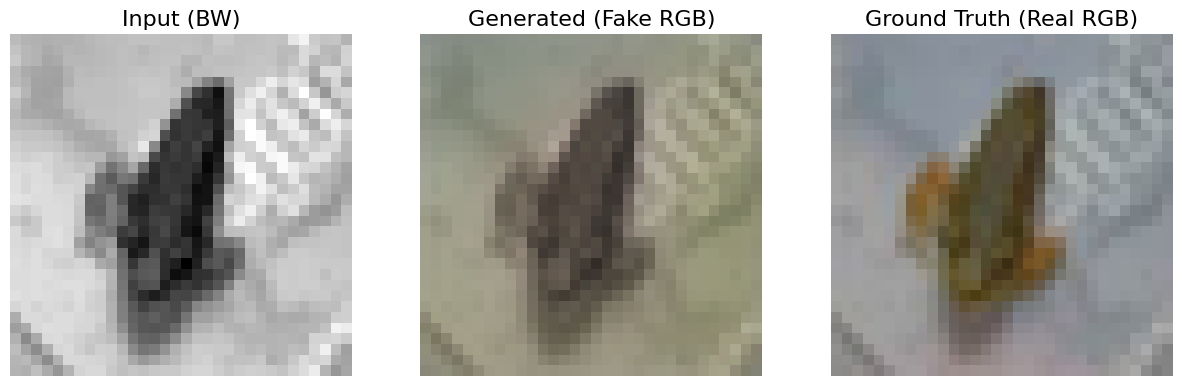

[Epoch 3/20] [Batch 150/391] [G loss: 0.0921] 
[Epoch 3/20] [Batch 160/391] [G loss: 0.0920] 
[Epoch 3/20] [Batch 170/391] [G loss: 0.0920] 
[Epoch 3/20] [Batch 180/391] [G loss: 0.0919] 
[Epoch 3/20] [Batch 190/391] [G loss: 0.0918] 


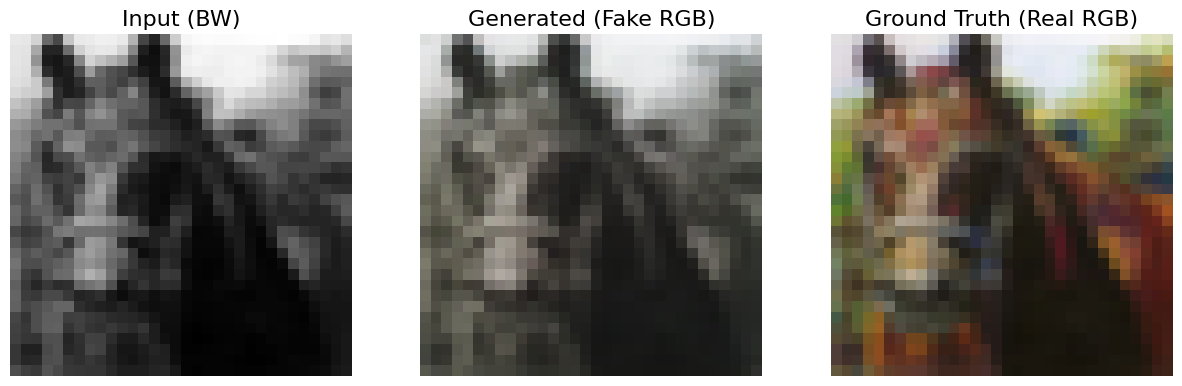

[Epoch 3/20] [Batch 200/391] [G loss: 0.0917] 
[Epoch 3/20] [Batch 210/391] [G loss: 0.0916] 
[Epoch 3/20] [Batch 220/391] [G loss: 0.0915] 
[Epoch 3/20] [Batch 230/391] [G loss: 0.0916] 
[Epoch 3/20] [Batch 240/391] [G loss: 0.0916] 


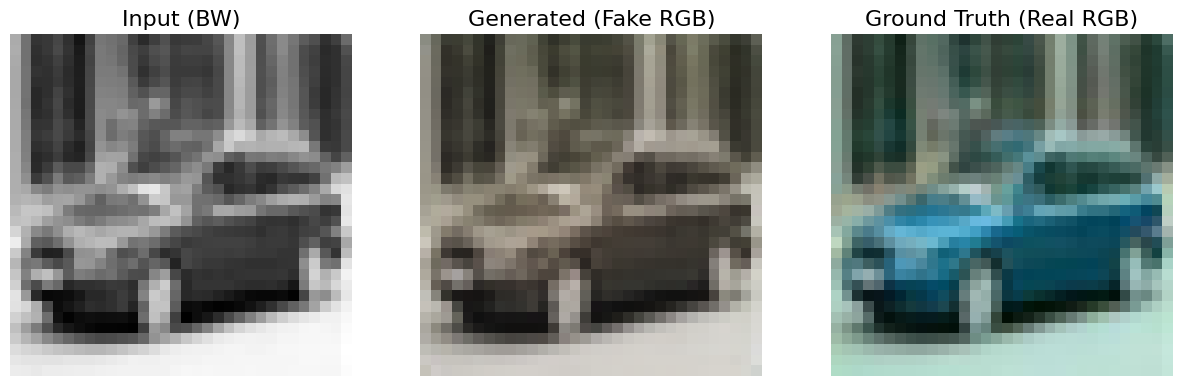

[Epoch 3/20] [Batch 250/391] [G loss: 0.0915] 
[Epoch 3/20] [Batch 260/391] [G loss: 0.0914] 
[Epoch 3/20] [Batch 270/391] [G loss: 0.0914] 
[Epoch 3/20] [Batch 280/391] [G loss: 0.0913] 
[Epoch 3/20] [Batch 290/391] [G loss: 0.0913] 


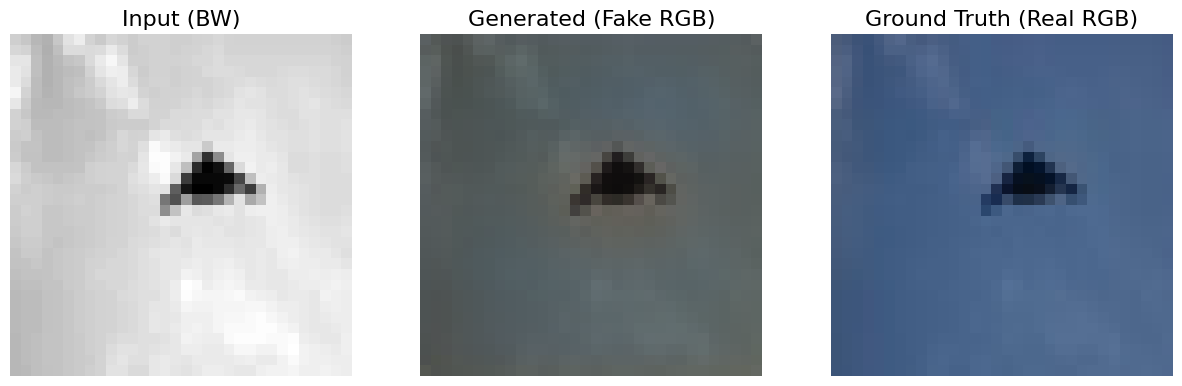

[Epoch 3/20] [Batch 300/391] [G loss: 0.0912] 
[Epoch 3/20] [Batch 310/391] [G loss: 0.0911] 
[Epoch 3/20] [Batch 320/391] [G loss: 0.0911] 
[Epoch 3/20] [Batch 330/391] [G loss: 0.0911] 
[Epoch 3/20] [Batch 340/391] [G loss: 0.0911] 


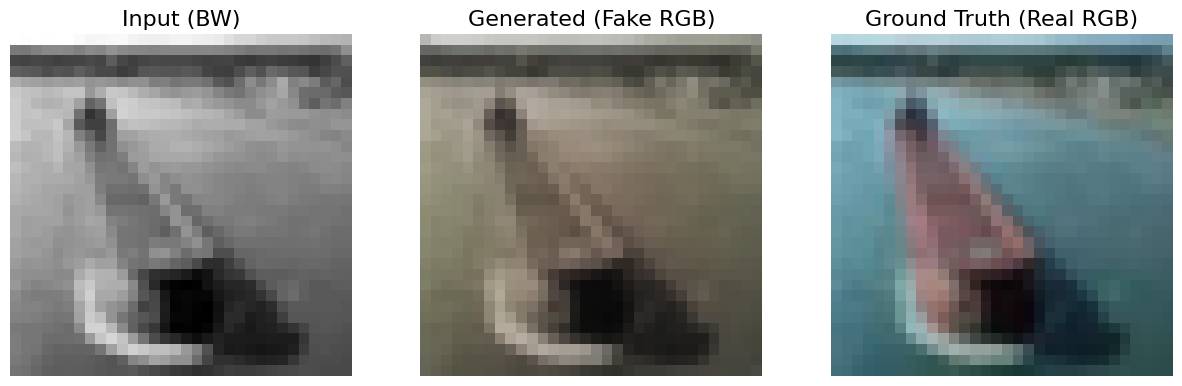

[Epoch 3/20] [Batch 350/391] [G loss: 0.0911] 
[Epoch 3/20] [Batch 360/391] [G loss: 0.0911] 
[Epoch 3/20] [Batch 370/391] [G loss: 0.0910] 
[Epoch 3/20] [Batch 380/391] [G loss: 0.0911] 
[Epoch 3/20] [Batch 390/391] [G loss: 0.0911] 


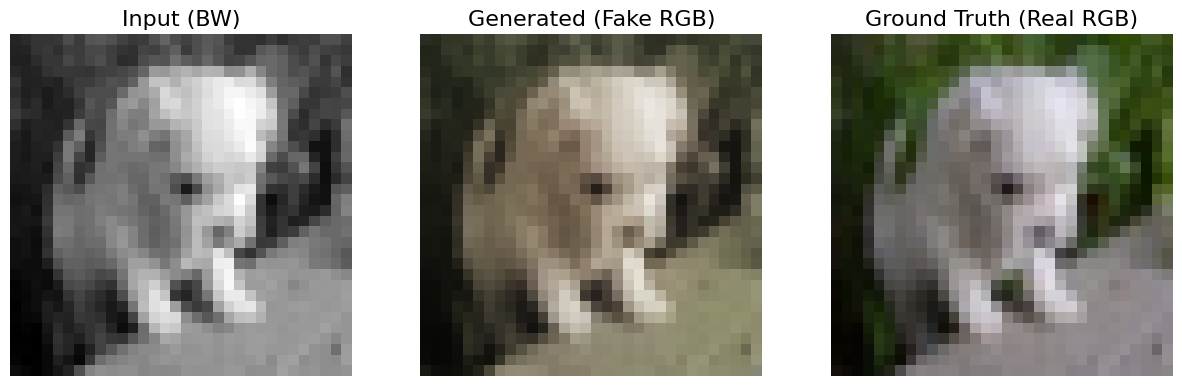

[Epoch 4/20] [Batch 0/391] [G loss: 0.0931] 
[Epoch 4/20] [Batch 10/391] [G loss: 0.0898] 
[Epoch 4/20] [Batch 20/391] [G loss: 0.0914] 
[Epoch 4/20] [Batch 30/391] [G loss: 0.0913] 
[Epoch 4/20] [Batch 40/391] [G loss: 0.0909] 


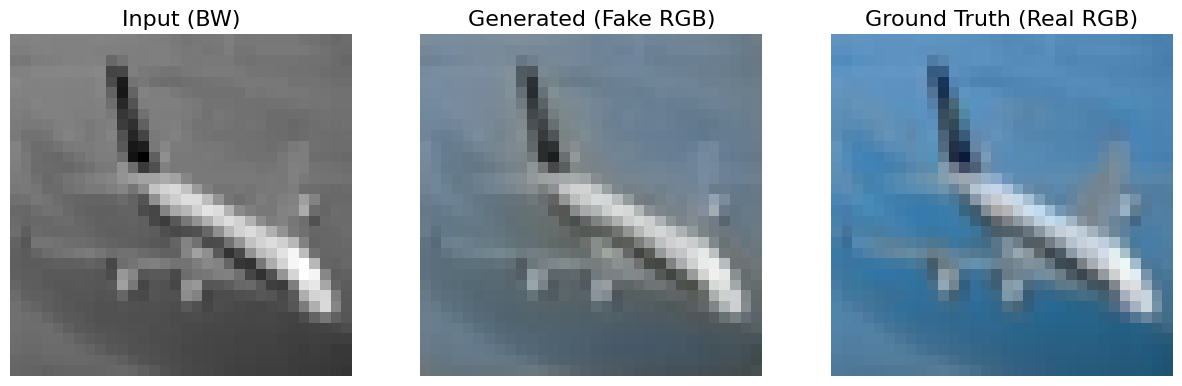

[Epoch 4/20] [Batch 50/391] [G loss: 0.0910] 
[Epoch 4/20] [Batch 60/391] [G loss: 0.0911] 
[Epoch 4/20] [Batch 70/391] [G loss: 0.0909] 
[Epoch 4/20] [Batch 80/391] [G loss: 0.0909] 
[Epoch 4/20] [Batch 90/391] [G loss: 0.0906] 


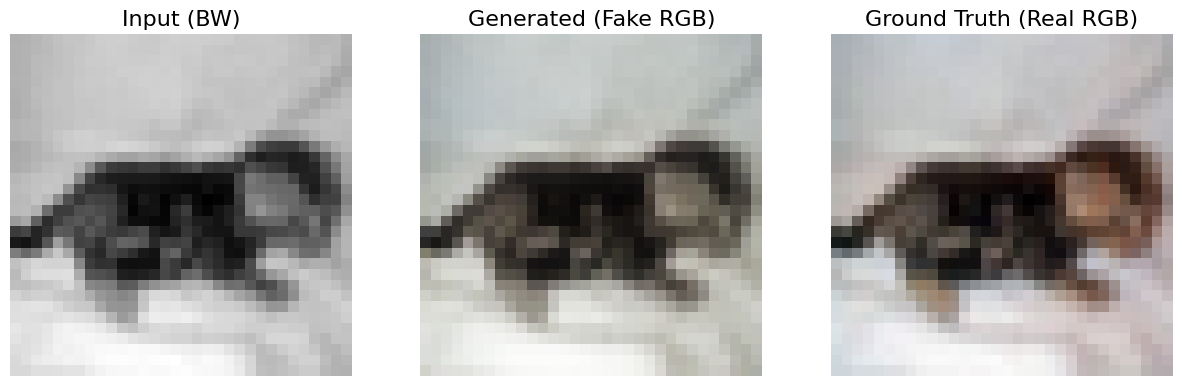

[Epoch 4/20] [Batch 100/391] [G loss: 0.0905] 
[Epoch 4/20] [Batch 110/391] [G loss: 0.0906] 
[Epoch 4/20] [Batch 120/391] [G loss: 0.0904] 
[Epoch 4/20] [Batch 130/391] [G loss: 0.0904] 
[Epoch 4/20] [Batch 140/391] [G loss: 0.0904] 


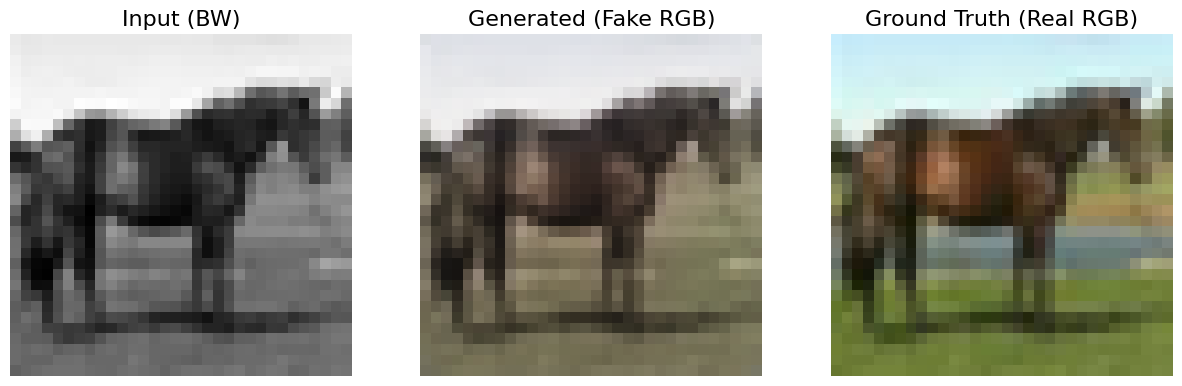

[Epoch 4/20] [Batch 150/391] [G loss: 0.0902] 
[Epoch 4/20] [Batch 160/391] [G loss: 0.0901] 
[Epoch 4/20] [Batch 170/391] [G loss: 0.0902] 
[Epoch 4/20] [Batch 180/391] [G loss: 0.0901] 
[Epoch 4/20] [Batch 190/391] [G loss: 0.0901] 


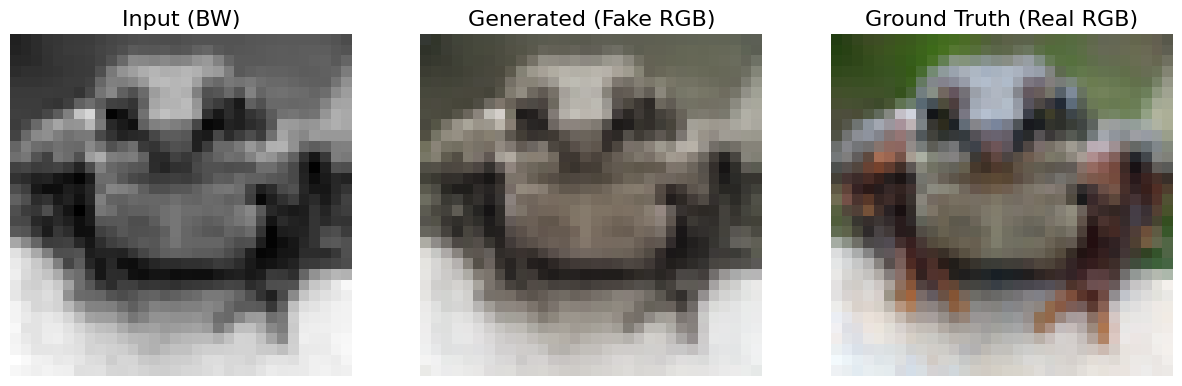

[Epoch 4/20] [Batch 200/391] [G loss: 0.0900] 
[Epoch 4/20] [Batch 210/391] [G loss: 0.0901] 
[Epoch 4/20] [Batch 220/391] [G loss: 0.0902] 
[Epoch 4/20] [Batch 230/391] [G loss: 0.0900] 
[Epoch 4/20] [Batch 240/391] [G loss: 0.0901] 


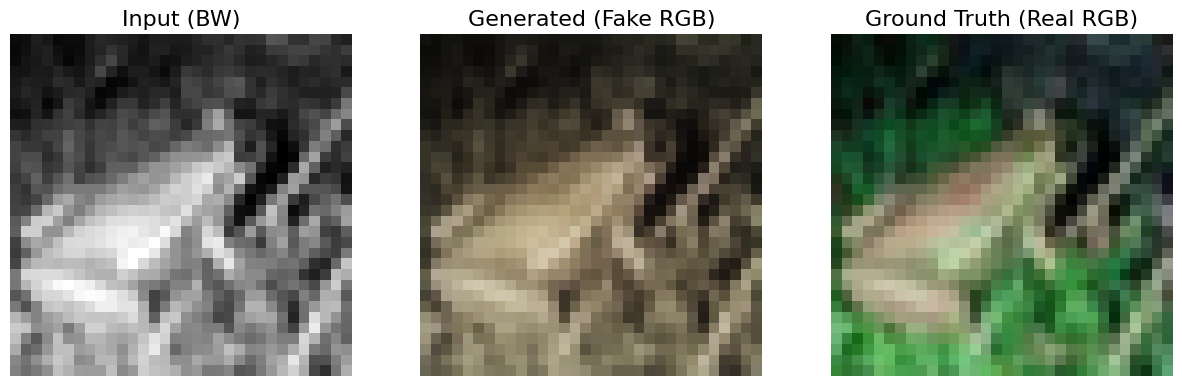

[Epoch 4/20] [Batch 250/391] [G loss: 0.0902] 
[Epoch 4/20] [Batch 260/391] [G loss: 0.0903] 
[Epoch 4/20] [Batch 270/391] [G loss: 0.0903] 
[Epoch 4/20] [Batch 280/391] [G loss: 0.0902] 
[Epoch 4/20] [Batch 290/391] [G loss: 0.0902] 


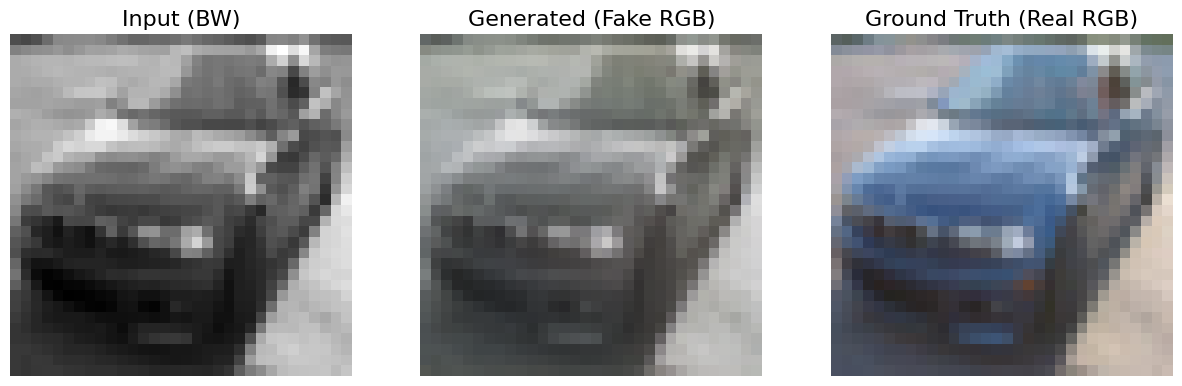

[Epoch 4/20] [Batch 300/391] [G loss: 0.0901] 
[Epoch 4/20] [Batch 310/391] [G loss: 0.0901] 
[Epoch 4/20] [Batch 320/391] [G loss: 0.0900] 
[Epoch 4/20] [Batch 330/391] [G loss: 0.0901] 
[Epoch 4/20] [Batch 340/391] [G loss: 0.0901] 


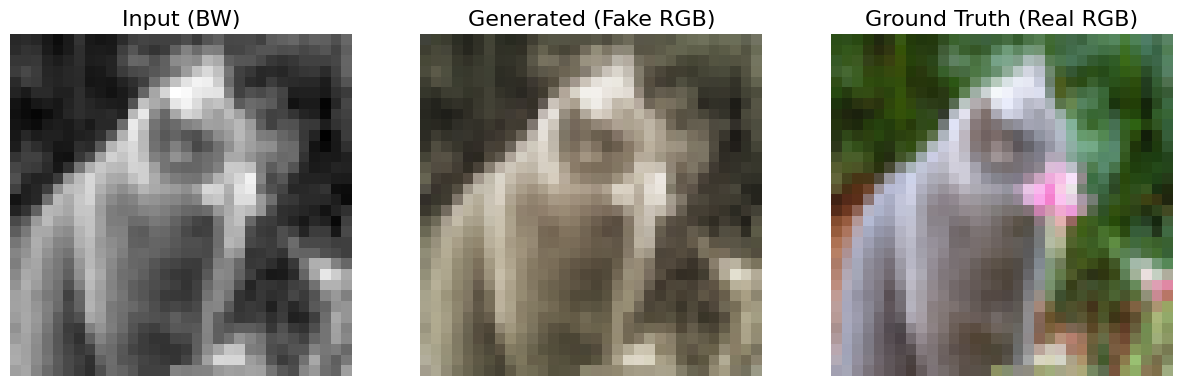

[Epoch 4/20] [Batch 350/391] [G loss: 0.0900] 
[Epoch 4/20] [Batch 360/391] [G loss: 0.0900] 
[Epoch 4/20] [Batch 370/391] [G loss: 0.0899] 
[Epoch 4/20] [Batch 380/391] [G loss: 0.0899] 
[Epoch 4/20] [Batch 390/391] [G loss: 0.0899] 


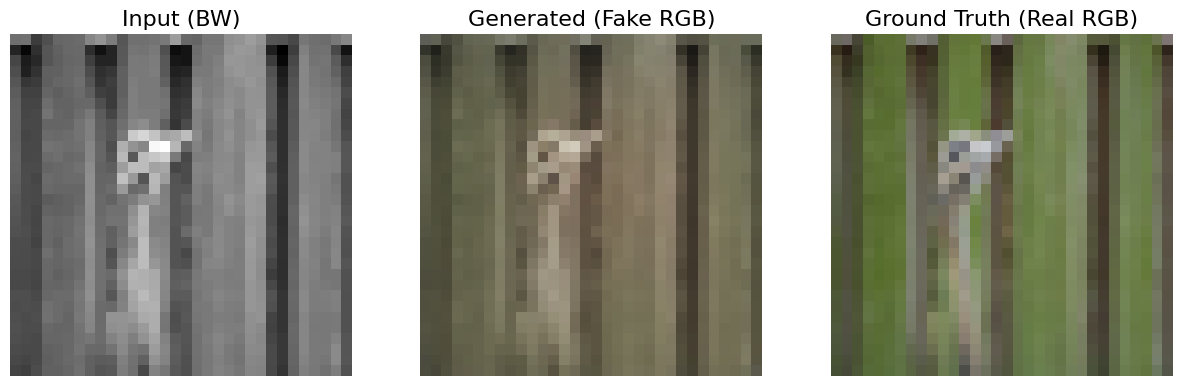

[Epoch 5/20] [Batch 0/391] [G loss: 0.0933] 
[Epoch 5/20] [Batch 10/391] [G loss: 0.0912] 
[Epoch 5/20] [Batch 20/391] [G loss: 0.0908] 
[Epoch 5/20] [Batch 30/391] [G loss: 0.0900] 
[Epoch 5/20] [Batch 40/391] [G loss: 0.0897] 


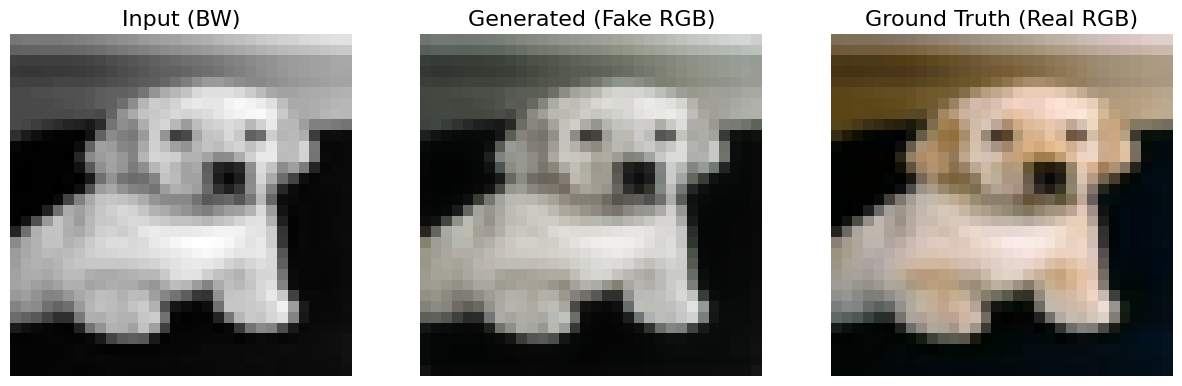

[Epoch 5/20] [Batch 50/391] [G loss: 0.0894] 
[Epoch 5/20] [Batch 60/391] [G loss: 0.0893] 
[Epoch 5/20] [Batch 70/391] [G loss: 0.0892] 
[Epoch 5/20] [Batch 80/391] [G loss: 0.0892] 
[Epoch 5/20] [Batch 90/391] [G loss: 0.0893] 


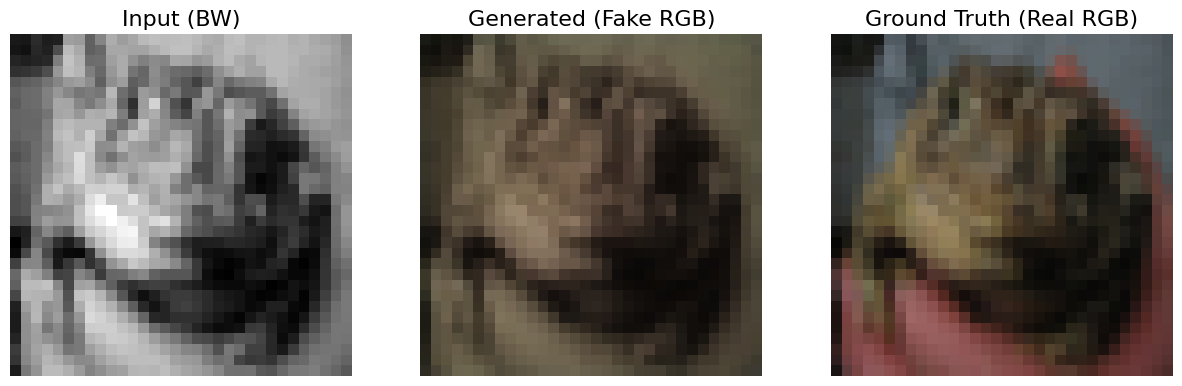

[Epoch 5/20] [Batch 100/391] [G loss: 0.0897] 
[Epoch 5/20] [Batch 110/391] [G loss: 0.0896] 
[Epoch 5/20] [Batch 120/391] [G loss: 0.0895] 
[Epoch 5/20] [Batch 130/391] [G loss: 0.0893] 
[Epoch 5/20] [Batch 140/391] [G loss: 0.0892] 


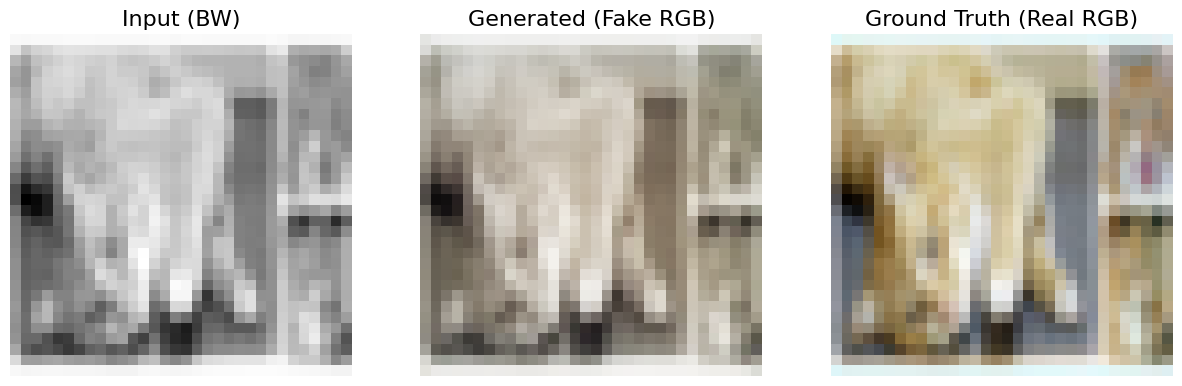

[Epoch 5/20] [Batch 150/391] [G loss: 0.0891] 
[Epoch 5/20] [Batch 160/391] [G loss: 0.0892] 
[Epoch 5/20] [Batch 170/391] [G loss: 0.0892] 
[Epoch 5/20] [Batch 180/391] [G loss: 0.0892] 
[Epoch 5/20] [Batch 190/391] [G loss: 0.0891] 


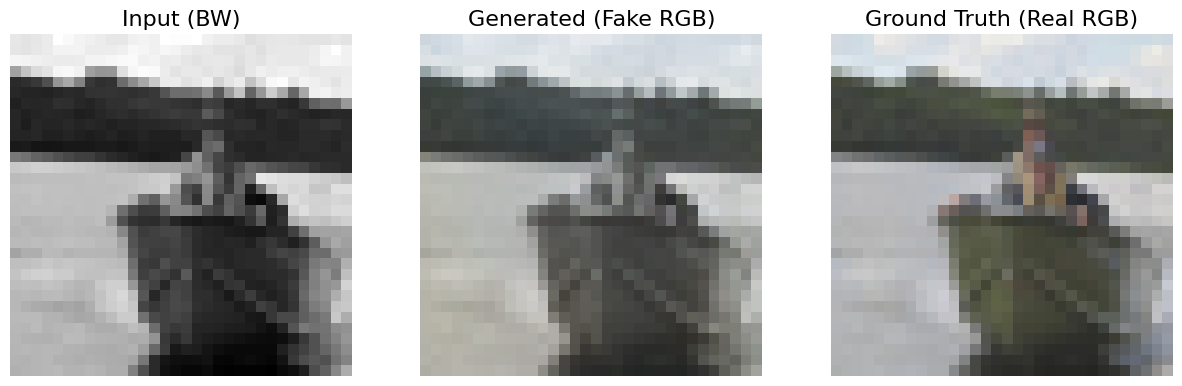

[Epoch 5/20] [Batch 200/391] [G loss: 0.0891] 
[Epoch 5/20] [Batch 210/391] [G loss: 0.0891] 
[Epoch 5/20] [Batch 220/391] [G loss: 0.0893] 
[Epoch 5/20] [Batch 230/391] [G loss: 0.0894] 
[Epoch 5/20] [Batch 240/391] [G loss: 0.0894] 


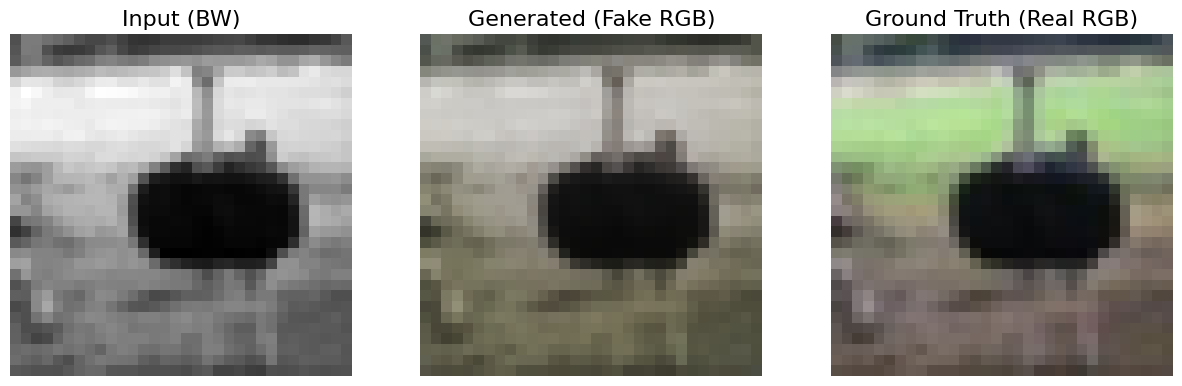

[Epoch 5/20] [Batch 250/391] [G loss: 0.0893] 
[Epoch 5/20] [Batch 260/391] [G loss: 0.0893] 
[Epoch 5/20] [Batch 270/391] [G loss: 0.0892] 
[Epoch 5/20] [Batch 280/391] [G loss: 0.0891] 
[Epoch 5/20] [Batch 290/391] [G loss: 0.0892] 


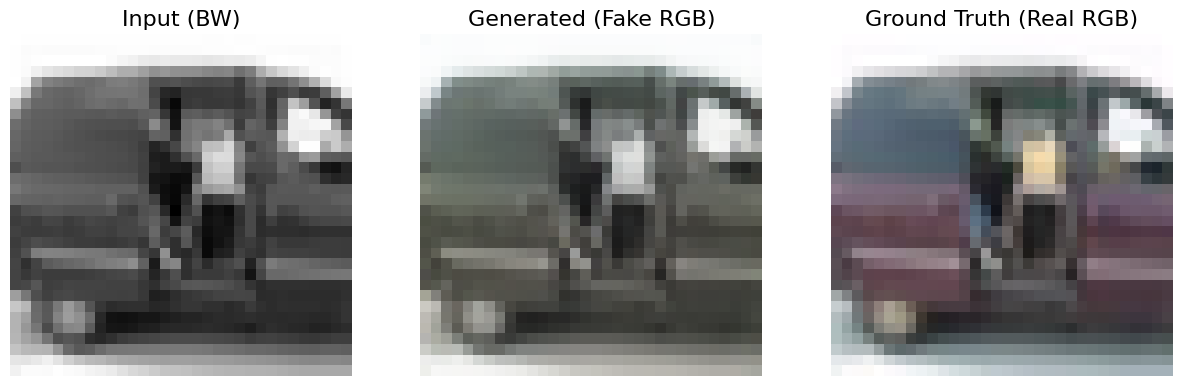

[Epoch 5/20] [Batch 300/391] [G loss: 0.0892] 
[Epoch 5/20] [Batch 310/391] [G loss: 0.0892] 
[Epoch 5/20] [Batch 320/391] [G loss: 0.0891] 
[Epoch 5/20] [Batch 330/391] [G loss: 0.0891] 
[Epoch 5/20] [Batch 340/391] [G loss: 0.0890] 


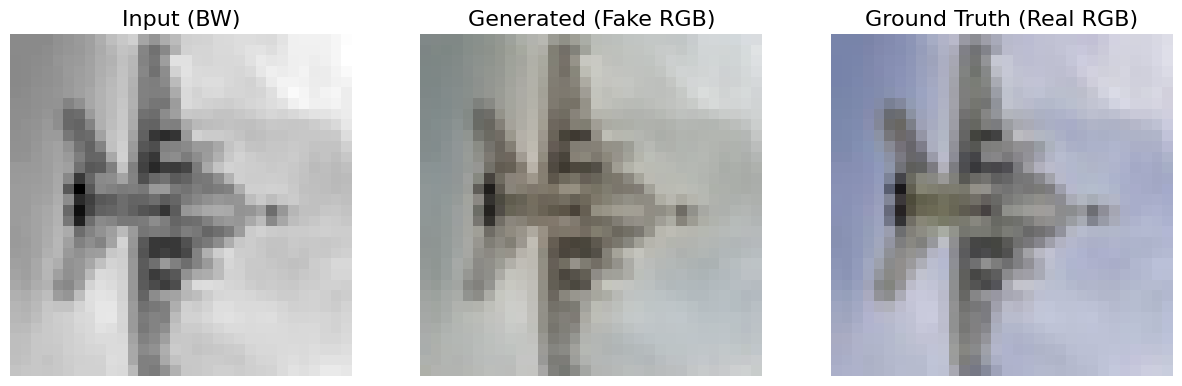

[Epoch 5/20] [Batch 350/391] [G loss: 0.0891] 
[Epoch 5/20] [Batch 360/391] [G loss: 0.0891] 
[Epoch 5/20] [Batch 370/391] [G loss: 0.0891] 
[Epoch 5/20] [Batch 380/391] [G loss: 0.0891] 
[Epoch 5/20] [Batch 390/391] [G loss: 0.0891] 


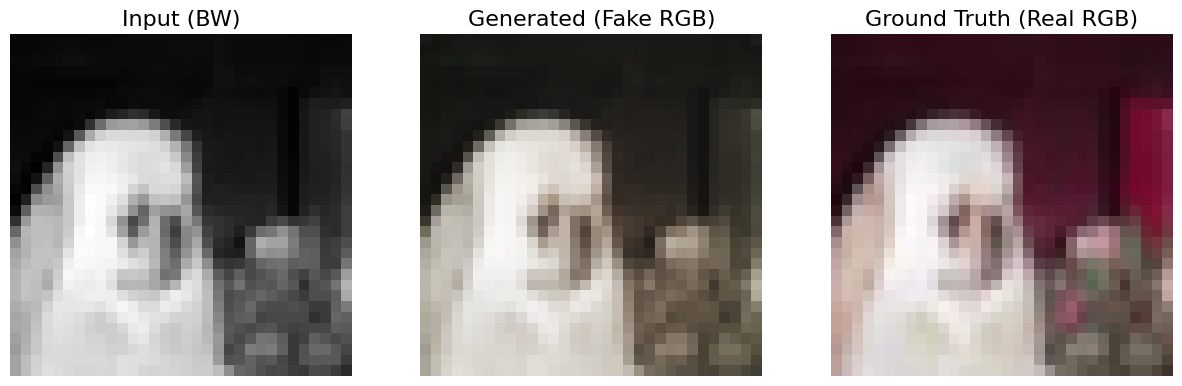

[Epoch 6/20] [Batch 0/391] [G loss: 0.0865] 
[Epoch 6/20] [Batch 10/391] [G loss: 0.0859] 
[Epoch 6/20] [Batch 20/391] [G loss: 0.0870] 
[Epoch 6/20] [Batch 30/391] [G loss: 0.0877] 
[Epoch 6/20] [Batch 40/391] [G loss: 0.0874] 


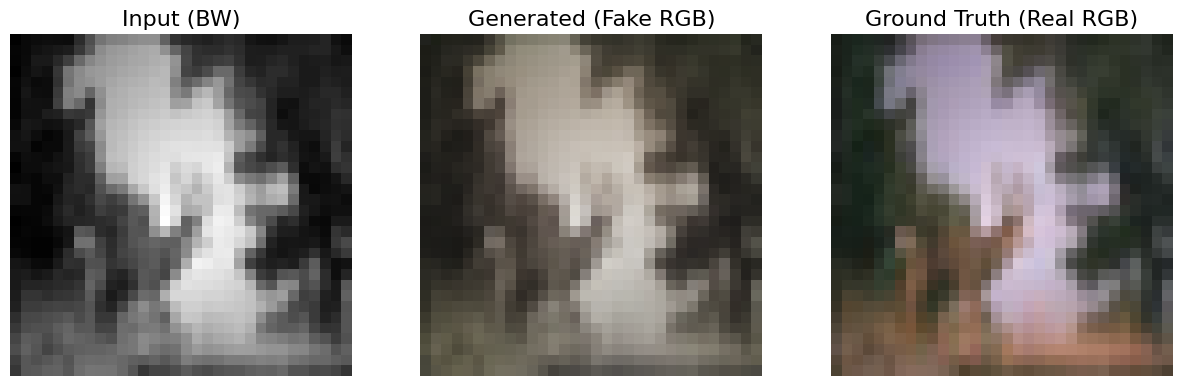

[Epoch 6/20] [Batch 50/391] [G loss: 0.0876] 
[Epoch 6/20] [Batch 60/391] [G loss: 0.0877] 
[Epoch 6/20] [Batch 70/391] [G loss: 0.0878] 
[Epoch 6/20] [Batch 80/391] [G loss: 0.0878] 
[Epoch 6/20] [Batch 90/391] [G loss: 0.0880] 


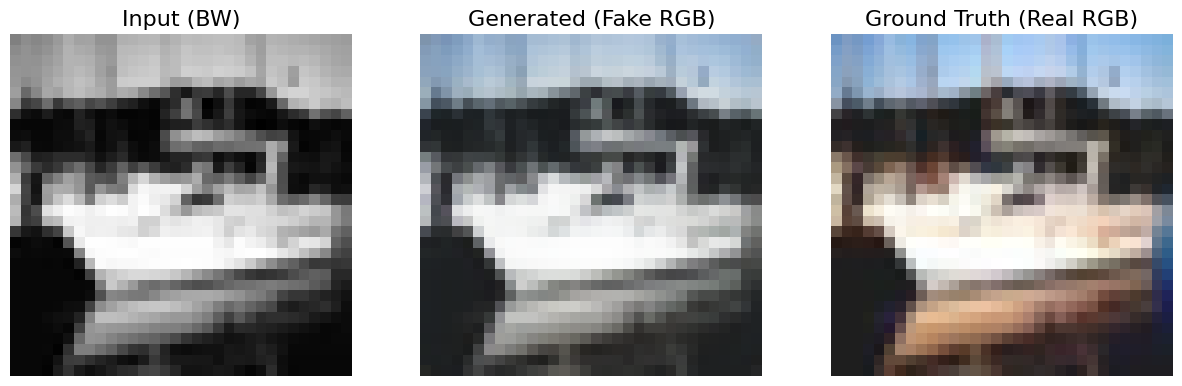

[Epoch 6/20] [Batch 100/391] [G loss: 0.0882] 
[Epoch 6/20] [Batch 110/391] [G loss: 0.0883] 
[Epoch 6/20] [Batch 120/391] [G loss: 0.0883] 
[Epoch 6/20] [Batch 130/391] [G loss: 0.0882] 
[Epoch 6/20] [Batch 140/391] [G loss: 0.0882] 


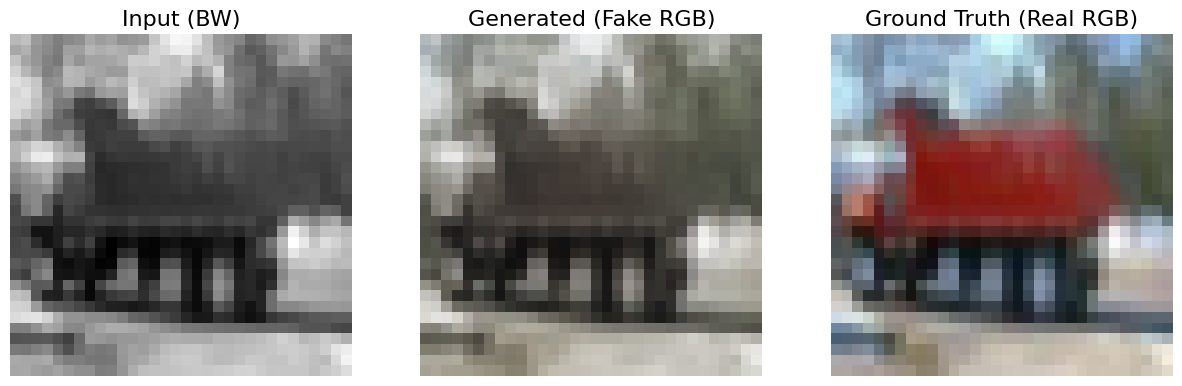

[Epoch 6/20] [Batch 150/391] [G loss: 0.0881] 
[Epoch 6/20] [Batch 160/391] [G loss: 0.0883] 
[Epoch 6/20] [Batch 170/391] [G loss: 0.0884] 
[Epoch 6/20] [Batch 180/391] [G loss: 0.0883] 
[Epoch 6/20] [Batch 190/391] [G loss: 0.0881] 


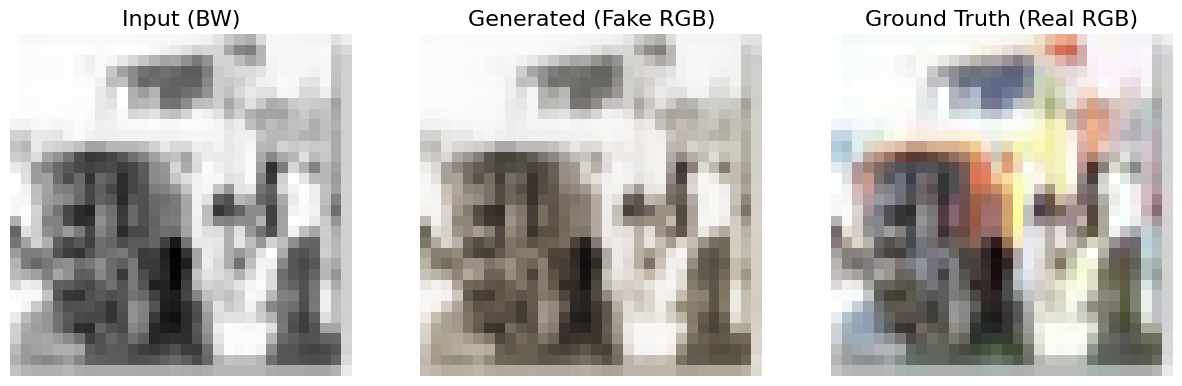

[Epoch 6/20] [Batch 200/391] [G loss: 0.0881] 
[Epoch 6/20] [Batch 210/391] [G loss: 0.0880] 
[Epoch 6/20] [Batch 220/391] [G loss: 0.0881] 
[Epoch 6/20] [Batch 230/391] [G loss: 0.0881] 
[Epoch 6/20] [Batch 240/391] [G loss: 0.0881] 


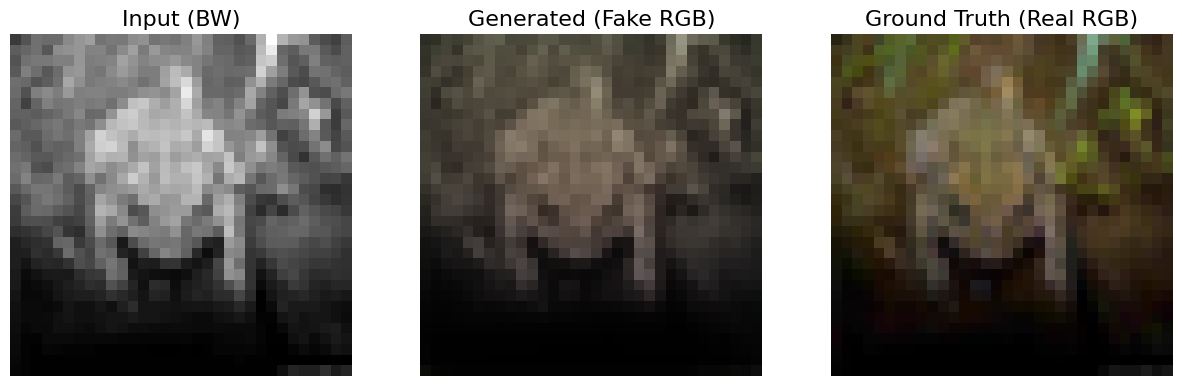

[Epoch 6/20] [Batch 250/391] [G loss: 0.0880] 
[Epoch 6/20] [Batch 260/391] [G loss: 0.0880] 
[Epoch 6/20] [Batch 270/391] [G loss: 0.0880] 
[Epoch 6/20] [Batch 280/391] [G loss: 0.0880] 
[Epoch 6/20] [Batch 290/391] [G loss: 0.0880] 


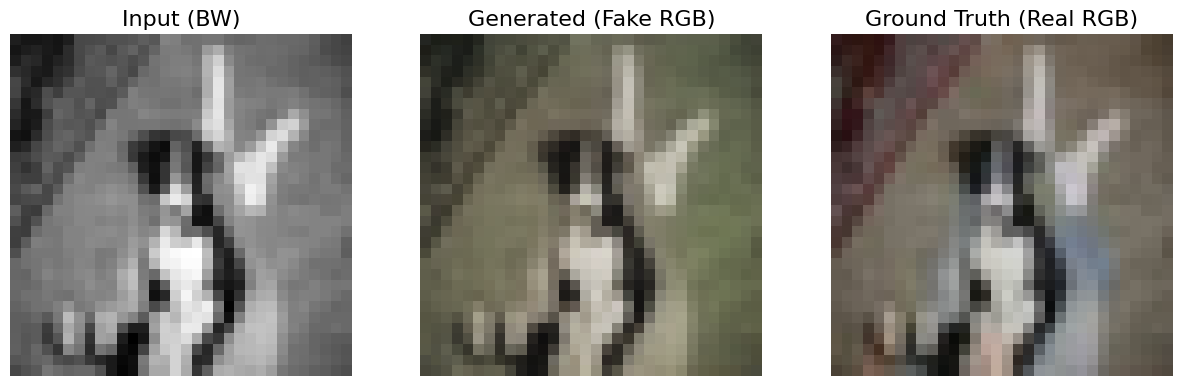

[Epoch 6/20] [Batch 300/391] [G loss: 0.0881] 
[Epoch 6/20] [Batch 310/391] [G loss: 0.0881] 
[Epoch 6/20] [Batch 320/391] [G loss: 0.0881] 
[Epoch 6/20] [Batch 330/391] [G loss: 0.0881] 
[Epoch 6/20] [Batch 340/391] [G loss: 0.0881] 


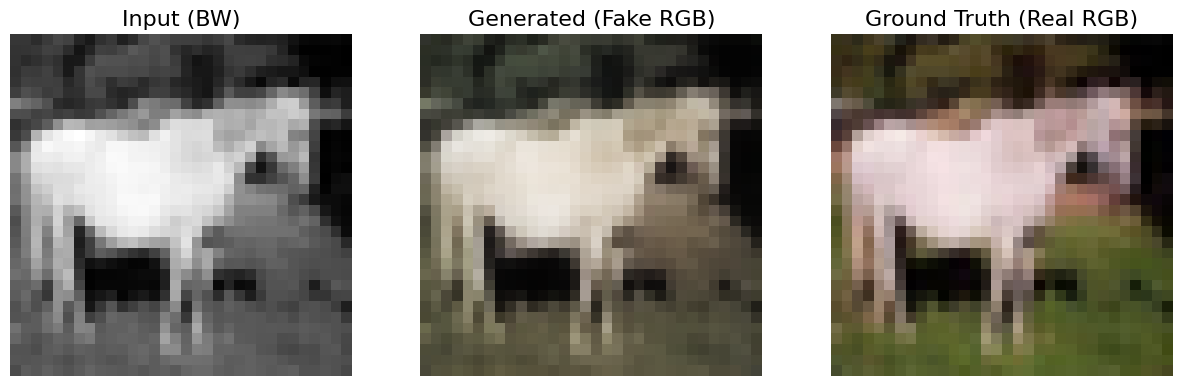

[Epoch 6/20] [Batch 350/391] [G loss: 0.0881] 
[Epoch 6/20] [Batch 360/391] [G loss: 0.0881] 
[Epoch 6/20] [Batch 370/391] [G loss: 0.0881] 
[Epoch 6/20] [Batch 380/391] [G loss: 0.0881] 
[Epoch 6/20] [Batch 390/391] [G loss: 0.0881] 


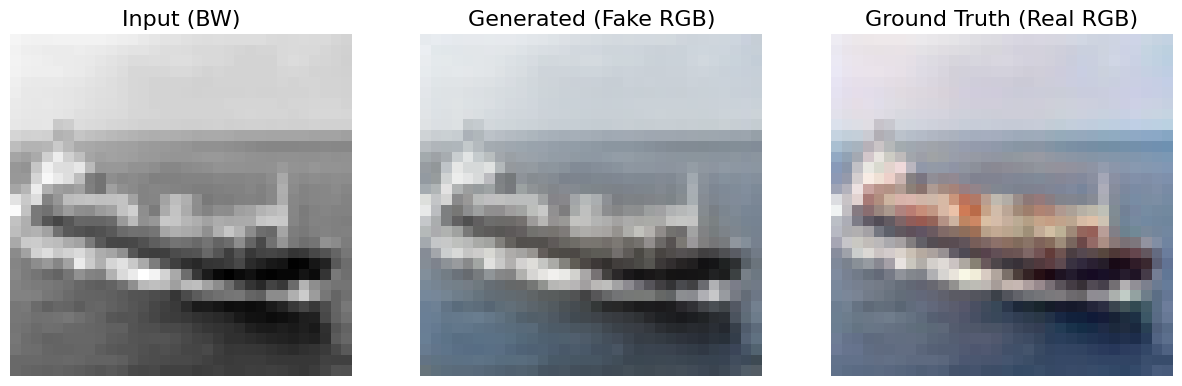

[Epoch 7/20] [Batch 0/391] [G loss: 0.0853] 
[Epoch 7/20] [Batch 10/391] [G loss: 0.0868] 
[Epoch 7/20] [Batch 20/391] [G loss: 0.0867] 
[Epoch 7/20] [Batch 30/391] [G loss: 0.0871] 
[Epoch 7/20] [Batch 40/391] [G loss: 0.0874] 


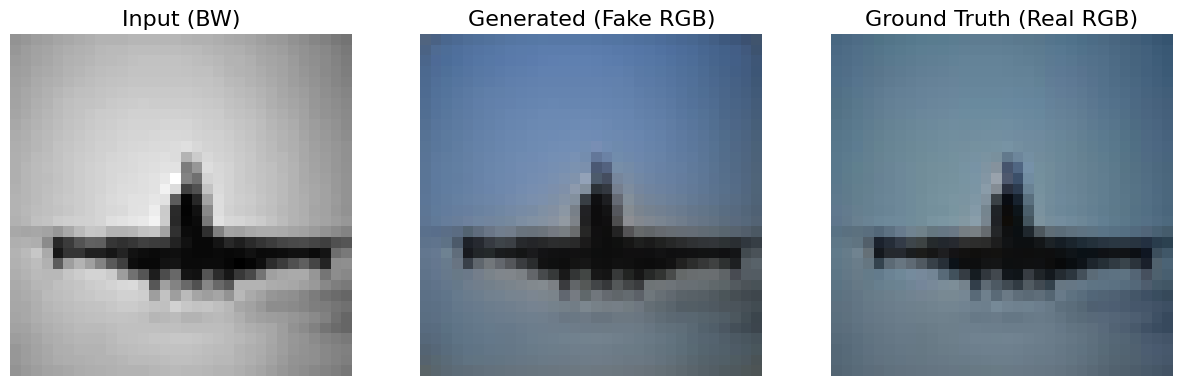

[Epoch 7/20] [Batch 50/391] [G loss: 0.0874] 
[Epoch 7/20] [Batch 60/391] [G loss: 0.0876] 
[Epoch 7/20] [Batch 70/391] [G loss: 0.0877] 
[Epoch 7/20] [Batch 80/391] [G loss: 0.0875] 
[Epoch 7/20] [Batch 90/391] [G loss: 0.0876] 


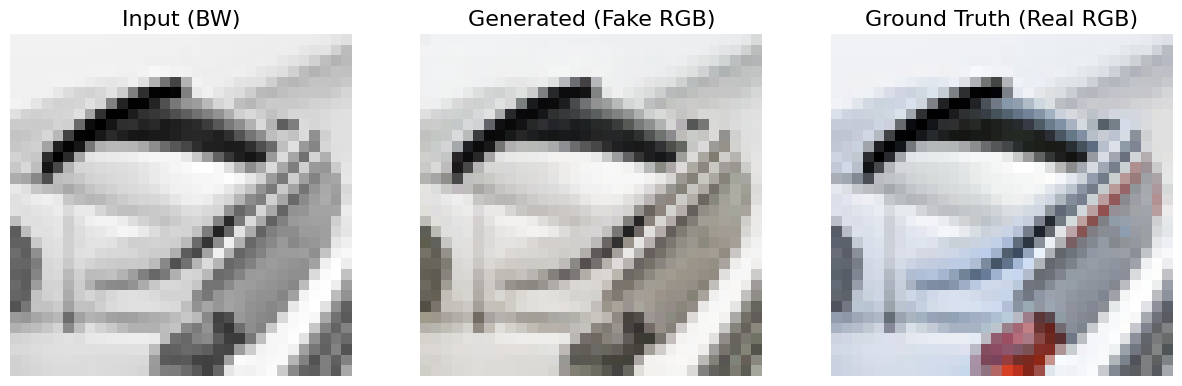

[Epoch 7/20] [Batch 100/391] [G loss: 0.0876] 
[Epoch 7/20] [Batch 110/391] [G loss: 0.0875] 
[Epoch 7/20] [Batch 120/391] [G loss: 0.0875] 
[Epoch 7/20] [Batch 130/391] [G loss: 0.0875] 
[Epoch 7/20] [Batch 140/391] [G loss: 0.0876] 


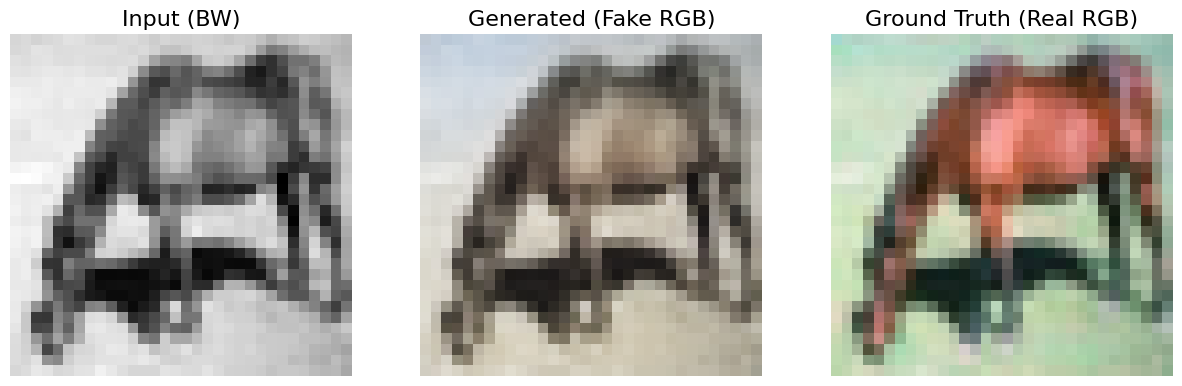

[Epoch 7/20] [Batch 150/391] [G loss: 0.0875] 
[Epoch 7/20] [Batch 160/391] [G loss: 0.0874] 
[Epoch 7/20] [Batch 170/391] [G loss: 0.0873] 
[Epoch 7/20] [Batch 180/391] [G loss: 0.0873] 
[Epoch 7/20] [Batch 190/391] [G loss: 0.0872] 


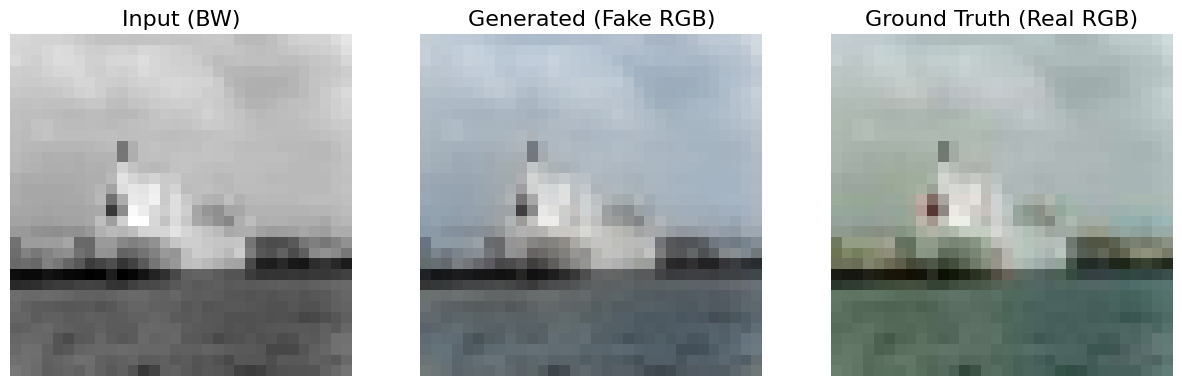

[Epoch 7/20] [Batch 200/391] [G loss: 0.0872] 
[Epoch 7/20] [Batch 210/391] [G loss: 0.0873] 
[Epoch 7/20] [Batch 220/391] [G loss: 0.0872] 
[Epoch 7/20] [Batch 230/391] [G loss: 0.0872] 
[Epoch 7/20] [Batch 240/391] [G loss: 0.0872] 


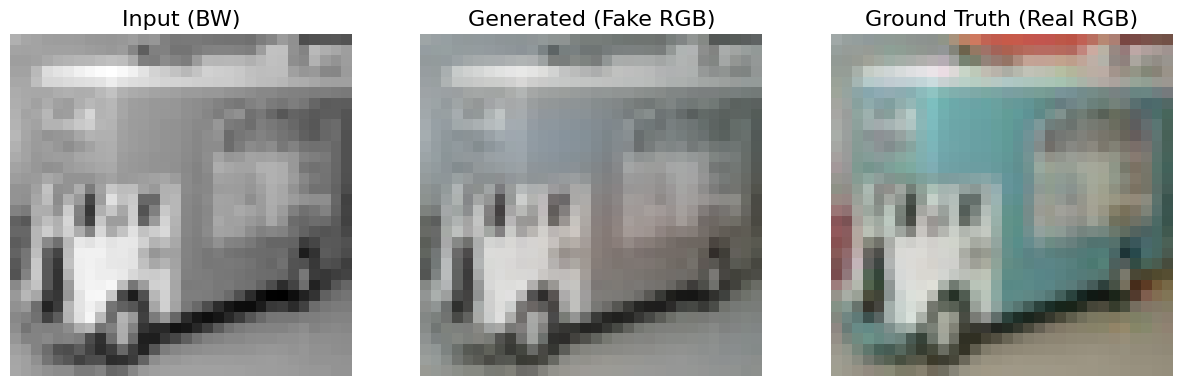

[Epoch 7/20] [Batch 250/391] [G loss: 0.0872] 
[Epoch 7/20] [Batch 260/391] [G loss: 0.0872] 
[Epoch 7/20] [Batch 270/391] [G loss: 0.0872] 
[Epoch 7/20] [Batch 280/391] [G loss: 0.0871] 
[Epoch 7/20] [Batch 290/391] [G loss: 0.0871] 


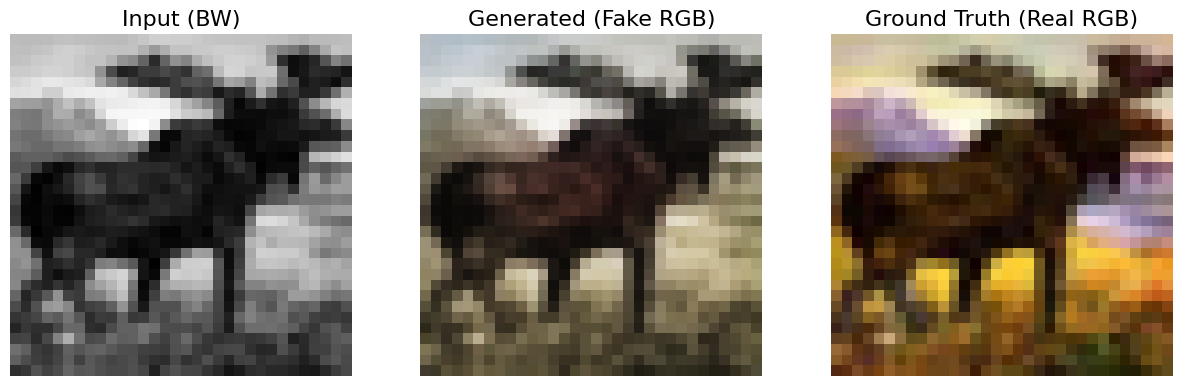

[Epoch 7/20] [Batch 300/391] [G loss: 0.0871] 
[Epoch 7/20] [Batch 310/391] [G loss: 0.0871] 
[Epoch 7/20] [Batch 320/391] [G loss: 0.0871] 
[Epoch 7/20] [Batch 330/391] [G loss: 0.0872] 
[Epoch 7/20] [Batch 340/391] [G loss: 0.0872] 


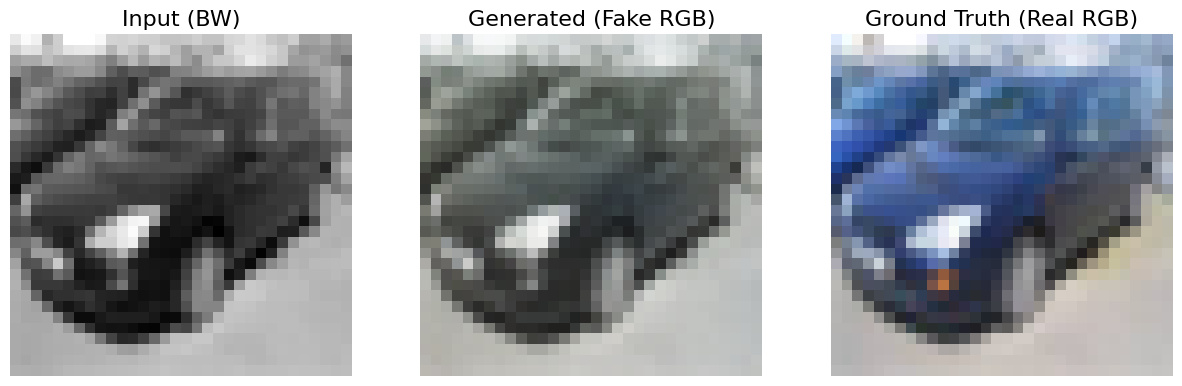

[Epoch 7/20] [Batch 350/391] [G loss: 0.0873] 
[Epoch 7/20] [Batch 360/391] [G loss: 0.0874] 
[Epoch 7/20] [Batch 370/391] [G loss: 0.0874] 
[Epoch 7/20] [Batch 380/391] [G loss: 0.0874] 
[Epoch 7/20] [Batch 390/391] [G loss: 0.0873] 


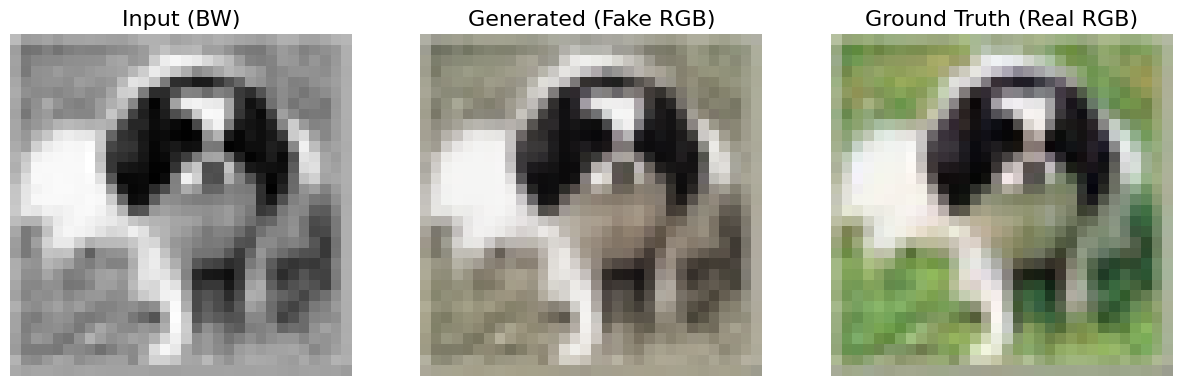

[Epoch 8/20] [Batch 0/391] [G loss: 0.0832] 
[Epoch 8/20] [Batch 10/391] [G loss: 0.0877] 
[Epoch 8/20] [Batch 20/391] [G loss: 0.0870] 
[Epoch 8/20] [Batch 30/391] [G loss: 0.0874] 
[Epoch 8/20] [Batch 40/391] [G loss: 0.0870] 


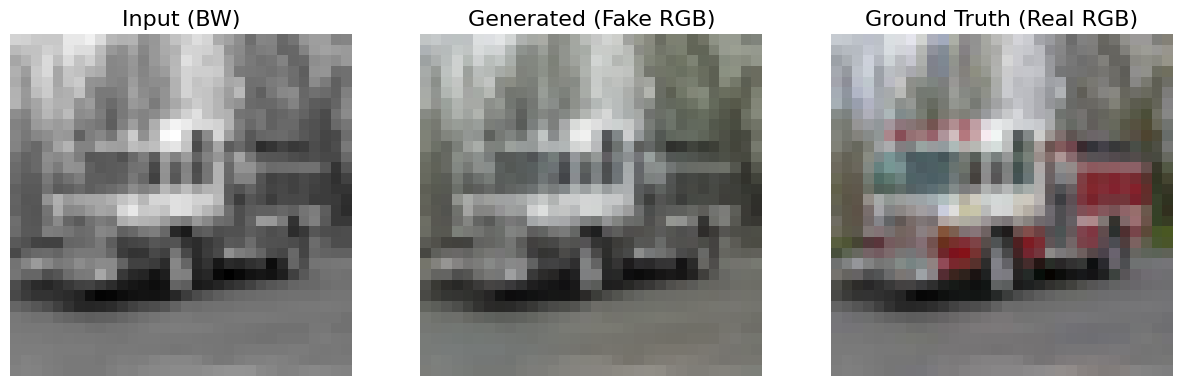

[Epoch 8/20] [Batch 50/391] [G loss: 0.0869] 
[Epoch 8/20] [Batch 60/391] [G loss: 0.0868] 
[Epoch 8/20] [Batch 70/391] [G loss: 0.0868] 
[Epoch 8/20] [Batch 80/391] [G loss: 0.0865] 
[Epoch 8/20] [Batch 90/391] [G loss: 0.0866] 


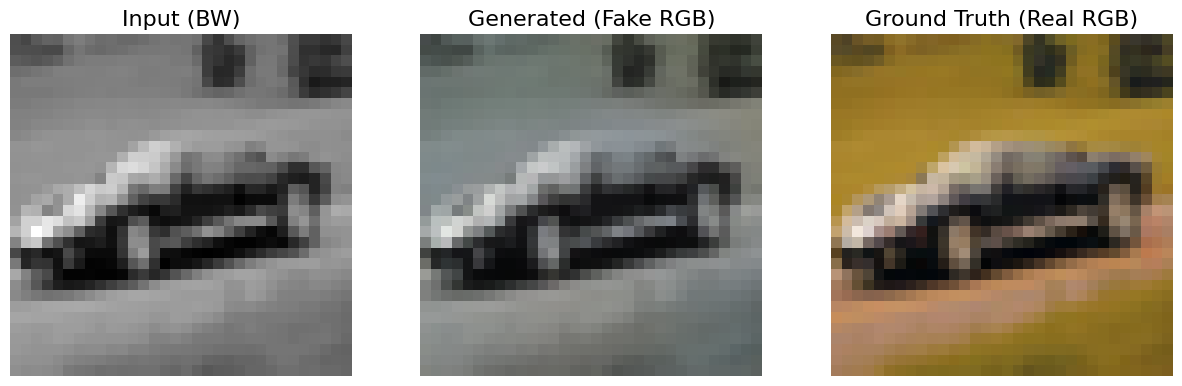

[Epoch 8/20] [Batch 100/391] [G loss: 0.0867] 
[Epoch 8/20] [Batch 110/391] [G loss: 0.0866] 
[Epoch 8/20] [Batch 120/391] [G loss: 0.0864] 
[Epoch 8/20] [Batch 130/391] [G loss: 0.0864] 
[Epoch 8/20] [Batch 140/391] [G loss: 0.0864] 


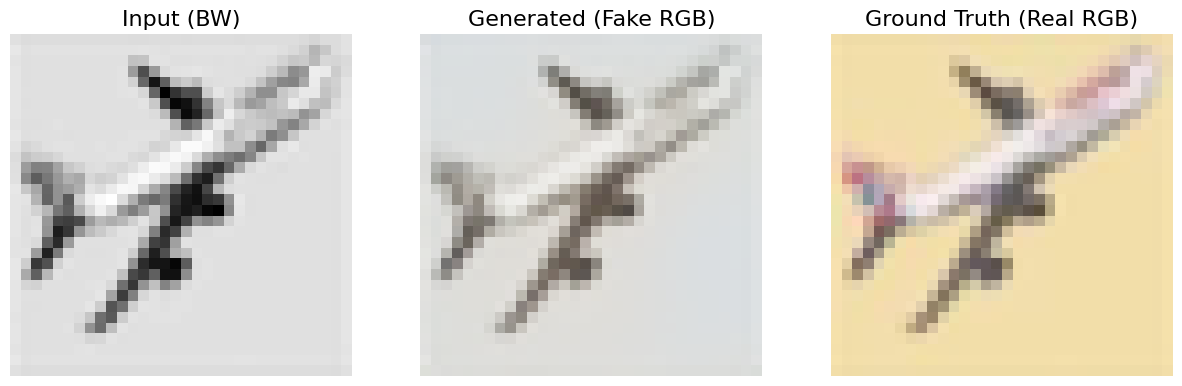

[Epoch 8/20] [Batch 150/391] [G loss: 0.0864] 
[Epoch 8/20] [Batch 160/391] [G loss: 0.0865] 
[Epoch 8/20] [Batch 170/391] [G loss: 0.0864] 
[Epoch 8/20] [Batch 180/391] [G loss: 0.0863] 
[Epoch 8/20] [Batch 190/391] [G loss: 0.0862] 


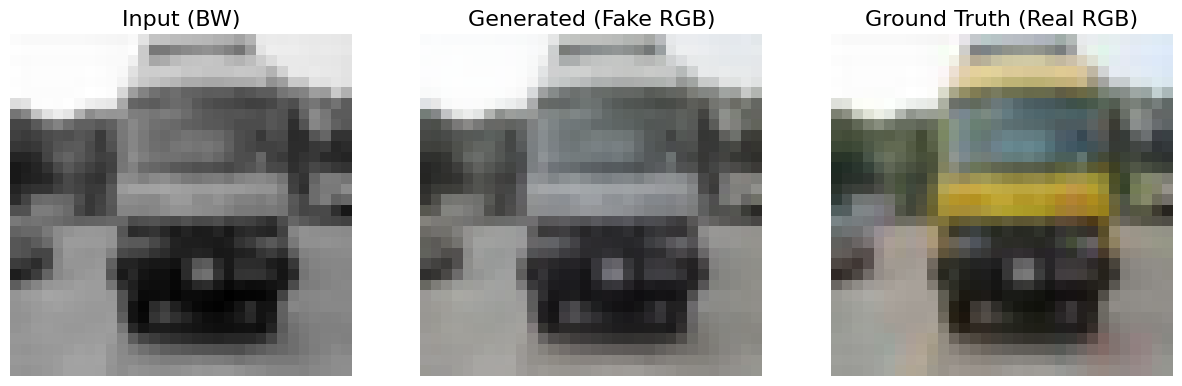

[Epoch 8/20] [Batch 200/391] [G loss: 0.0863] 
[Epoch 8/20] [Batch 210/391] [G loss: 0.0863] 
[Epoch 8/20] [Batch 220/391] [G loss: 0.0863] 
[Epoch 8/20] [Batch 230/391] [G loss: 0.0864] 
[Epoch 8/20] [Batch 240/391] [G loss: 0.0863] 


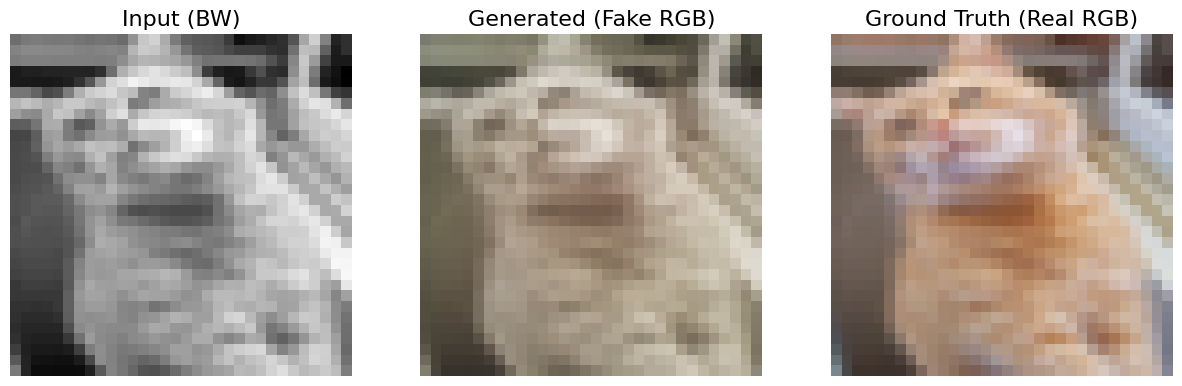

[Epoch 8/20] [Batch 250/391] [G loss: 0.0863] 
[Epoch 8/20] [Batch 260/391] [G loss: 0.0863] 
[Epoch 8/20] [Batch 270/391] [G loss: 0.0864] 
[Epoch 8/20] [Batch 280/391] [G loss: 0.0865] 
[Epoch 8/20] [Batch 290/391] [G loss: 0.0864] 


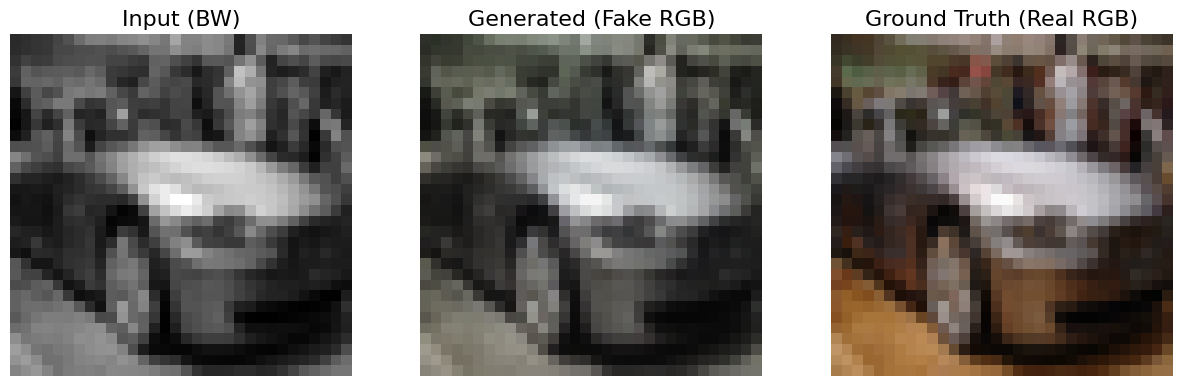

[Epoch 8/20] [Batch 300/391] [G loss: 0.0864] 
[Epoch 8/20] [Batch 310/391] [G loss: 0.0864] 
[Epoch 8/20] [Batch 320/391] [G loss: 0.0864] 
[Epoch 8/20] [Batch 330/391] [G loss: 0.0864] 
[Epoch 8/20] [Batch 340/391] [G loss: 0.0863] 


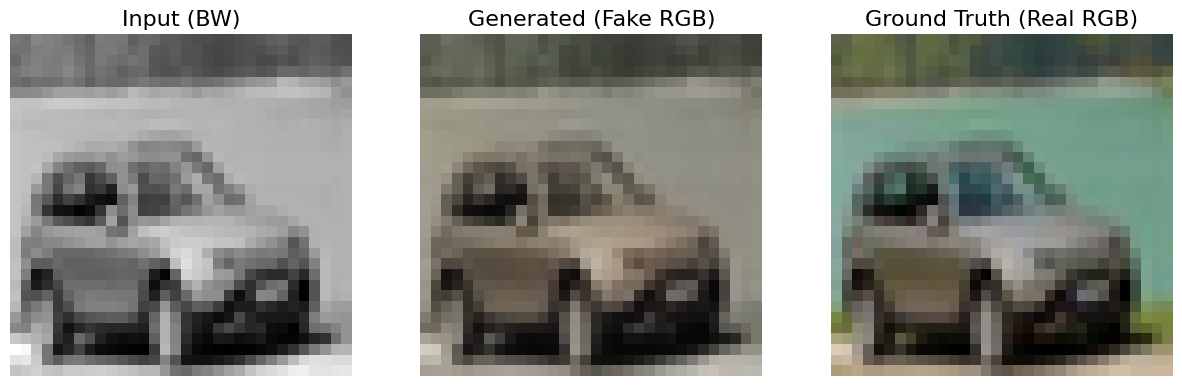

[Epoch 8/20] [Batch 350/391] [G loss: 0.0864] 
[Epoch 8/20] [Batch 360/391] [G loss: 0.0864] 
[Epoch 8/20] [Batch 370/391] [G loss: 0.0865] 
[Epoch 8/20] [Batch 380/391] [G loss: 0.0865] 
[Epoch 8/20] [Batch 390/391] [G loss: 0.0864] 


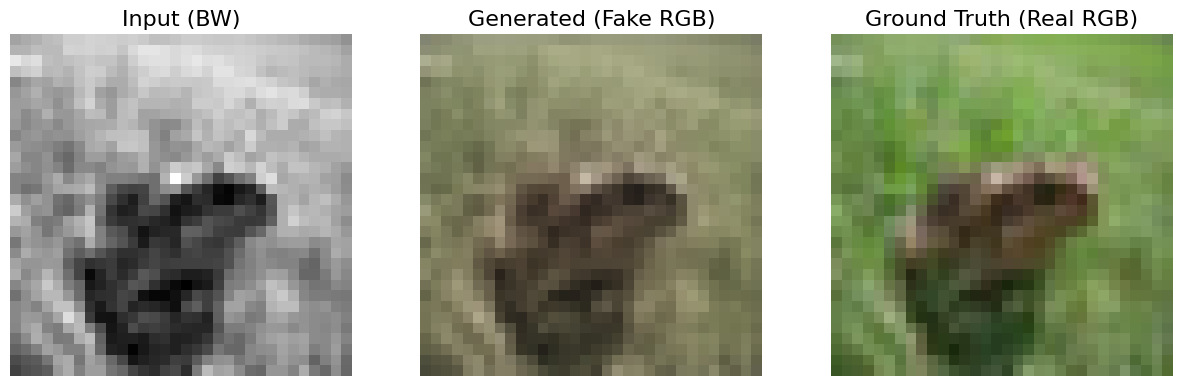

[Epoch 9/20] [Batch 0/391] [G loss: 0.0821] 
[Epoch 9/20] [Batch 10/391] [G loss: 0.0840] 
[Epoch 9/20] [Batch 20/391] [G loss: 0.0847] 
[Epoch 9/20] [Batch 30/391] [G loss: 0.0852] 
[Epoch 9/20] [Batch 40/391] [G loss: 0.0858] 


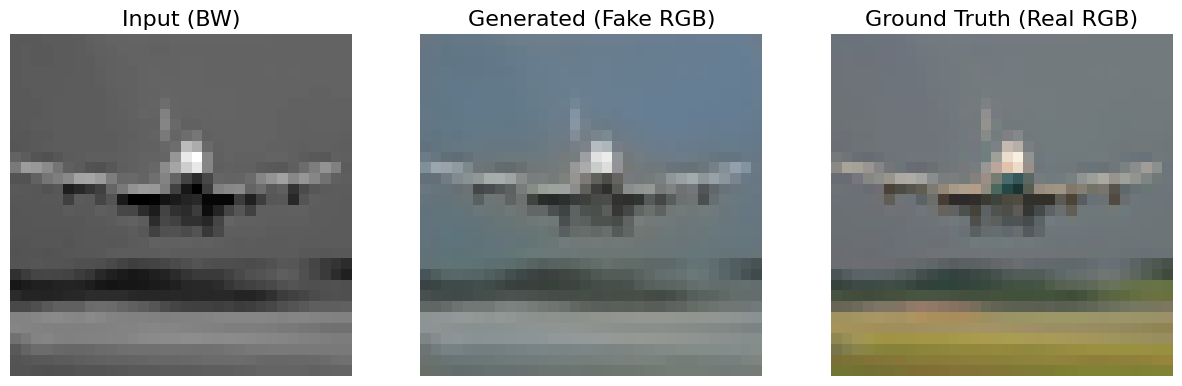

[Epoch 9/20] [Batch 50/391] [G loss: 0.0853] 
[Epoch 9/20] [Batch 60/391] [G loss: 0.0853] 
[Epoch 9/20] [Batch 70/391] [G loss: 0.0856] 
[Epoch 9/20] [Batch 80/391] [G loss: 0.0857] 
[Epoch 9/20] [Batch 90/391] [G loss: 0.0859] 


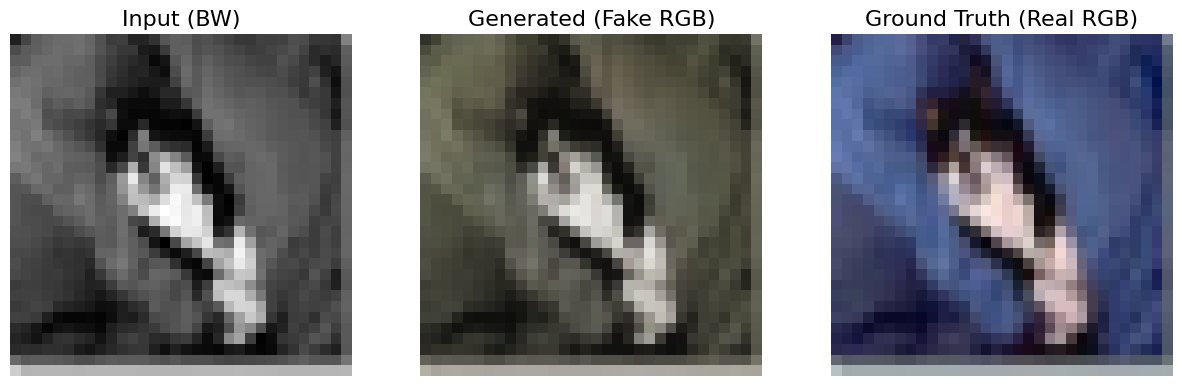

[Epoch 9/20] [Batch 100/391] [G loss: 0.0860] 
[Epoch 9/20] [Batch 110/391] [G loss: 0.0861] 
[Epoch 9/20] [Batch 120/391] [G loss: 0.0859] 
[Epoch 9/20] [Batch 130/391] [G loss: 0.0857] 
[Epoch 9/20] [Batch 140/391] [G loss: 0.0858] 


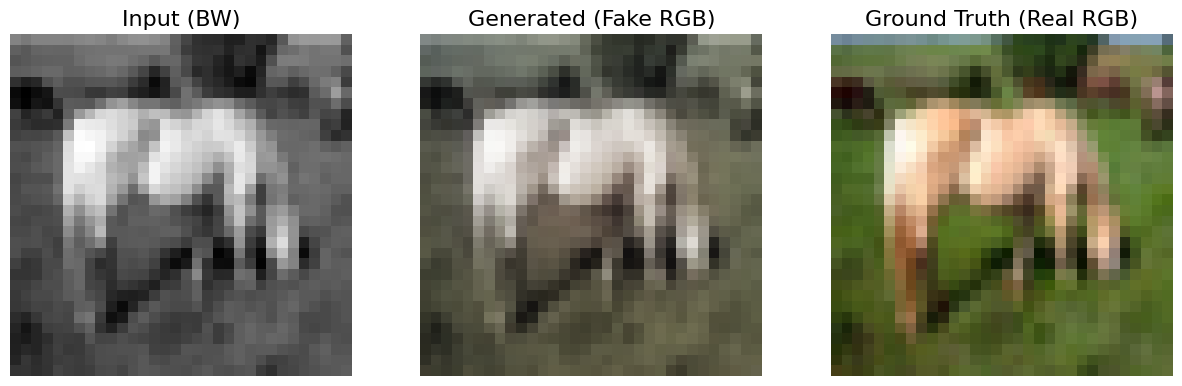

[Epoch 9/20] [Batch 150/391] [G loss: 0.0857] 
[Epoch 9/20] [Batch 160/391] [G loss: 0.0857] 
[Epoch 9/20] [Batch 170/391] [G loss: 0.0858] 
[Epoch 9/20] [Batch 180/391] [G loss: 0.0858] 
[Epoch 9/20] [Batch 190/391] [G loss: 0.0857] 


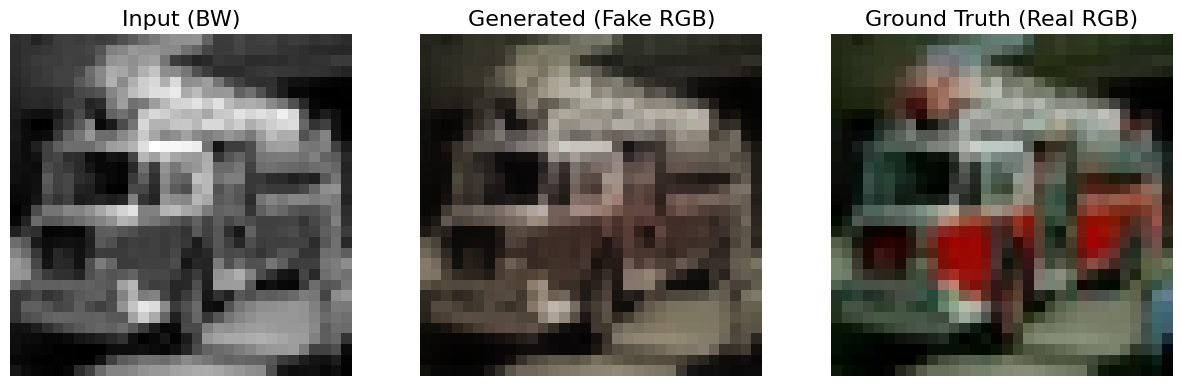

[Epoch 9/20] [Batch 200/391] [G loss: 0.0857] 
[Epoch 9/20] [Batch 210/391] [G loss: 0.0857] 
[Epoch 9/20] [Batch 220/391] [G loss: 0.0858] 
[Epoch 9/20] [Batch 230/391] [G loss: 0.0857] 
[Epoch 9/20] [Batch 240/391] [G loss: 0.0857] 


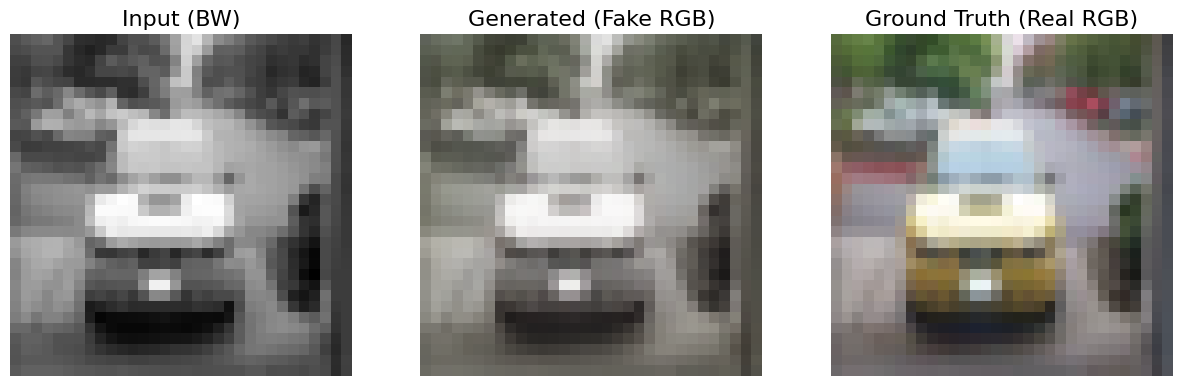

[Epoch 9/20] [Batch 250/391] [G loss: 0.0856] 
[Epoch 9/20] [Batch 260/391] [G loss: 0.0857] 
[Epoch 9/20] [Batch 270/391] [G loss: 0.0857] 
[Epoch 9/20] [Batch 280/391] [G loss: 0.0857] 
[Epoch 9/20] [Batch 290/391] [G loss: 0.0857] 


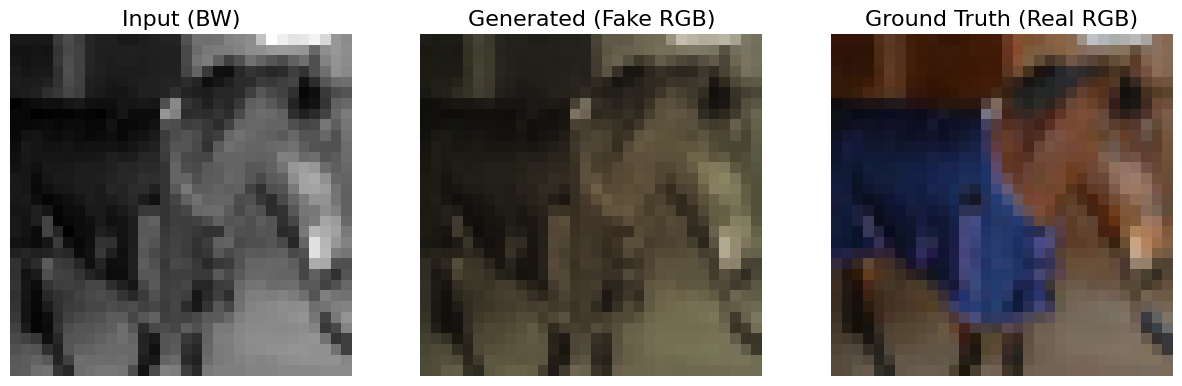

[Epoch 9/20] [Batch 300/391] [G loss: 0.0857] 
[Epoch 9/20] [Batch 310/391] [G loss: 0.0857] 
[Epoch 9/20] [Batch 320/391] [G loss: 0.0856] 
[Epoch 9/20] [Batch 330/391] [G loss: 0.0856] 
[Epoch 9/20] [Batch 340/391] [G loss: 0.0857] 


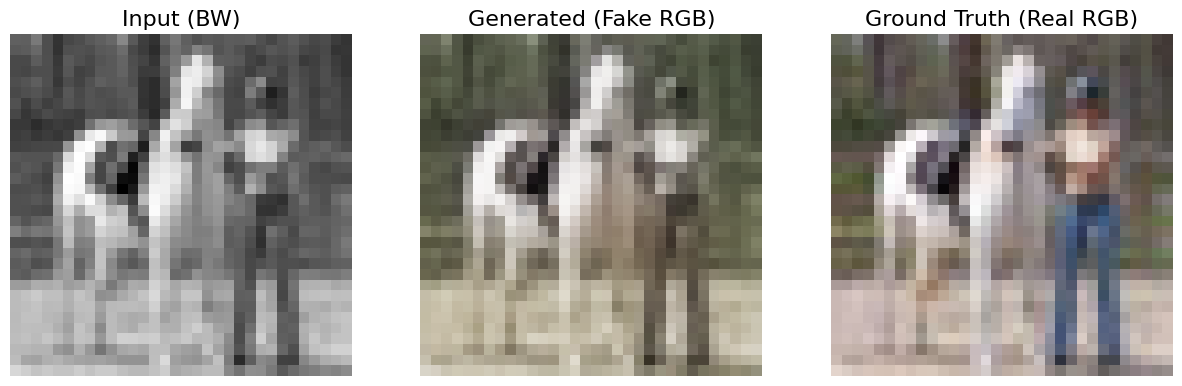

[Epoch 9/20] [Batch 350/391] [G loss: 0.0857] 
[Epoch 9/20] [Batch 360/391] [G loss: 0.0857] 
[Epoch 9/20] [Batch 370/391] [G loss: 0.0856] 
[Epoch 9/20] [Batch 380/391] [G loss: 0.0856] 
[Epoch 9/20] [Batch 390/391] [G loss: 0.0856] 


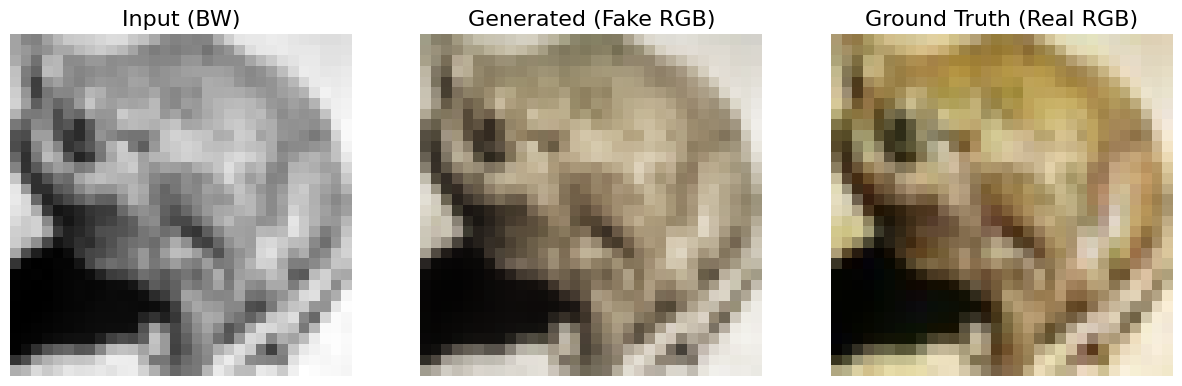

[Epoch 10/20] [Batch 0/391] [G loss: 0.0781] 
[Epoch 10/20] [Batch 10/391] [G loss: 0.0830] 
[Epoch 10/20] [Batch 20/391] [G loss: 0.0838] 
[Epoch 10/20] [Batch 30/391] [G loss: 0.0842] 
[Epoch 10/20] [Batch 40/391] [G loss: 0.0845] 


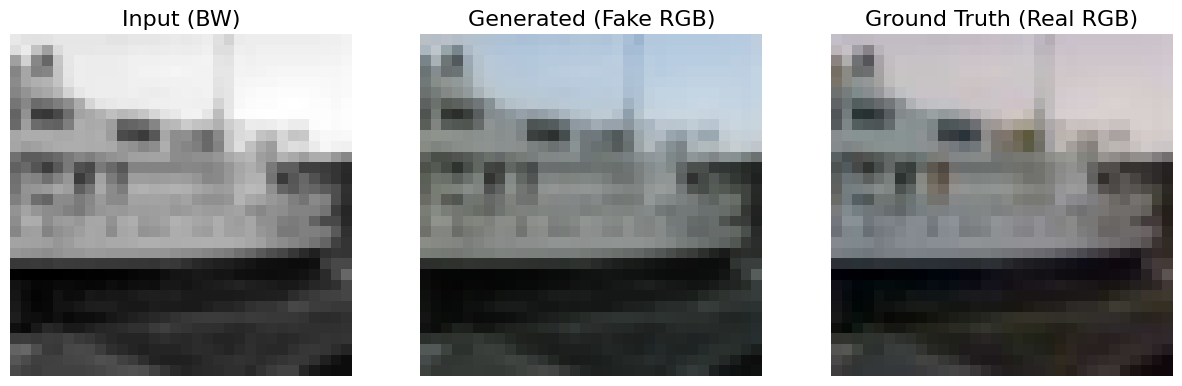

[Epoch 10/20] [Batch 50/391] [G loss: 0.0845] 
[Epoch 10/20] [Batch 60/391] [G loss: 0.0847] 
[Epoch 10/20] [Batch 70/391] [G loss: 0.0847] 
[Epoch 10/20] [Batch 80/391] [G loss: 0.0847] 
[Epoch 10/20] [Batch 90/391] [G loss: 0.0847] 


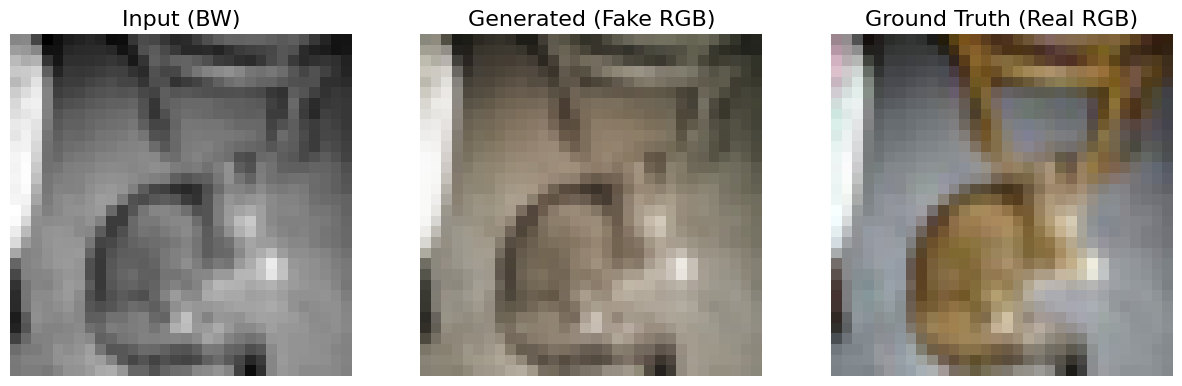

[Epoch 10/20] [Batch 100/391] [G loss: 0.0848] 
[Epoch 10/20] [Batch 110/391] [G loss: 0.0847] 
[Epoch 10/20] [Batch 120/391] [G loss: 0.0846] 
[Epoch 10/20] [Batch 130/391] [G loss: 0.0845] 
[Epoch 10/20] [Batch 140/391] [G loss: 0.0845] 


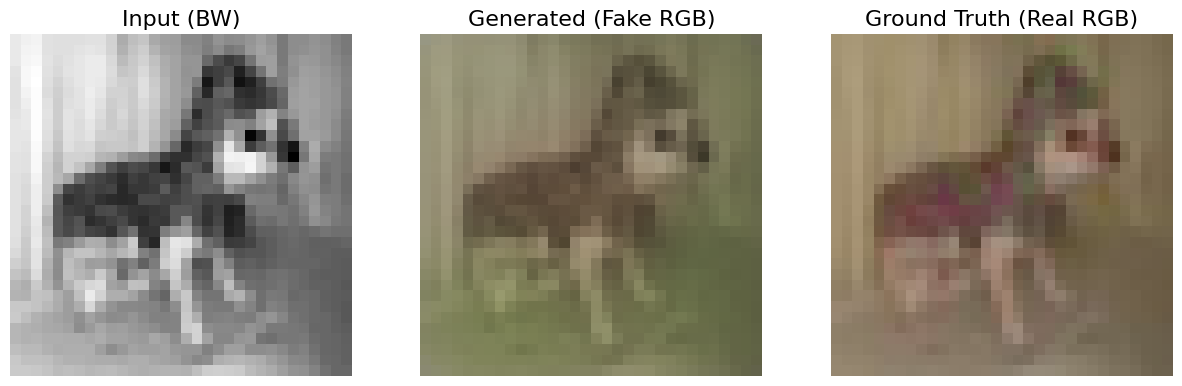

[Epoch 10/20] [Batch 150/391] [G loss: 0.0844] 
[Epoch 10/20] [Batch 160/391] [G loss: 0.0845] 
[Epoch 10/20] [Batch 170/391] [G loss: 0.0846] 
[Epoch 10/20] [Batch 180/391] [G loss: 0.0846] 
[Epoch 10/20] [Batch 190/391] [G loss: 0.0846] 


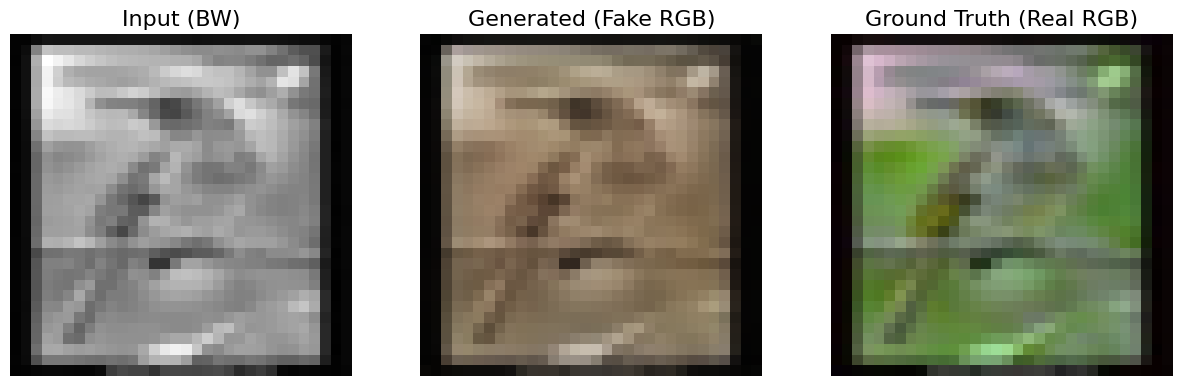

[Epoch 10/20] [Batch 200/391] [G loss: 0.0847] 
[Epoch 10/20] [Batch 210/391] [G loss: 0.0847] 
[Epoch 10/20] [Batch 220/391] [G loss: 0.0846] 
[Epoch 10/20] [Batch 230/391] [G loss: 0.0847] 
[Epoch 10/20] [Batch 240/391] [G loss: 0.0846] 


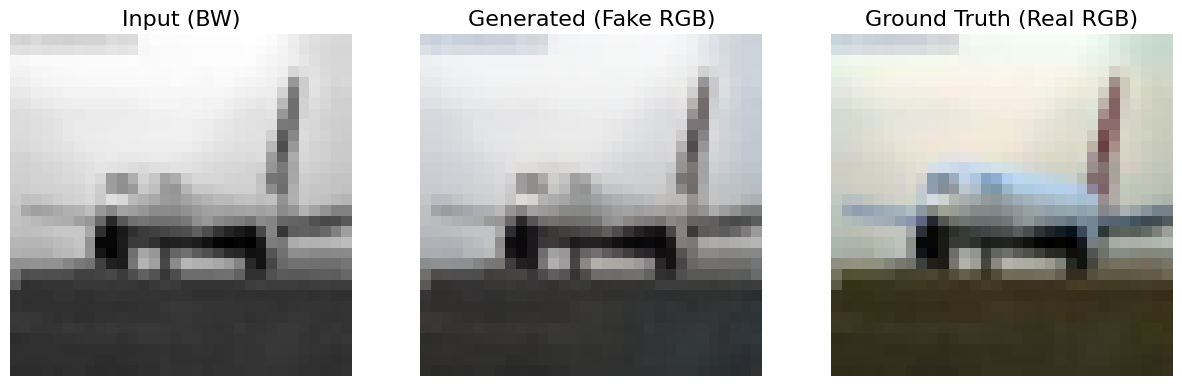

[Epoch 10/20] [Batch 250/391] [G loss: 0.0847] 
[Epoch 10/20] [Batch 260/391] [G loss: 0.0847] 
[Epoch 10/20] [Batch 270/391] [G loss: 0.0847] 
[Epoch 10/20] [Batch 280/391] [G loss: 0.0847] 
[Epoch 10/20] [Batch 290/391] [G loss: 0.0847] 


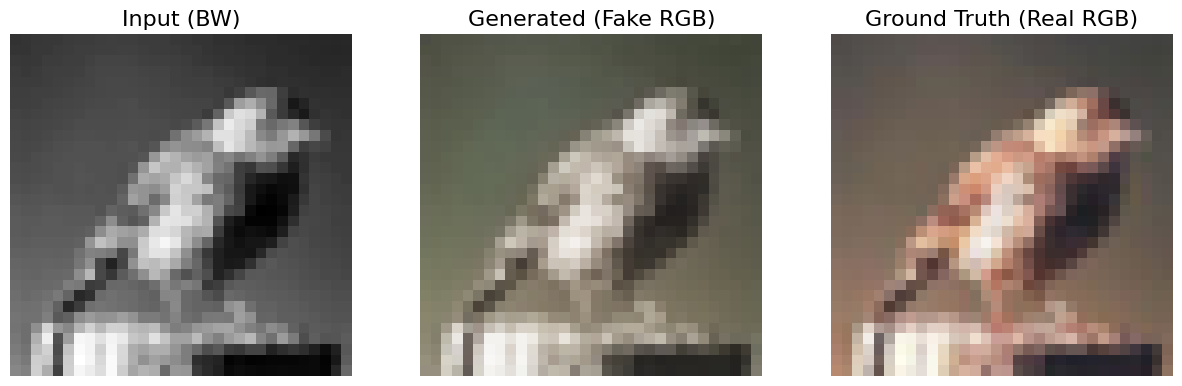

[Epoch 10/20] [Batch 300/391] [G loss: 0.0846] 
[Epoch 10/20] [Batch 310/391] [G loss: 0.0847] 
[Epoch 10/20] [Batch 320/391] [G loss: 0.0847] 
[Epoch 10/20] [Batch 330/391] [G loss: 0.0847] 
[Epoch 10/20] [Batch 340/391] [G loss: 0.0848] 


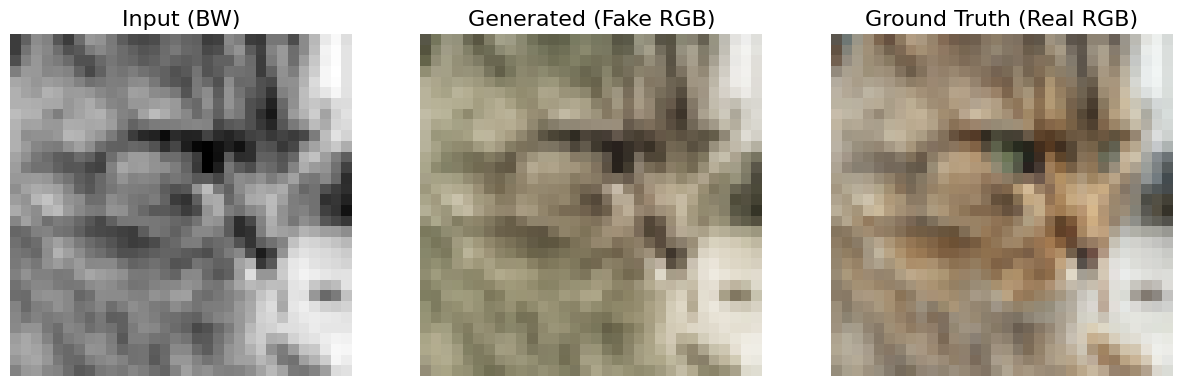

[Epoch 10/20] [Batch 350/391] [G loss: 0.0848] 
[Epoch 10/20] [Batch 360/391] [G loss: 0.0848] 
[Epoch 10/20] [Batch 370/391] [G loss: 0.0848] 
[Epoch 10/20] [Batch 380/391] [G loss: 0.0848] 
[Epoch 10/20] [Batch 390/391] [G loss: 0.0848] 


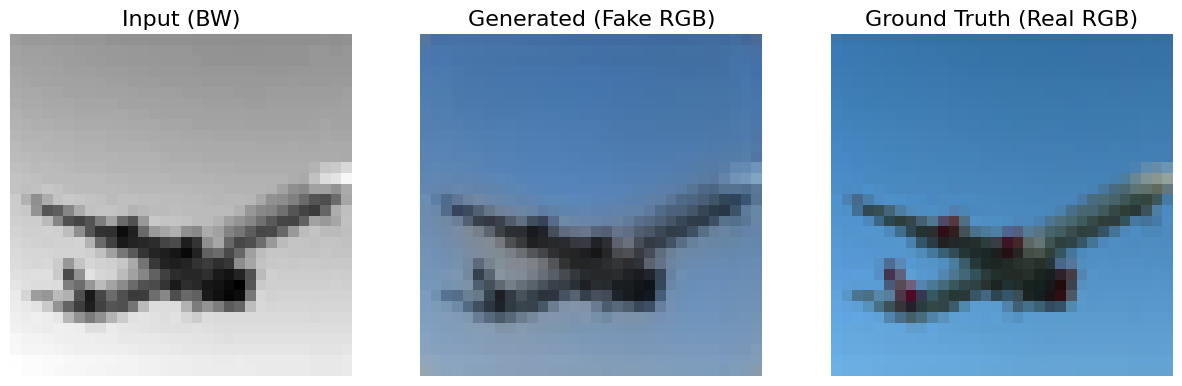

[Epoch 11/20] [Batch 0/391] [G loss: 0.0910] 
[Epoch 11/20] [Batch 10/391] [G loss: 0.0844] 
[Epoch 11/20] [Batch 20/391] [G loss: 0.0846] 
[Epoch 11/20] [Batch 30/391] [G loss: 0.0838] 
[Epoch 11/20] [Batch 40/391] [G loss: 0.0841] 


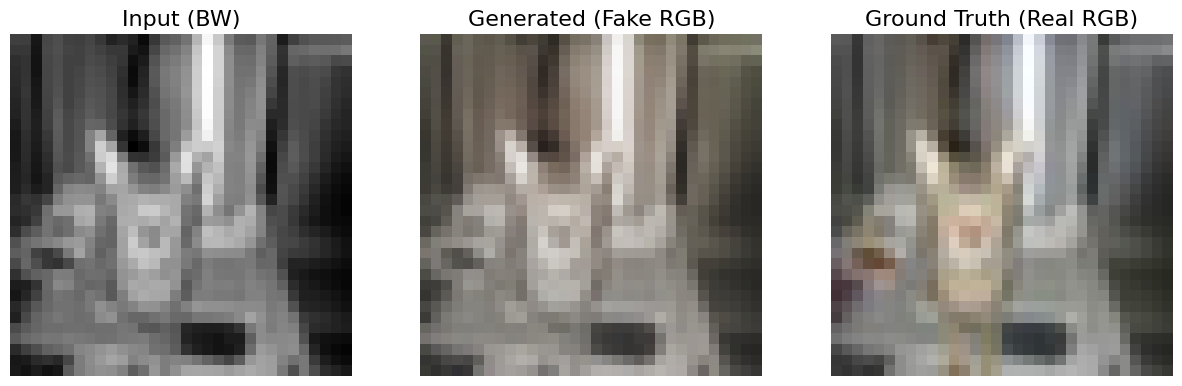

[Epoch 11/20] [Batch 50/391] [G loss: 0.0837] 
[Epoch 11/20] [Batch 60/391] [G loss: 0.0835] 
[Epoch 11/20] [Batch 70/391] [G loss: 0.0835] 
[Epoch 11/20] [Batch 80/391] [G loss: 0.0836] 
[Epoch 11/20] [Batch 90/391] [G loss: 0.0837] 


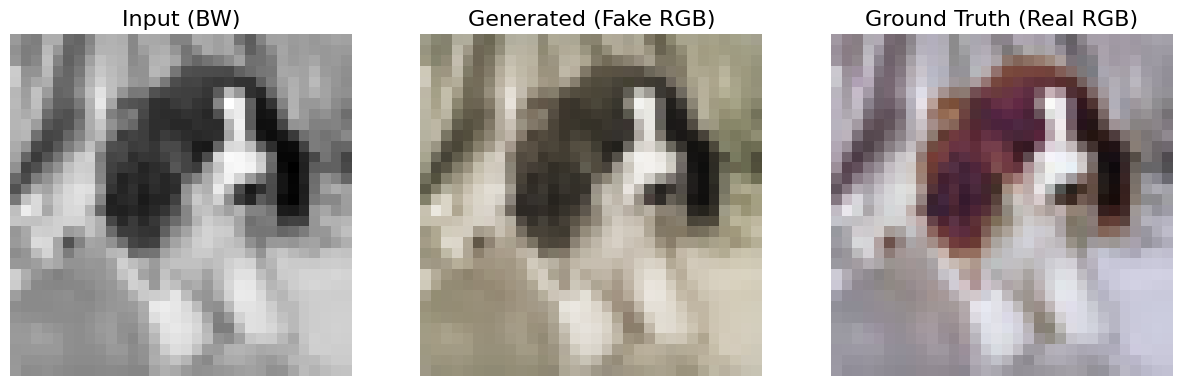

[Epoch 11/20] [Batch 100/391] [G loss: 0.0836] 
[Epoch 11/20] [Batch 110/391] [G loss: 0.0837] 
[Epoch 11/20] [Batch 120/391] [G loss: 0.0836] 
[Epoch 11/20] [Batch 130/391] [G loss: 0.0837] 
[Epoch 11/20] [Batch 140/391] [G loss: 0.0836] 


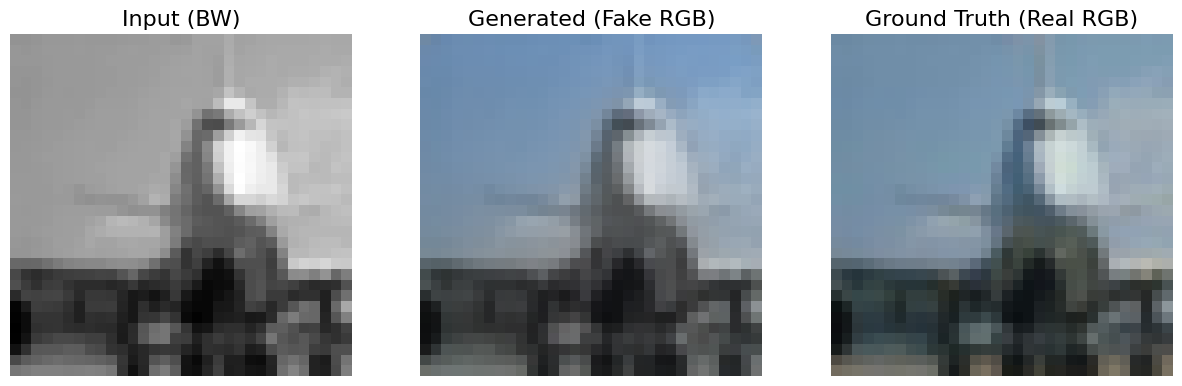

[Epoch 11/20] [Batch 150/391] [G loss: 0.0837] 
[Epoch 11/20] [Batch 160/391] [G loss: 0.0836] 
[Epoch 11/20] [Batch 170/391] [G loss: 0.0837] 
[Epoch 11/20] [Batch 180/391] [G loss: 0.0836] 
[Epoch 11/20] [Batch 190/391] [G loss: 0.0835] 


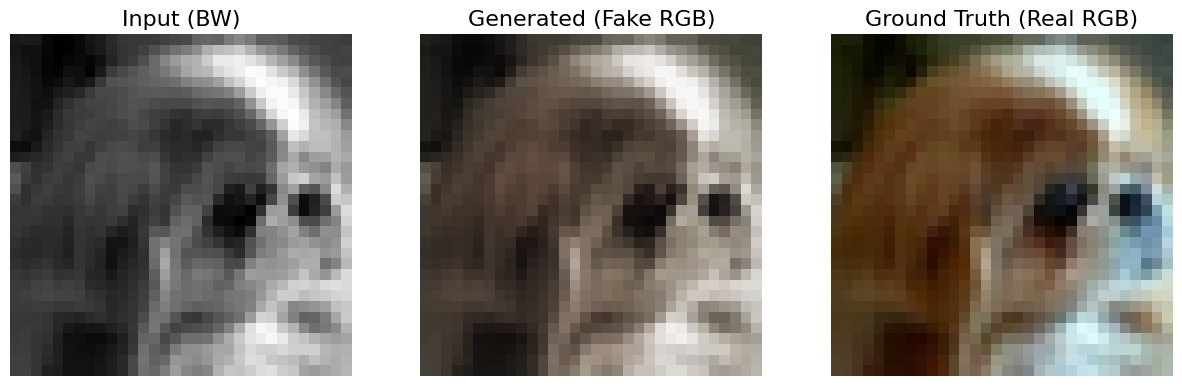

[Epoch 11/20] [Batch 200/391] [G loss: 0.0836] 
[Epoch 11/20] [Batch 210/391] [G loss: 0.0836] 
[Epoch 11/20] [Batch 220/391] [G loss: 0.0837] 
[Epoch 11/20] [Batch 230/391] [G loss: 0.0838] 
[Epoch 11/20] [Batch 240/391] [G loss: 0.0838] 


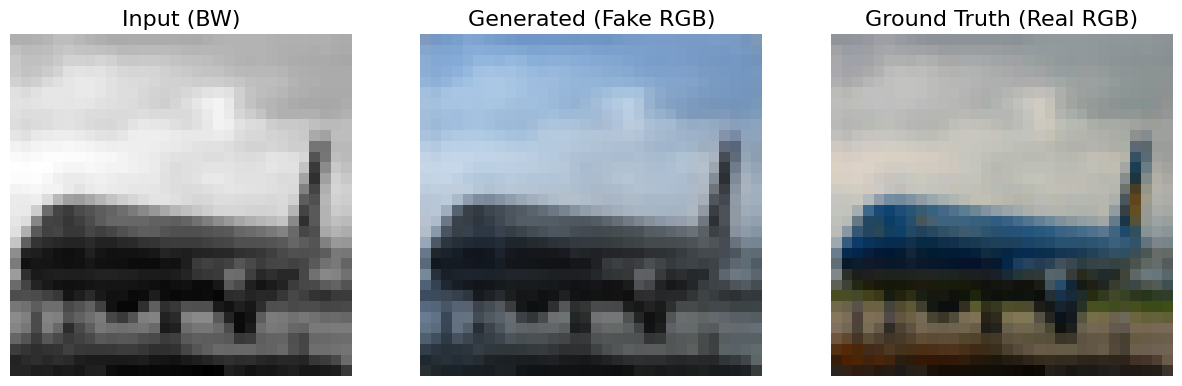

[Epoch 11/20] [Batch 250/391] [G loss: 0.0839] 
[Epoch 11/20] [Batch 260/391] [G loss: 0.0839] 
[Epoch 11/20] [Batch 270/391] [G loss: 0.0839] 
[Epoch 11/20] [Batch 280/391] [G loss: 0.0838] 
[Epoch 11/20] [Batch 290/391] [G loss: 0.0838] 


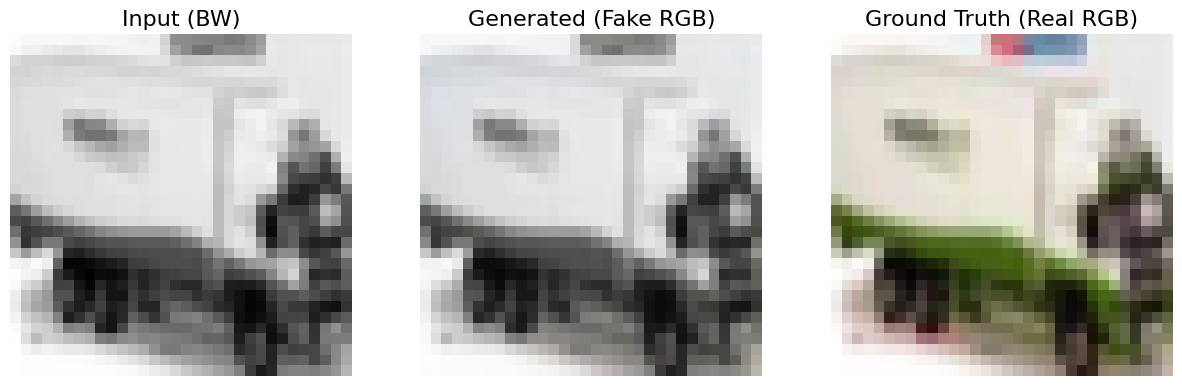

[Epoch 11/20] [Batch 300/391] [G loss: 0.0838] 
[Epoch 11/20] [Batch 310/391] [G loss: 0.0839] 
[Epoch 11/20] [Batch 320/391] [G loss: 0.0839] 
[Epoch 11/20] [Batch 330/391] [G loss: 0.0839] 
[Epoch 11/20] [Batch 340/391] [G loss: 0.0839] 


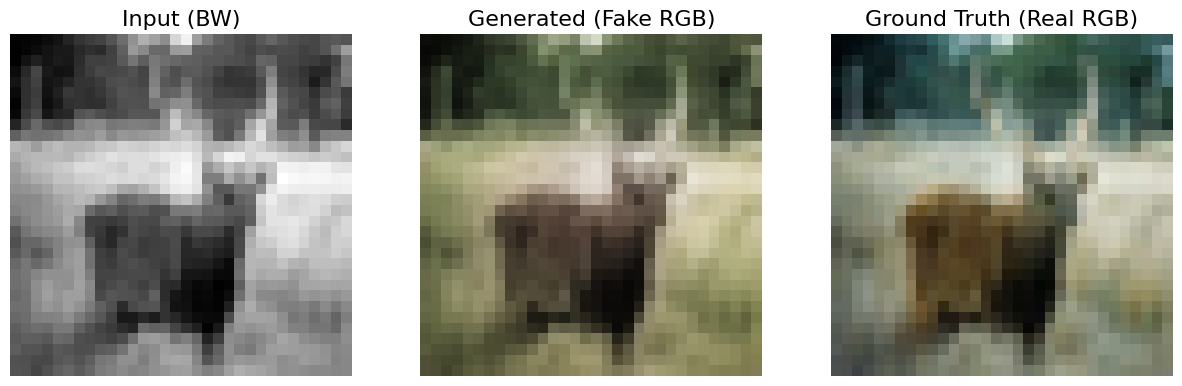

[Epoch 11/20] [Batch 350/391] [G loss: 0.0839] 
[Epoch 11/20] [Batch 360/391] [G loss: 0.0839] 
[Epoch 11/20] [Batch 370/391] [G loss: 0.0838] 
[Epoch 11/20] [Batch 380/391] [G loss: 0.0839] 
[Epoch 11/20] [Batch 390/391] [G loss: 0.0839] 


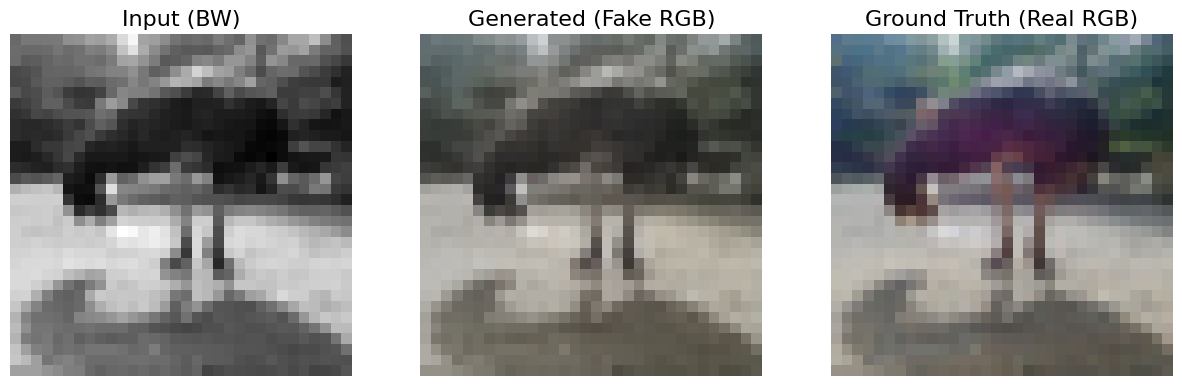

[Epoch 12/20] [Batch 0/391] [G loss: 0.0833] 
[Epoch 12/20] [Batch 10/391] [G loss: 0.0825] 
[Epoch 12/20] [Batch 20/391] [G loss: 0.0820] 
[Epoch 12/20] [Batch 30/391] [G loss: 0.0830] 
[Epoch 12/20] [Batch 40/391] [G loss: 0.0829] 


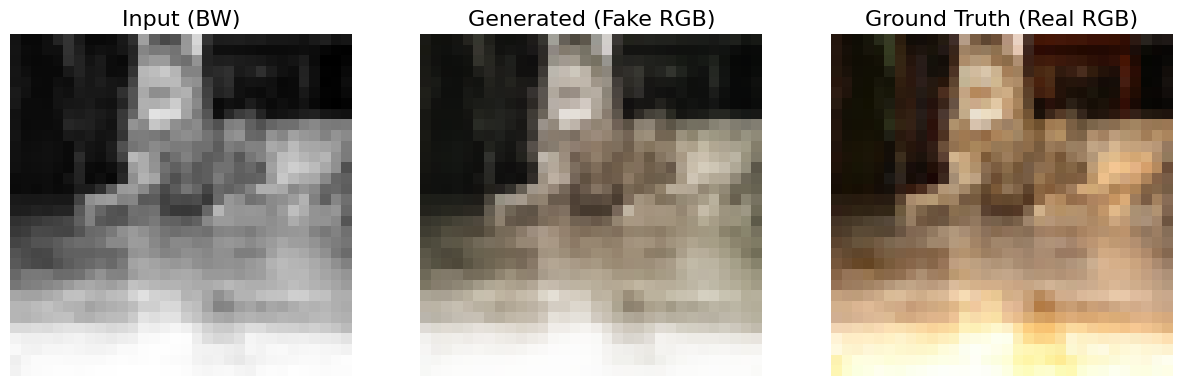

[Epoch 12/20] [Batch 50/391] [G loss: 0.0830] 
[Epoch 12/20] [Batch 60/391] [G loss: 0.0828] 
[Epoch 12/20] [Batch 70/391] [G loss: 0.0826] 
[Epoch 12/20] [Batch 80/391] [G loss: 0.0828] 
[Epoch 12/20] [Batch 90/391] [G loss: 0.0827] 


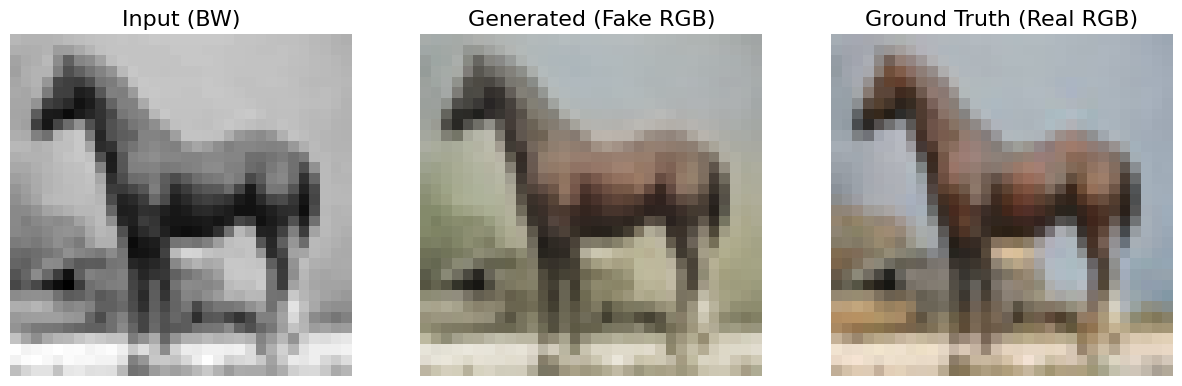

[Epoch 12/20] [Batch 100/391] [G loss: 0.0830] 
[Epoch 12/20] [Batch 110/391] [G loss: 0.0831] 
[Epoch 12/20] [Batch 120/391] [G loss: 0.0830] 
[Epoch 12/20] [Batch 130/391] [G loss: 0.0830] 
[Epoch 12/20] [Batch 140/391] [G loss: 0.0829] 


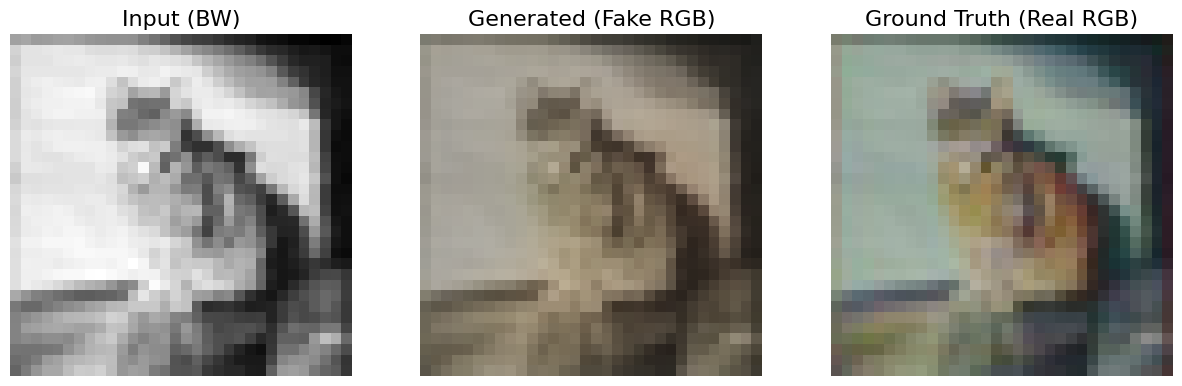

[Epoch 12/20] [Batch 150/391] [G loss: 0.0830] 
[Epoch 12/20] [Batch 160/391] [G loss: 0.0831] 
[Epoch 12/20] [Batch 170/391] [G loss: 0.0831] 
[Epoch 12/20] [Batch 180/391] [G loss: 0.0832] 
[Epoch 12/20] [Batch 190/391] [G loss: 0.0831] 


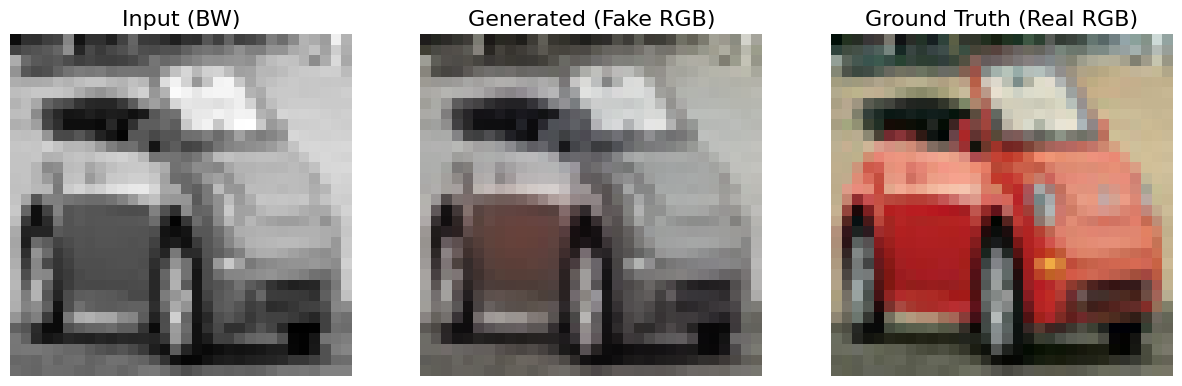

[Epoch 12/20] [Batch 200/391] [G loss: 0.0832] 
[Epoch 12/20] [Batch 210/391] [G loss: 0.0832] 
[Epoch 12/20] [Batch 220/391] [G loss: 0.0832] 
[Epoch 12/20] [Batch 230/391] [G loss: 0.0831] 
[Epoch 12/20] [Batch 240/391] [G loss: 0.0831] 


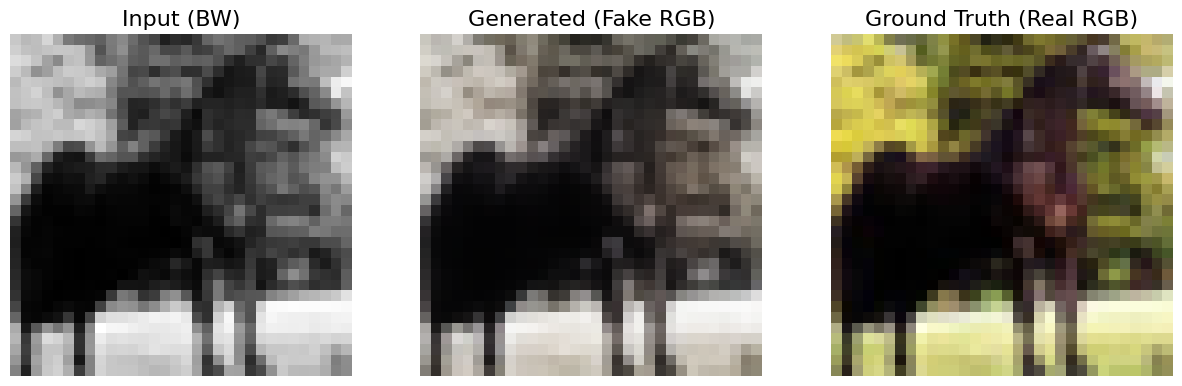

[Epoch 12/20] [Batch 250/391] [G loss: 0.0830] 
[Epoch 12/20] [Batch 260/391] [G loss: 0.0830] 
[Epoch 12/20] [Batch 270/391] [G loss: 0.0830] 
[Epoch 12/20] [Batch 280/391] [G loss: 0.0829] 
[Epoch 12/20] [Batch 290/391] [G loss: 0.0829] 


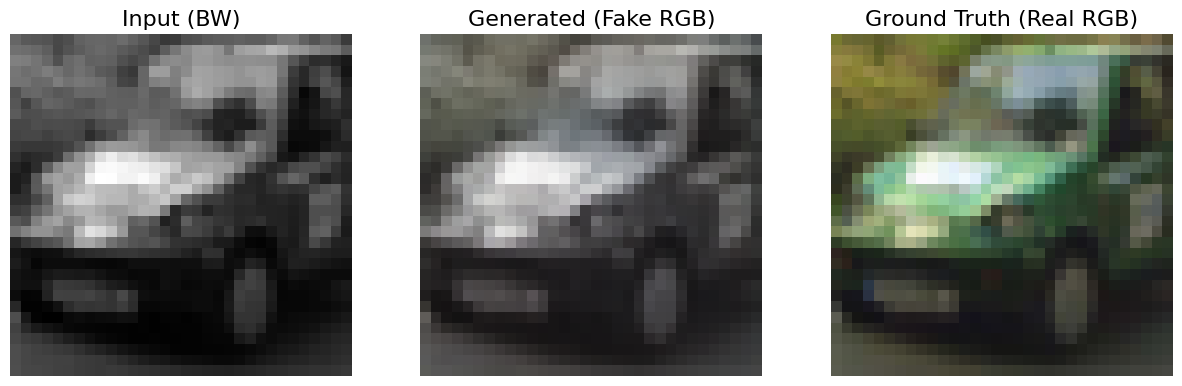

[Epoch 12/20] [Batch 300/391] [G loss: 0.0828] 
[Epoch 12/20] [Batch 310/391] [G loss: 0.0828] 
[Epoch 12/20] [Batch 320/391] [G loss: 0.0828] 
[Epoch 12/20] [Batch 330/391] [G loss: 0.0828] 
[Epoch 12/20] [Batch 340/391] [G loss: 0.0828] 


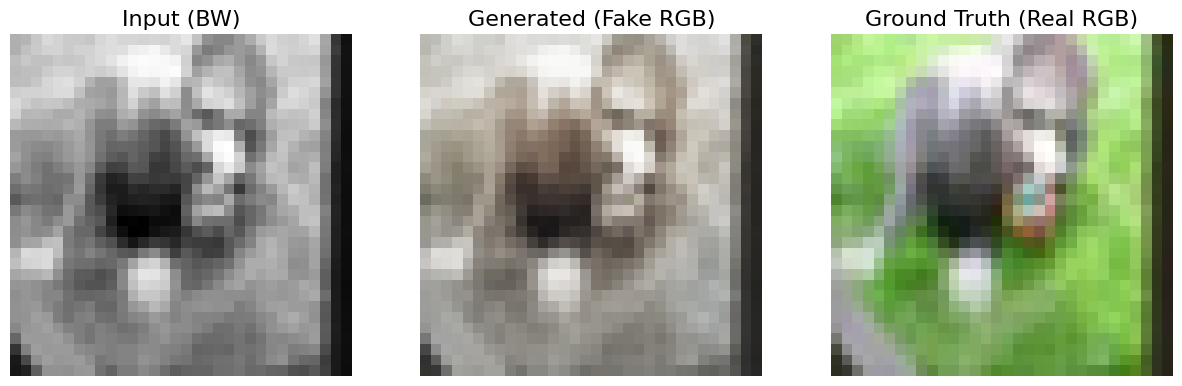

[Epoch 12/20] [Batch 350/391] [G loss: 0.0828] 
[Epoch 12/20] [Batch 360/391] [G loss: 0.0828] 
[Epoch 12/20] [Batch 370/391] [G loss: 0.0828] 
[Epoch 12/20] [Batch 380/391] [G loss: 0.0828] 
[Epoch 12/20] [Batch 390/391] [G loss: 0.0828] 


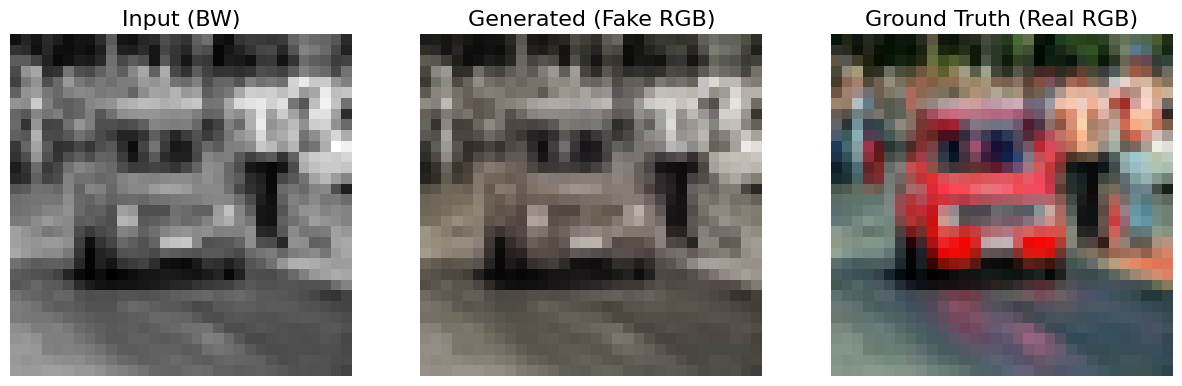

[Epoch 13/20] [Batch 0/391] [G loss: 0.0794] 
[Epoch 13/20] [Batch 10/391] [G loss: 0.0817] 
[Epoch 13/20] [Batch 20/391] [G loss: 0.0820] 
[Epoch 13/20] [Batch 30/391] [G loss: 0.0821] 
[Epoch 13/20] [Batch 40/391] [G loss: 0.0820] 


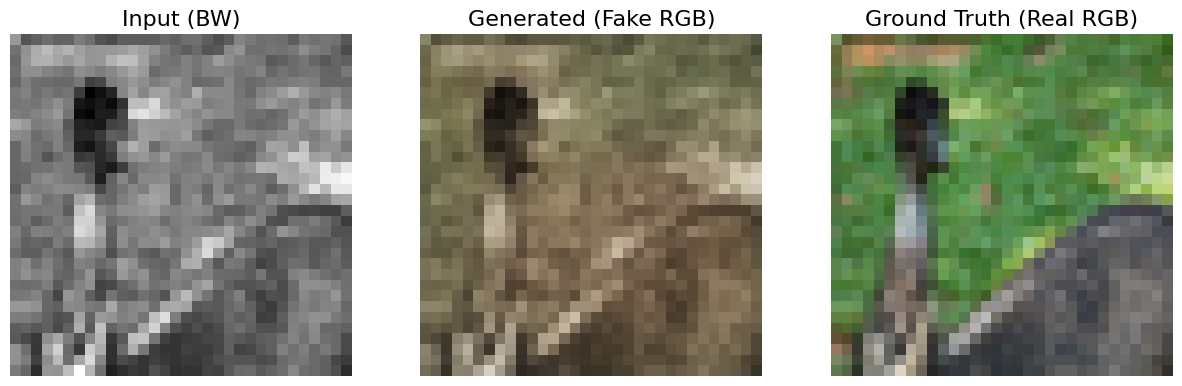

[Epoch 13/20] [Batch 50/391] [G loss: 0.0819] 
[Epoch 13/20] [Batch 60/391] [G loss: 0.0816] 
[Epoch 13/20] [Batch 70/391] [G loss: 0.0817] 
[Epoch 13/20] [Batch 80/391] [G loss: 0.0816] 
[Epoch 13/20] [Batch 90/391] [G loss: 0.0815] 


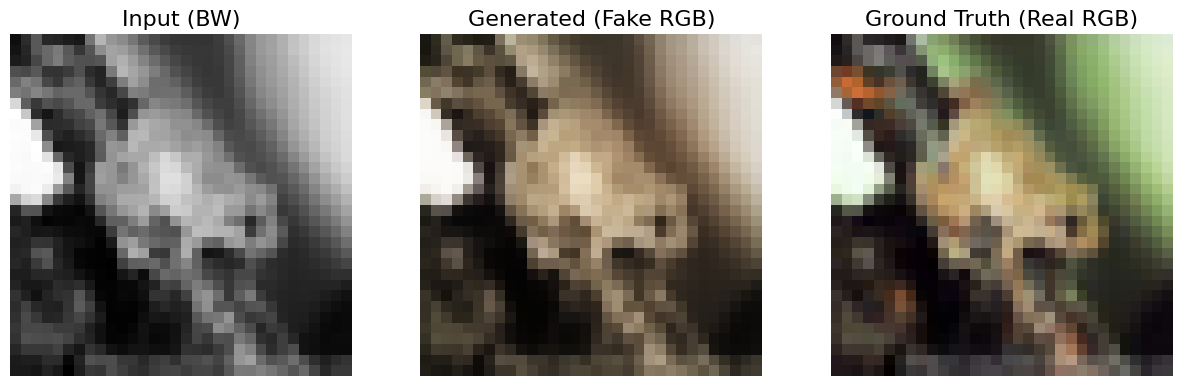

[Epoch 13/20] [Batch 100/391] [G loss: 0.0817] 
[Epoch 13/20] [Batch 110/391] [G loss: 0.0816] 
[Epoch 13/20] [Batch 120/391] [G loss: 0.0816] 
[Epoch 13/20] [Batch 130/391] [G loss: 0.0816] 
[Epoch 13/20] [Batch 140/391] [G loss: 0.0816] 


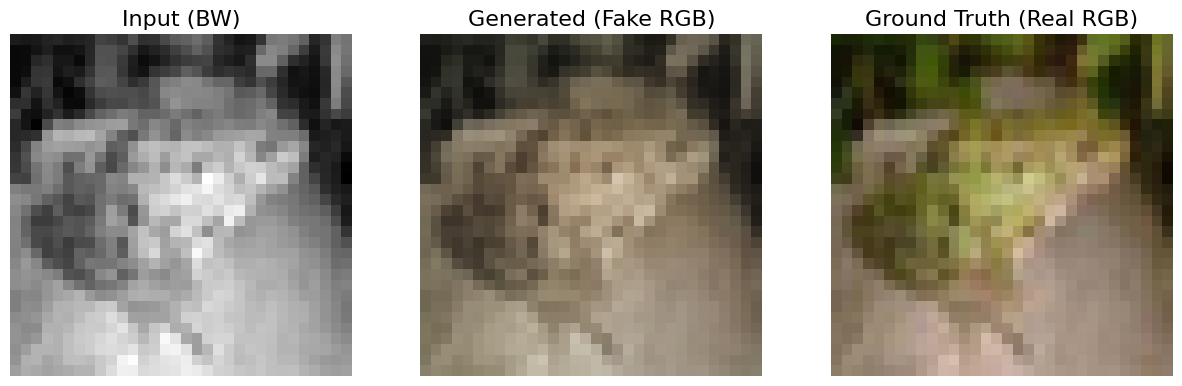

[Epoch 13/20] [Batch 150/391] [G loss: 0.0817] 
[Epoch 13/20] [Batch 160/391] [G loss: 0.0816] 
[Epoch 13/20] [Batch 170/391] [G loss: 0.0815] 
[Epoch 13/20] [Batch 180/391] [G loss: 0.0815] 
[Epoch 13/20] [Batch 190/391] [G loss: 0.0814] 


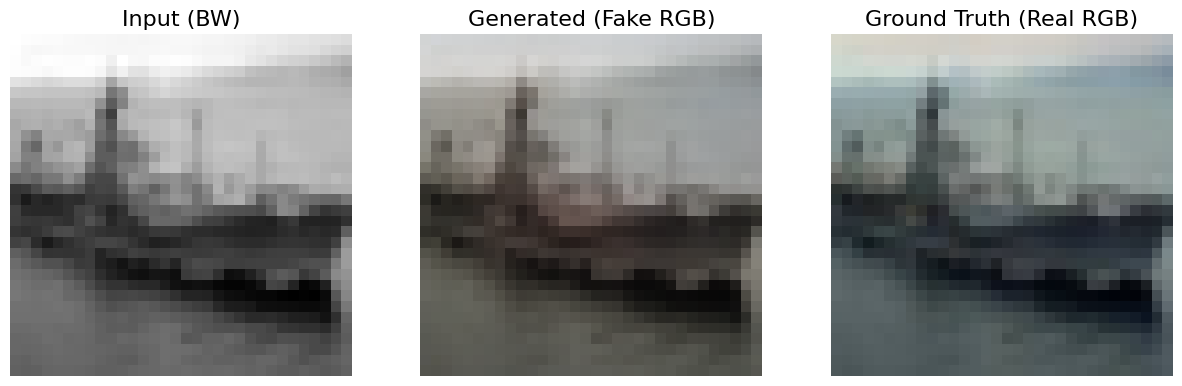

[Epoch 13/20] [Batch 200/391] [G loss: 0.0815] 
[Epoch 13/20] [Batch 210/391] [G loss: 0.0816] 
[Epoch 13/20] [Batch 220/391] [G loss: 0.0815] 
[Epoch 13/20] [Batch 230/391] [G loss: 0.0816] 
[Epoch 13/20] [Batch 240/391] [G loss: 0.0816] 


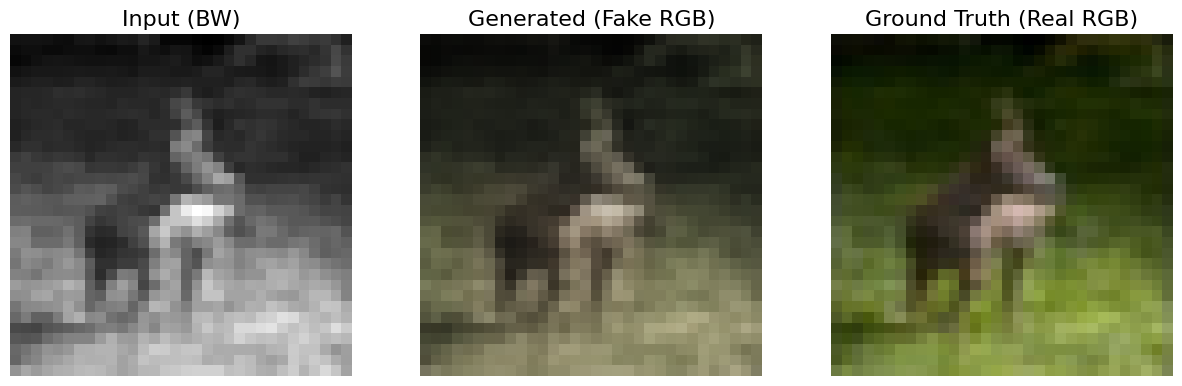

[Epoch 13/20] [Batch 250/391] [G loss: 0.0816] 
[Epoch 13/20] [Batch 260/391] [G loss: 0.0817] 
[Epoch 13/20] [Batch 270/391] [G loss: 0.0816] 
[Epoch 13/20] [Batch 280/391] [G loss: 0.0816] 
[Epoch 13/20] [Batch 290/391] [G loss: 0.0816] 


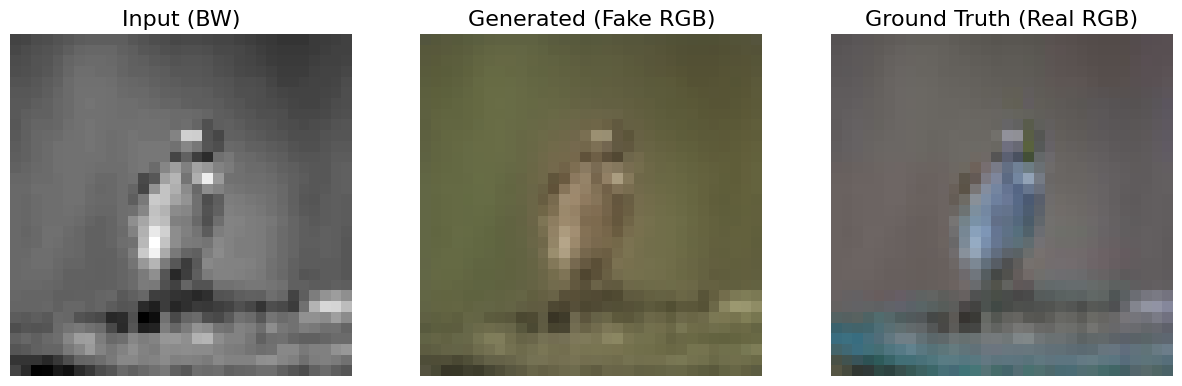

[Epoch 13/20] [Batch 300/391] [G loss: 0.0817] 
[Epoch 13/20] [Batch 310/391] [G loss: 0.0817] 
[Epoch 13/20] [Batch 320/391] [G loss: 0.0818] 
[Epoch 13/20] [Batch 330/391] [G loss: 0.0818] 
[Epoch 13/20] [Batch 340/391] [G loss: 0.0818] 


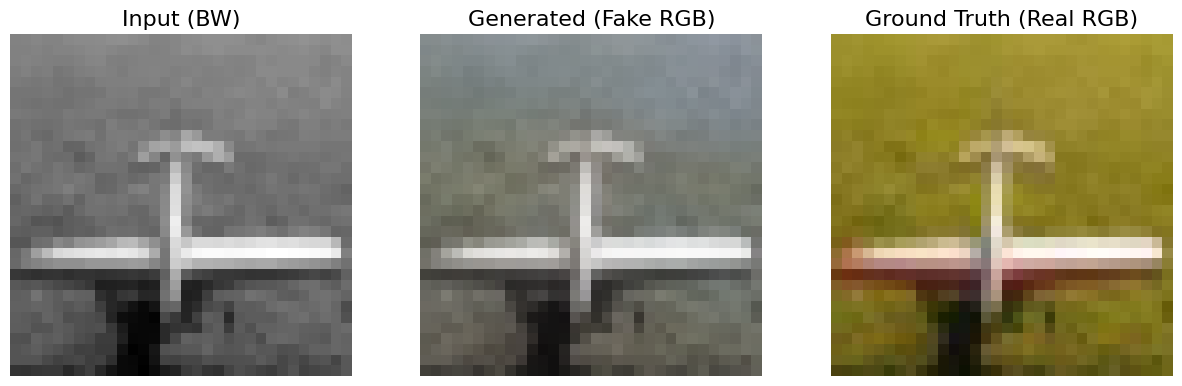

[Epoch 13/20] [Batch 350/391] [G loss: 0.0817] 
[Epoch 13/20] [Batch 360/391] [G loss: 0.0817] 
[Epoch 13/20] [Batch 370/391] [G loss: 0.0817] 
[Epoch 13/20] [Batch 380/391] [G loss: 0.0817] 
[Epoch 13/20] [Batch 390/391] [G loss: 0.0817] 


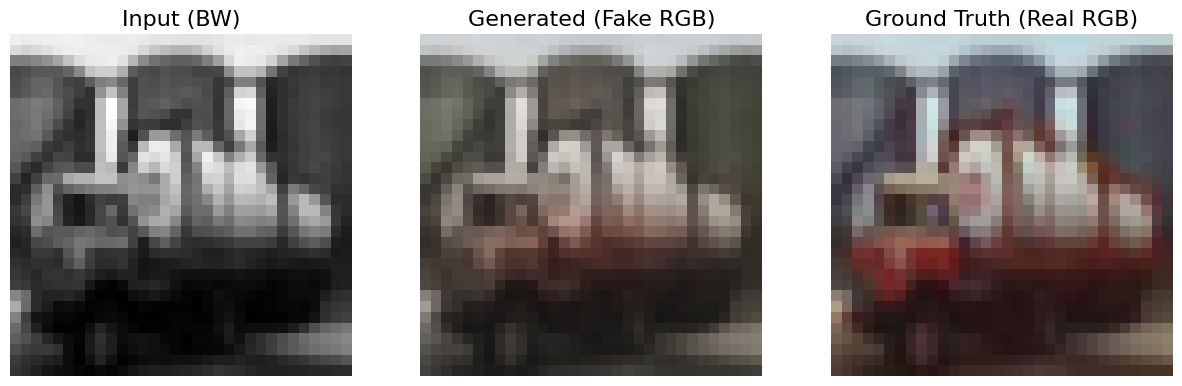

[Epoch 14/20] [Batch 0/391] [G loss: 0.0818] 
[Epoch 14/20] [Batch 10/391] [G loss: 0.0800] 
[Epoch 14/20] [Batch 20/391] [G loss: 0.0800] 
[Epoch 14/20] [Batch 30/391] [G loss: 0.0801] 
[Epoch 14/20] [Batch 40/391] [G loss: 0.0806] 


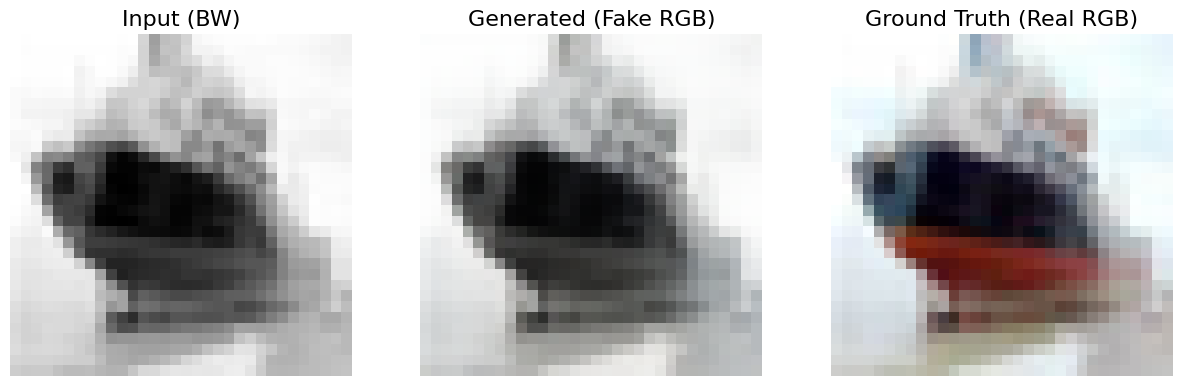

[Epoch 14/20] [Batch 50/391] [G loss: 0.0808] 
[Epoch 14/20] [Batch 60/391] [G loss: 0.0807] 
[Epoch 14/20] [Batch 70/391] [G loss: 0.0805] 
[Epoch 14/20] [Batch 80/391] [G loss: 0.0806] 
[Epoch 14/20] [Batch 90/391] [G loss: 0.0807] 


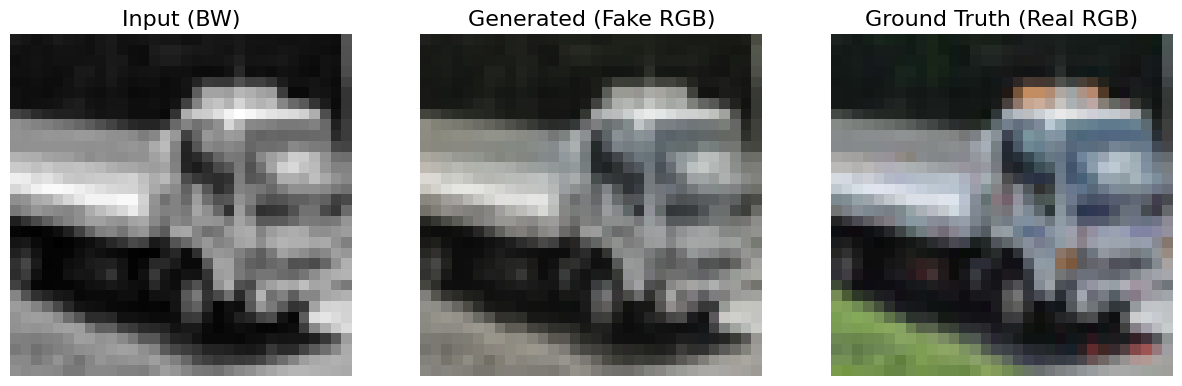

[Epoch 14/20] [Batch 100/391] [G loss: 0.0807] 
[Epoch 14/20] [Batch 110/391] [G loss: 0.0805] 
[Epoch 14/20] [Batch 120/391] [G loss: 0.0806] 
[Epoch 14/20] [Batch 130/391] [G loss: 0.0806] 
[Epoch 14/20] [Batch 140/391] [G loss: 0.0805] 


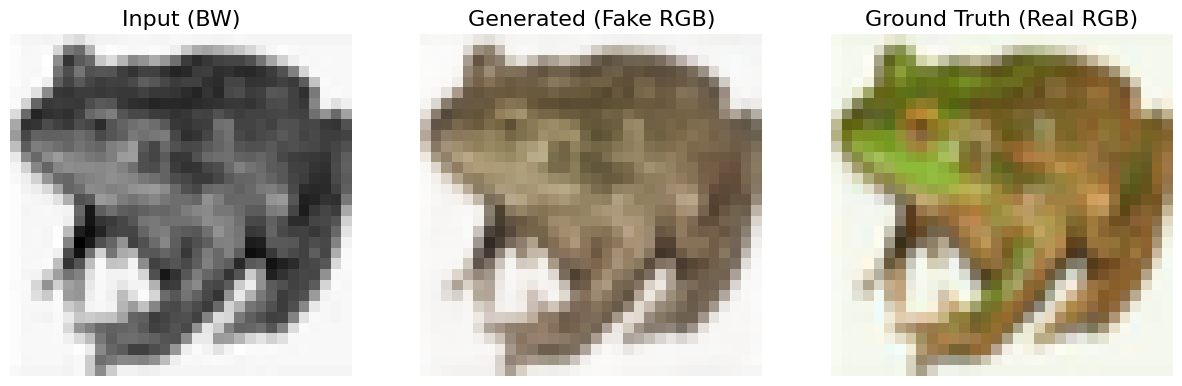

[Epoch 14/20] [Batch 150/391] [G loss: 0.0806] 
[Epoch 14/20] [Batch 160/391] [G loss: 0.0806] 
[Epoch 14/20] [Batch 170/391] [G loss: 0.0807] 
[Epoch 14/20] [Batch 180/391] [G loss: 0.0807] 
[Epoch 14/20] [Batch 190/391] [G loss: 0.0807] 


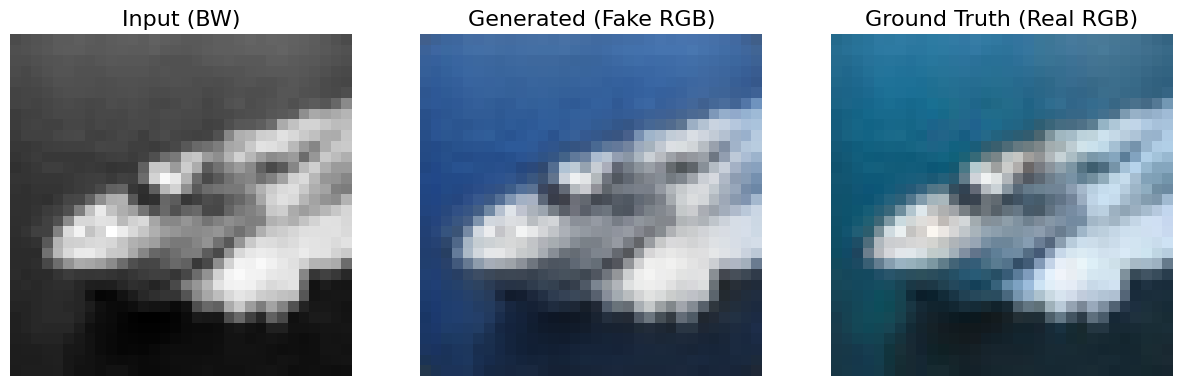

[Epoch 14/20] [Batch 200/391] [G loss: 0.0807] 
[Epoch 14/20] [Batch 210/391] [G loss: 0.0807] 
[Epoch 14/20] [Batch 220/391] [G loss: 0.0807] 
[Epoch 14/20] [Batch 230/391] [G loss: 0.0807] 
[Epoch 14/20] [Batch 240/391] [G loss: 0.0807] 


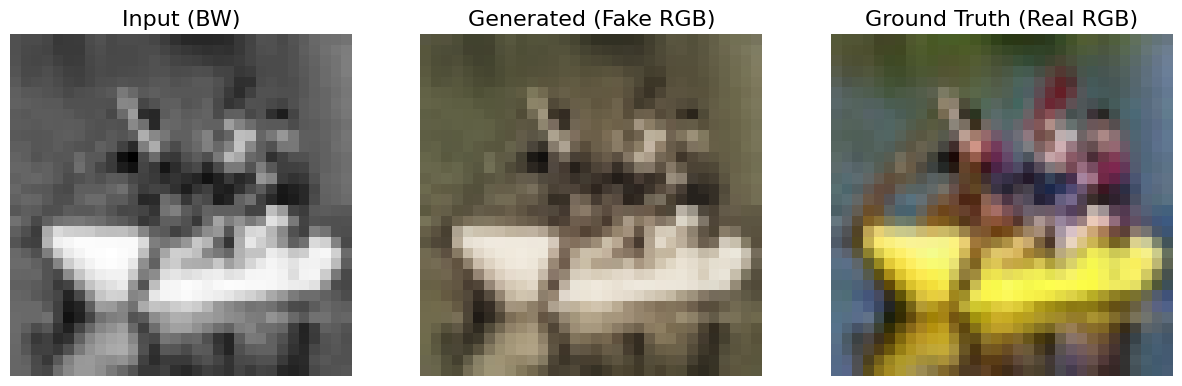

[Epoch 14/20] [Batch 250/391] [G loss: 0.0807] 
[Epoch 14/20] [Batch 260/391] [G loss: 0.0807] 
[Epoch 14/20] [Batch 270/391] [G loss: 0.0807] 
[Epoch 14/20] [Batch 280/391] [G loss: 0.0807] 
[Epoch 14/20] [Batch 290/391] [G loss: 0.0807] 


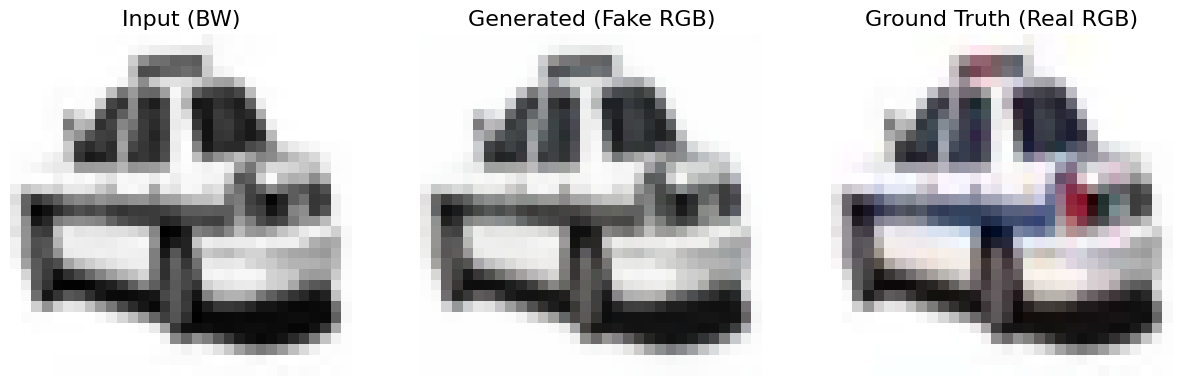

[Epoch 14/20] [Batch 300/391] [G loss: 0.0807] 
[Epoch 14/20] [Batch 310/391] [G loss: 0.0807] 
[Epoch 14/20] [Batch 320/391] [G loss: 0.0807] 
[Epoch 14/20] [Batch 330/391] [G loss: 0.0806] 
[Epoch 14/20] [Batch 340/391] [G loss: 0.0806] 


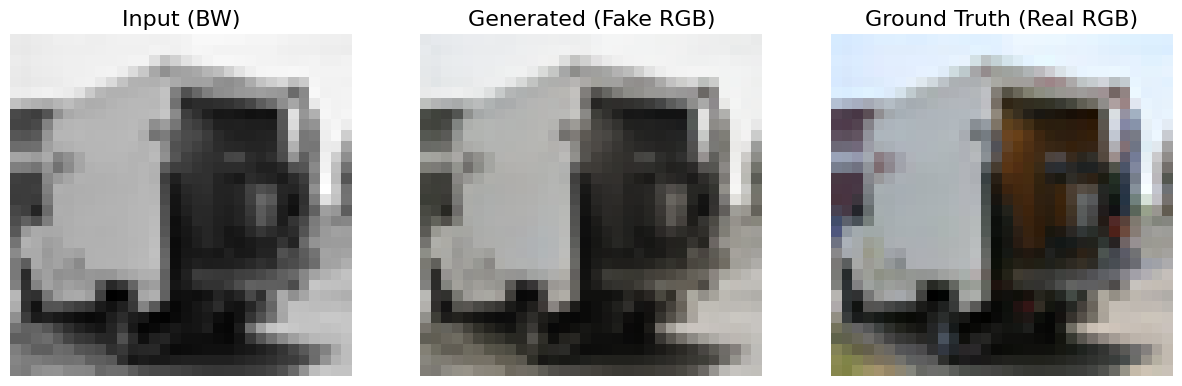

[Epoch 14/20] [Batch 350/391] [G loss: 0.0806] 
[Epoch 14/20] [Batch 360/391] [G loss: 0.0807] 
[Epoch 14/20] [Batch 370/391] [G loss: 0.0807] 
[Epoch 14/20] [Batch 380/391] [G loss: 0.0807] 
[Epoch 14/20] [Batch 390/391] [G loss: 0.0807] 


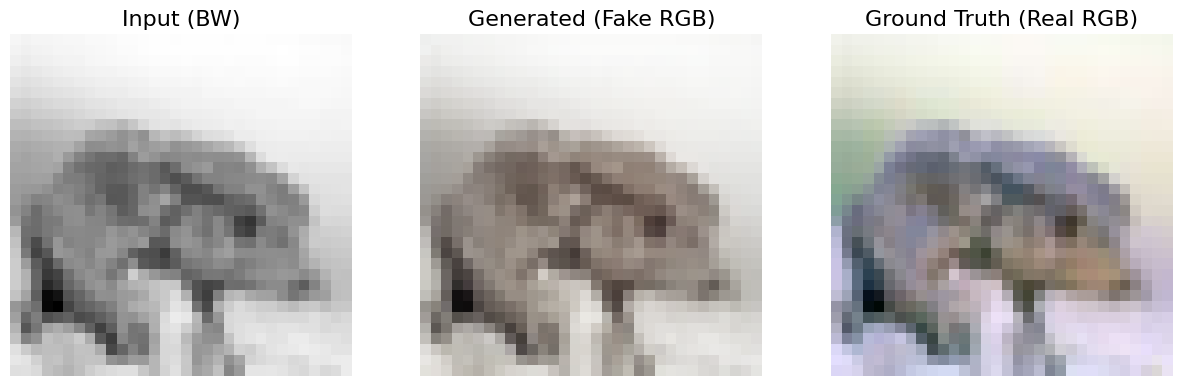

[Epoch 15/20] [Batch 0/391] [G loss: 0.0734] 
[Epoch 15/20] [Batch 10/391] [G loss: 0.0790] 
[Epoch 15/20] [Batch 20/391] [G loss: 0.0798] 
[Epoch 15/20] [Batch 30/391] [G loss: 0.0805] 
[Epoch 15/20] [Batch 40/391] [G loss: 0.0800] 


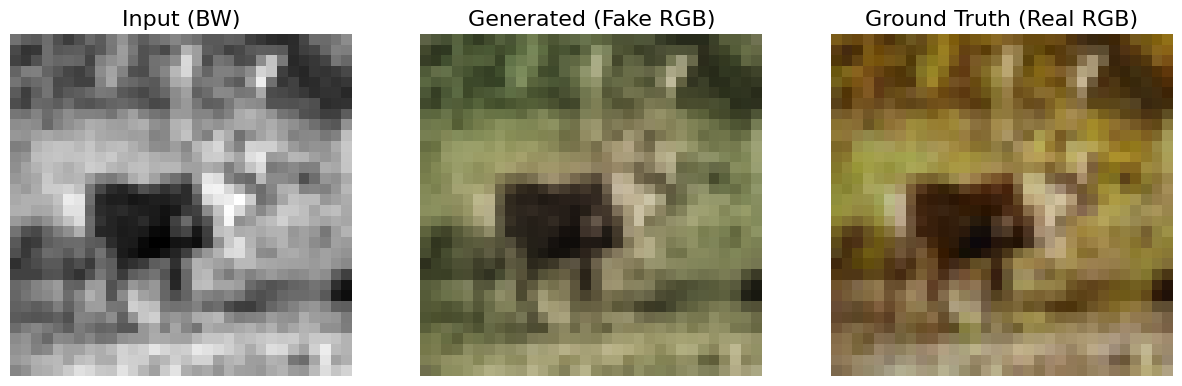

[Epoch 15/20] [Batch 50/391] [G loss: 0.0802] 
[Epoch 15/20] [Batch 60/391] [G loss: 0.0798] 
[Epoch 15/20] [Batch 70/391] [G loss: 0.0796] 
[Epoch 15/20] [Batch 80/391] [G loss: 0.0798] 
[Epoch 15/20] [Batch 90/391] [G loss: 0.0798] 


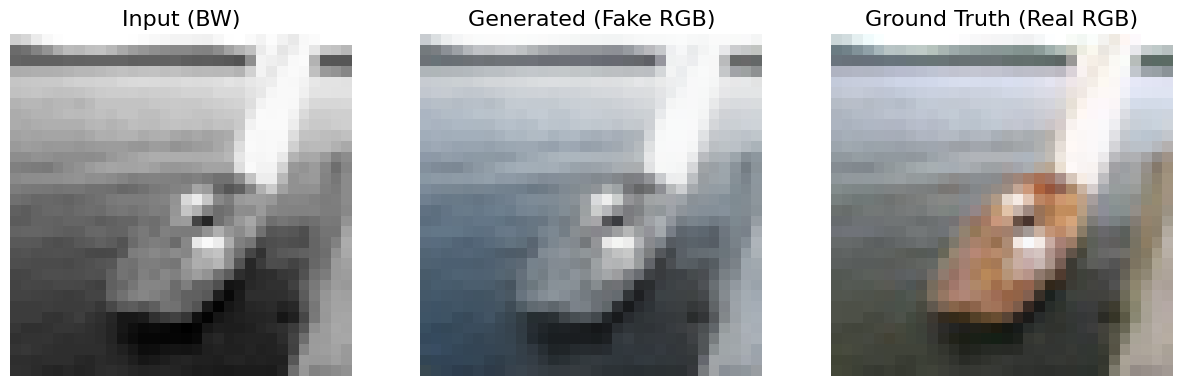

[Epoch 15/20] [Batch 100/391] [G loss: 0.0797] 
[Epoch 15/20] [Batch 110/391] [G loss: 0.0798] 
[Epoch 15/20] [Batch 120/391] [G loss: 0.0798] 
[Epoch 15/20] [Batch 130/391] [G loss: 0.0797] 
[Epoch 15/20] [Batch 140/391] [G loss: 0.0797] 


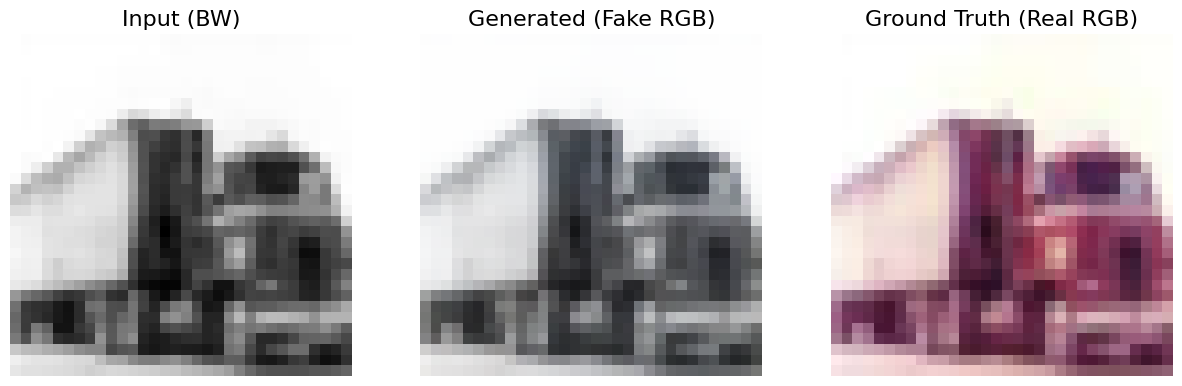

[Epoch 15/20] [Batch 150/391] [G loss: 0.0797] 
[Epoch 15/20] [Batch 160/391] [G loss: 0.0795] 
[Epoch 15/20] [Batch 170/391] [G loss: 0.0794] 
[Epoch 15/20] [Batch 180/391] [G loss: 0.0795] 
[Epoch 15/20] [Batch 190/391] [G loss: 0.0795] 


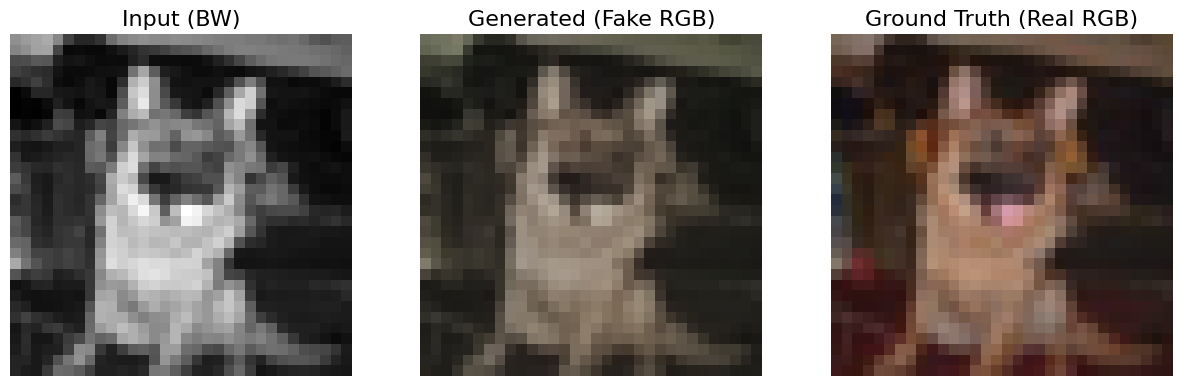

[Epoch 15/20] [Batch 200/391] [G loss: 0.0795] 
[Epoch 15/20] [Batch 210/391] [G loss: 0.0796] 
[Epoch 15/20] [Batch 220/391] [G loss: 0.0796] 
[Epoch 15/20] [Batch 230/391] [G loss: 0.0796] 
[Epoch 15/20] [Batch 240/391] [G loss: 0.0796] 


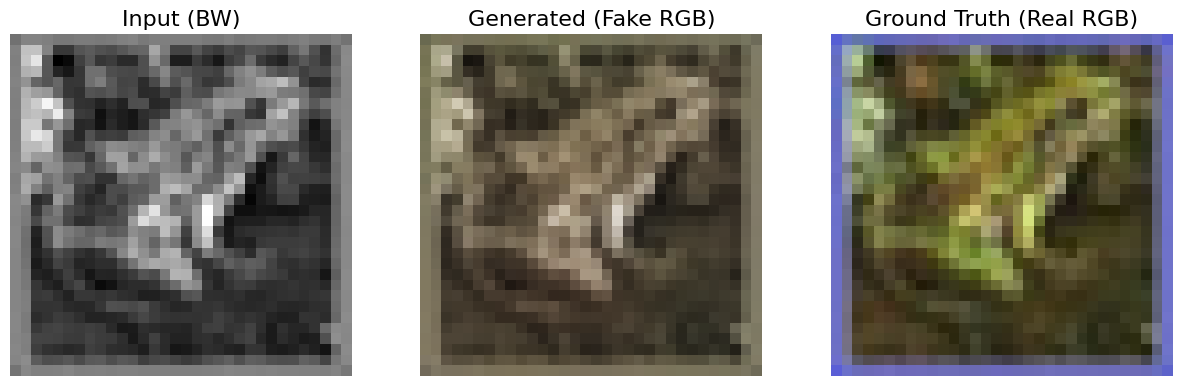

[Epoch 15/20] [Batch 250/391] [G loss: 0.0796] 
[Epoch 15/20] [Batch 260/391] [G loss: 0.0796] 
[Epoch 15/20] [Batch 270/391] [G loss: 0.0795] 
[Epoch 15/20] [Batch 280/391] [G loss: 0.0796] 
[Epoch 15/20] [Batch 290/391] [G loss: 0.0797] 


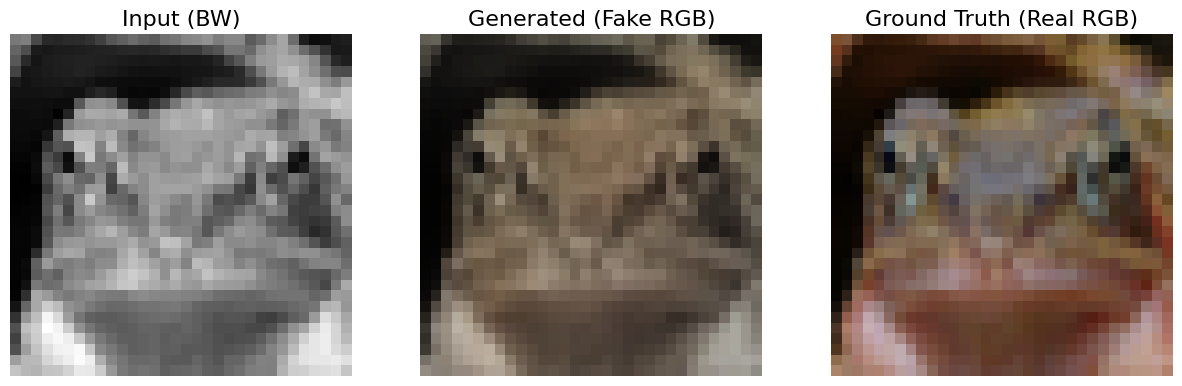

[Epoch 15/20] [Batch 300/391] [G loss: 0.0795] 
[Epoch 15/20] [Batch 310/391] [G loss: 0.0795] 
[Epoch 15/20] [Batch 320/391] [G loss: 0.0796] 
[Epoch 15/20] [Batch 330/391] [G loss: 0.0796] 
[Epoch 15/20] [Batch 340/391] [G loss: 0.0796] 


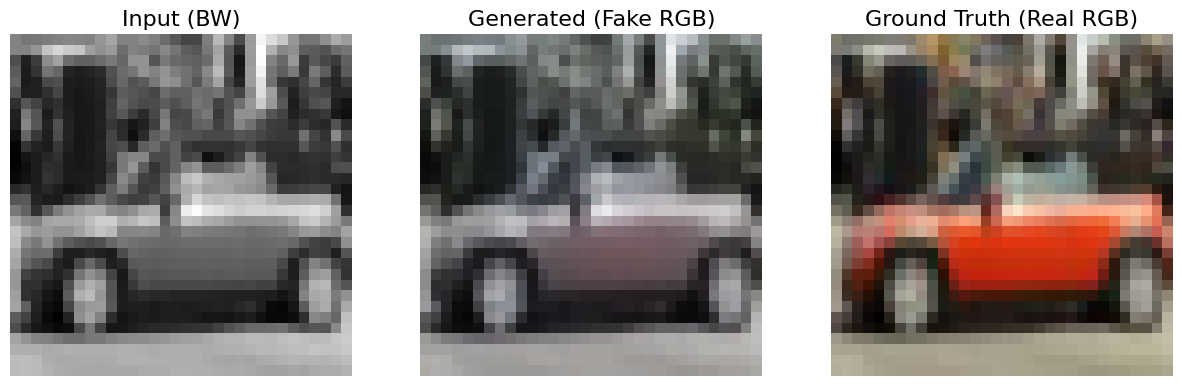

[Epoch 15/20] [Batch 350/391] [G loss: 0.0796] 
[Epoch 15/20] [Batch 360/391] [G loss: 0.0795] 
[Epoch 15/20] [Batch 370/391] [G loss: 0.0795] 
[Epoch 15/20] [Batch 380/391] [G loss: 0.0795] 
[Epoch 15/20] [Batch 390/391] [G loss: 0.0795] 


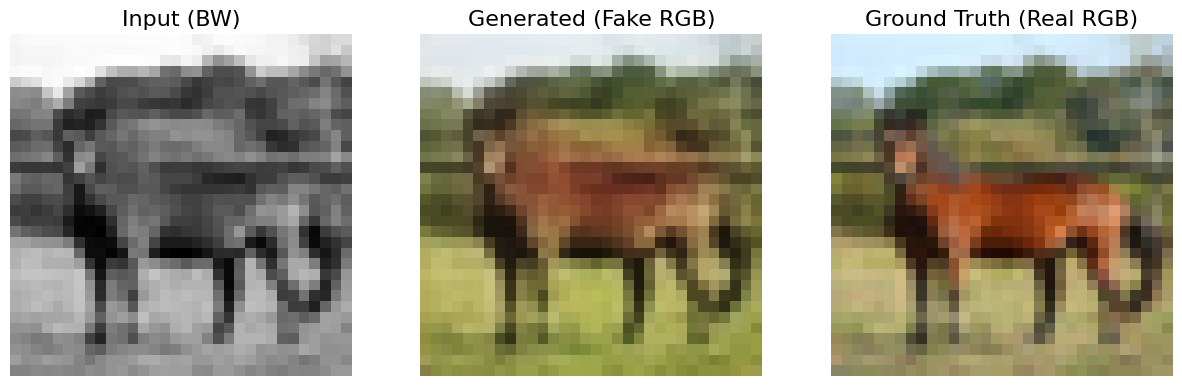

[Epoch 16/20] [Batch 0/391] [G loss: 0.0809] 
[Epoch 16/20] [Batch 10/391] [G loss: 0.0780] 
[Epoch 16/20] [Batch 20/391] [G loss: 0.0790] 
[Epoch 16/20] [Batch 30/391] [G loss: 0.0793] 
[Epoch 16/20] [Batch 40/391] [G loss: 0.0788] 


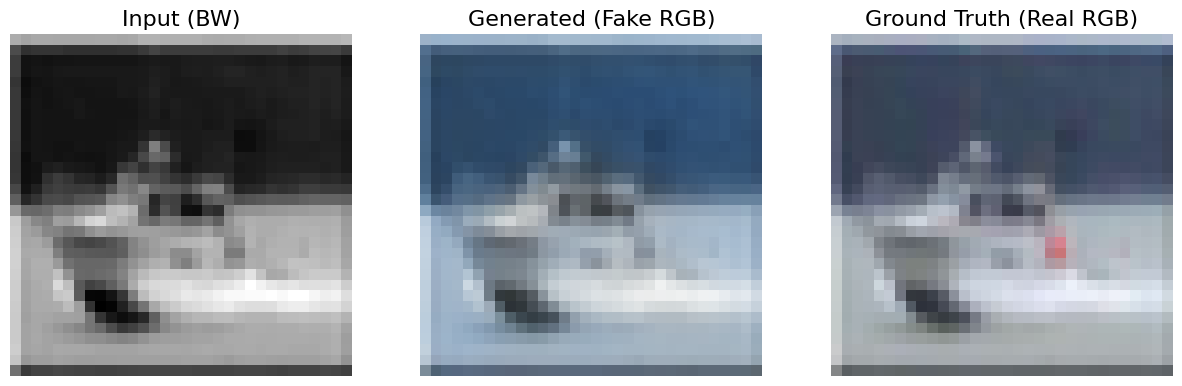

[Epoch 16/20] [Batch 50/391] [G loss: 0.0789] 
[Epoch 16/20] [Batch 60/391] [G loss: 0.0789] 
[Epoch 16/20] [Batch 70/391] [G loss: 0.0789] 
[Epoch 16/20] [Batch 80/391] [G loss: 0.0786] 
[Epoch 16/20] [Batch 90/391] [G loss: 0.0784] 


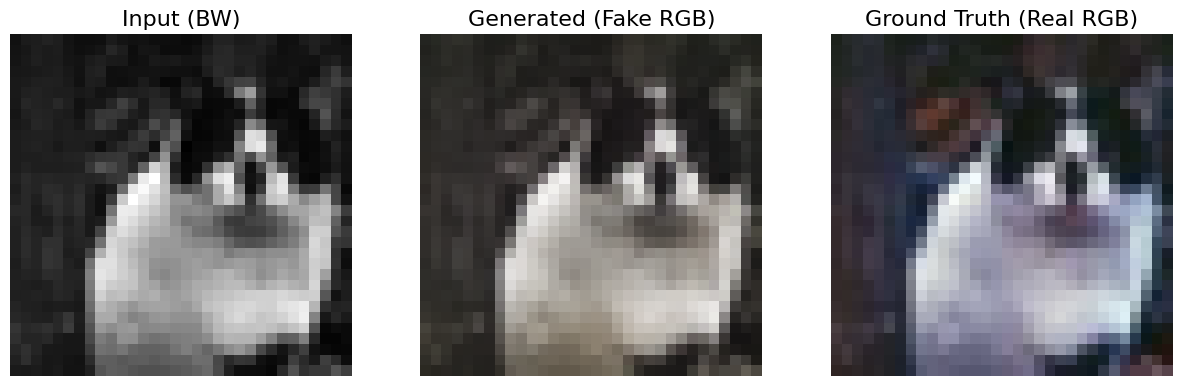

[Epoch 16/20] [Batch 100/391] [G loss: 0.0784] 
[Epoch 16/20] [Batch 110/391] [G loss: 0.0783] 
[Epoch 16/20] [Batch 120/391] [G loss: 0.0783] 
[Epoch 16/20] [Batch 130/391] [G loss: 0.0783] 
[Epoch 16/20] [Batch 140/391] [G loss: 0.0783] 


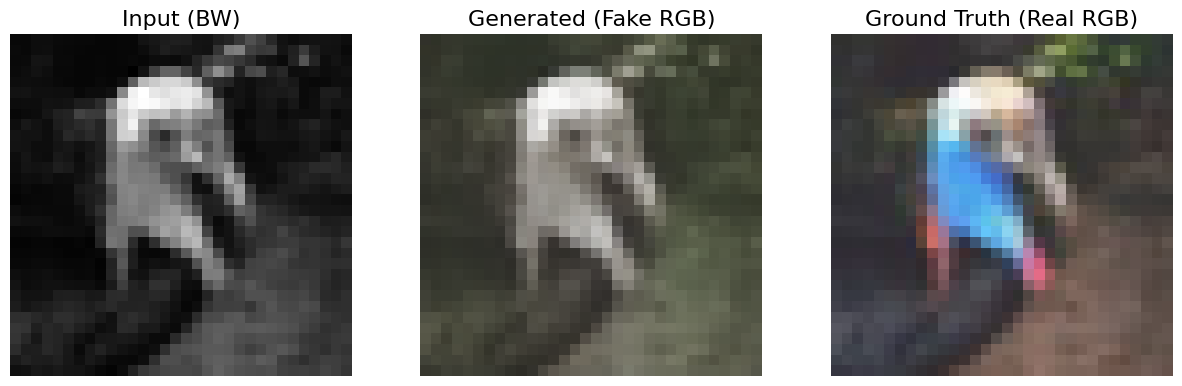

[Epoch 16/20] [Batch 150/391] [G loss: 0.0782] 
[Epoch 16/20] [Batch 160/391] [G loss: 0.0783] 
[Epoch 16/20] [Batch 170/391] [G loss: 0.0784] 
[Epoch 16/20] [Batch 180/391] [G loss: 0.0784] 
[Epoch 16/20] [Batch 190/391] [G loss: 0.0785] 


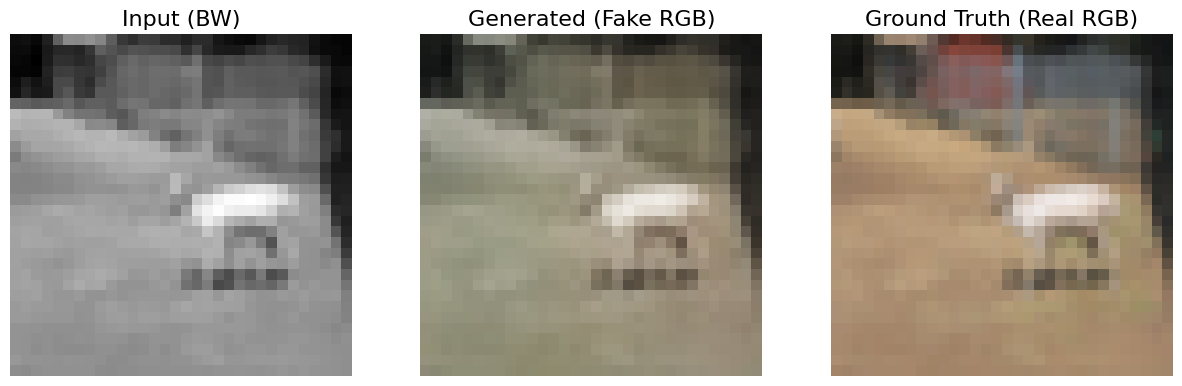

[Epoch 16/20] [Batch 200/391] [G loss: 0.0785] 
[Epoch 16/20] [Batch 210/391] [G loss: 0.0784] 
[Epoch 16/20] [Batch 220/391] [G loss: 0.0785] 
[Epoch 16/20] [Batch 230/391] [G loss: 0.0784] 
[Epoch 16/20] [Batch 240/391] [G loss: 0.0784] 


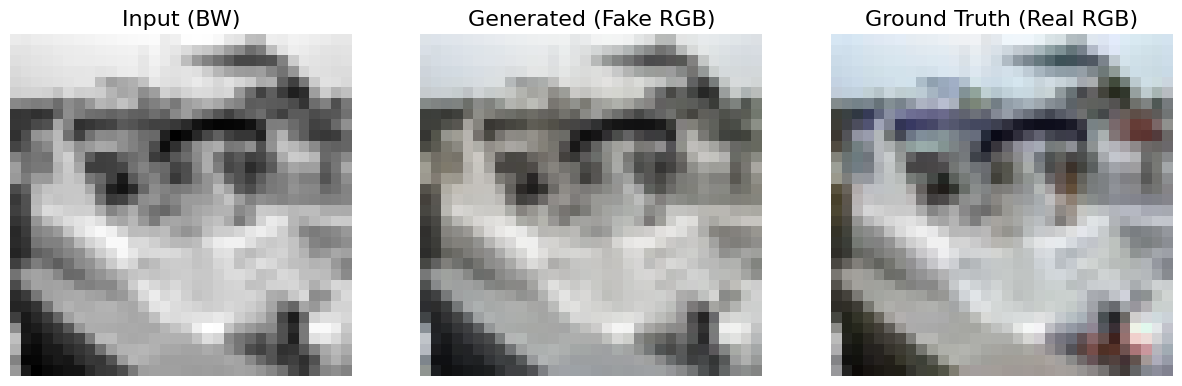

[Epoch 16/20] [Batch 250/391] [G loss: 0.0784] 
[Epoch 16/20] [Batch 260/391] [G loss: 0.0785] 
[Epoch 16/20] [Batch 270/391] [G loss: 0.0785] 
[Epoch 16/20] [Batch 280/391] [G loss: 0.0784] 
[Epoch 16/20] [Batch 290/391] [G loss: 0.0785] 


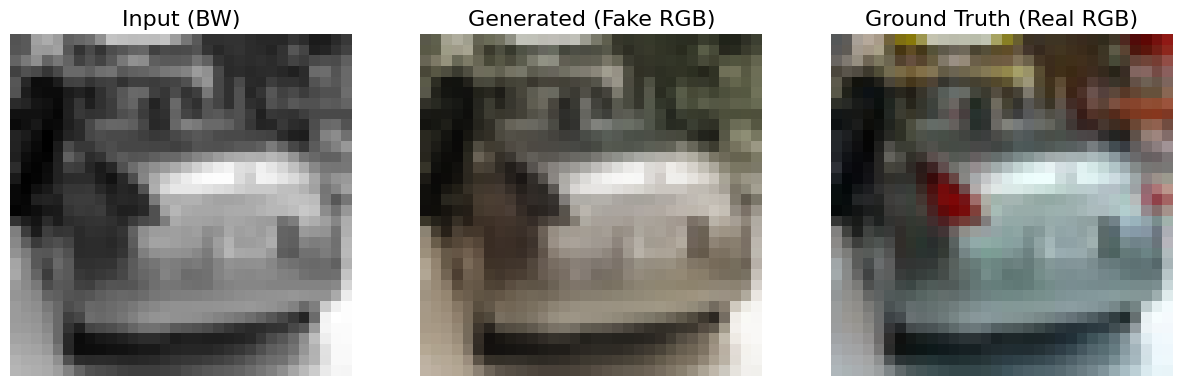

[Epoch 16/20] [Batch 300/391] [G loss: 0.0785] 
[Epoch 16/20] [Batch 310/391] [G loss: 0.0786] 
[Epoch 16/20] [Batch 320/391] [G loss: 0.0786] 
[Epoch 16/20] [Batch 330/391] [G loss: 0.0785] 
[Epoch 16/20] [Batch 340/391] [G loss: 0.0785] 


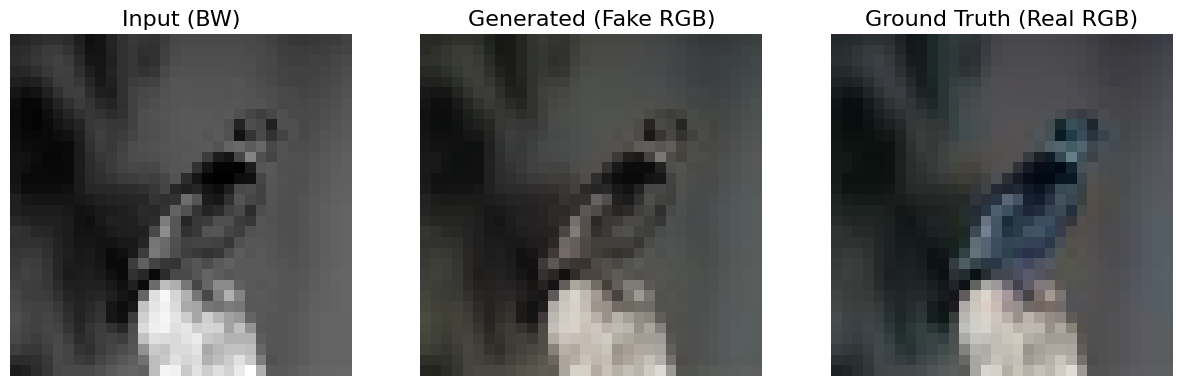

[Epoch 16/20] [Batch 350/391] [G loss: 0.0785] 
[Epoch 16/20] [Batch 360/391] [G loss: 0.0784] 
[Epoch 16/20] [Batch 370/391] [G loss: 0.0784] 
[Epoch 16/20] [Batch 380/391] [G loss: 0.0784] 
[Epoch 16/20] [Batch 390/391] [G loss: 0.0784] 


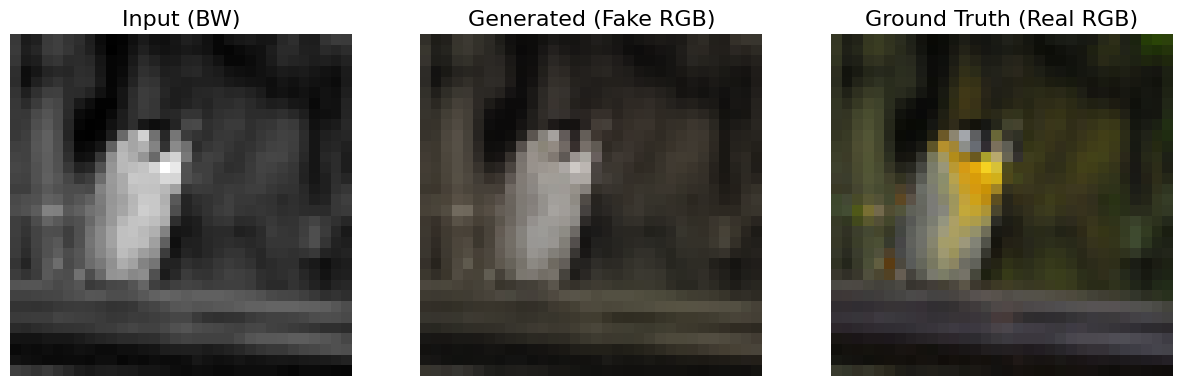

[Epoch 17/20] [Batch 0/391] [G loss: 0.0743] 
[Epoch 17/20] [Batch 10/391] [G loss: 0.0759] 
[Epoch 17/20] [Batch 20/391] [G loss: 0.0767] 
[Epoch 17/20] [Batch 30/391] [G loss: 0.0776] 
[Epoch 17/20] [Batch 40/391] [G loss: 0.0776] 


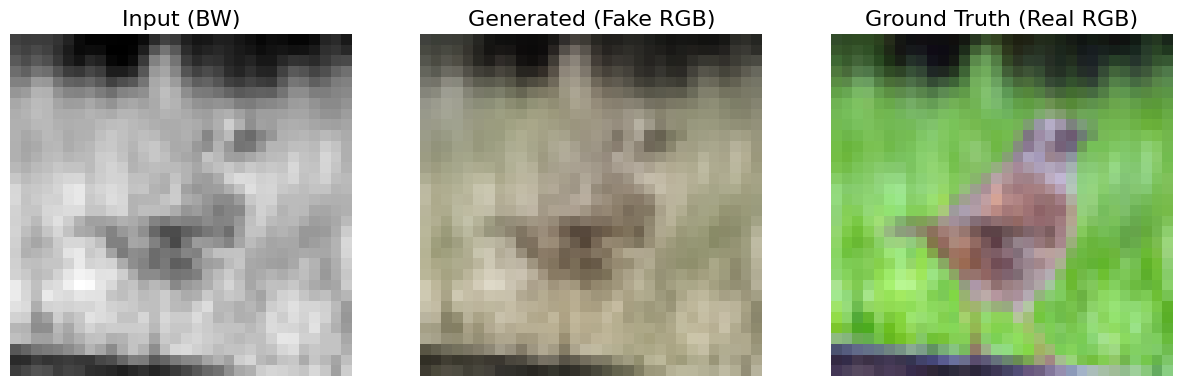

[Epoch 17/20] [Batch 50/391] [G loss: 0.0770] 
[Epoch 17/20] [Batch 60/391] [G loss: 0.0770] 
[Epoch 17/20] [Batch 70/391] [G loss: 0.0769] 
[Epoch 17/20] [Batch 80/391] [G loss: 0.0769] 
[Epoch 17/20] [Batch 90/391] [G loss: 0.0769] 


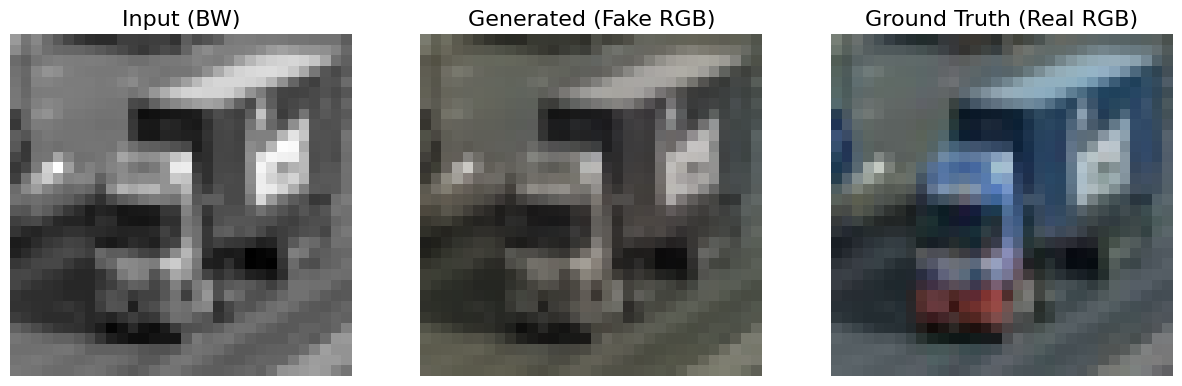

[Epoch 17/20] [Batch 100/391] [G loss: 0.0771] 
[Epoch 17/20] [Batch 110/391] [G loss: 0.0772] 
[Epoch 17/20] [Batch 120/391] [G loss: 0.0771] 
[Epoch 17/20] [Batch 130/391] [G loss: 0.0773] 
[Epoch 17/20] [Batch 140/391] [G loss: 0.0773] 


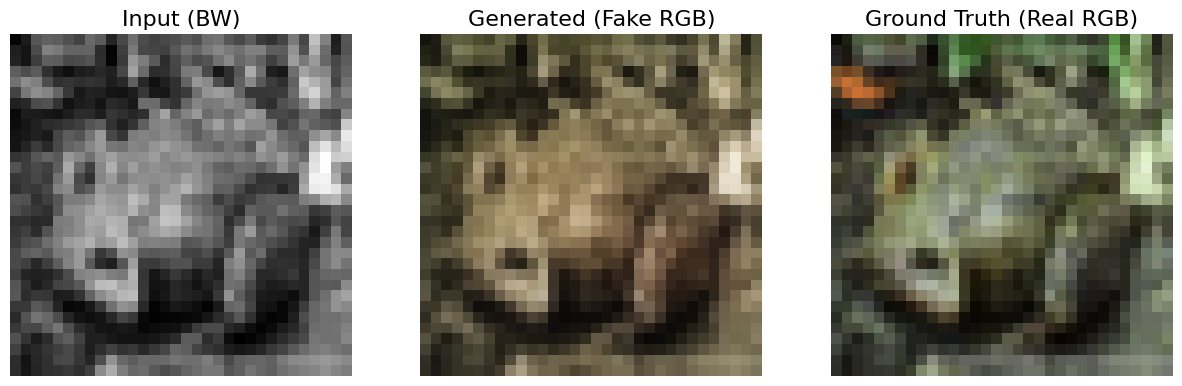

[Epoch 17/20] [Batch 150/391] [G loss: 0.0773] 
[Epoch 17/20] [Batch 160/391] [G loss: 0.0773] 
[Epoch 17/20] [Batch 170/391] [G loss: 0.0774] 
[Epoch 17/20] [Batch 180/391] [G loss: 0.0775] 
[Epoch 17/20] [Batch 190/391] [G loss: 0.0774] 


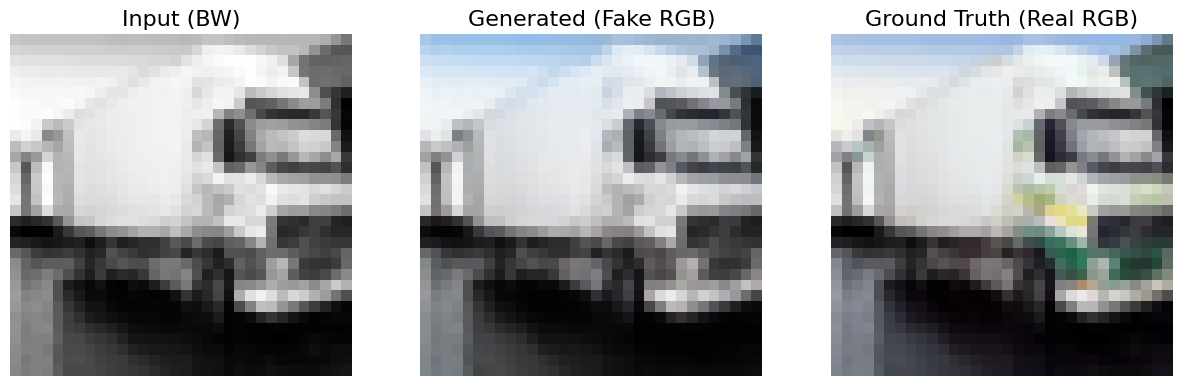

[Epoch 17/20] [Batch 200/391] [G loss: 0.0774] 
[Epoch 17/20] [Batch 210/391] [G loss: 0.0774] 
[Epoch 17/20] [Batch 220/391] [G loss: 0.0773] 
[Epoch 17/20] [Batch 230/391] [G loss: 0.0773] 
[Epoch 17/20] [Batch 240/391] [G loss: 0.0772] 


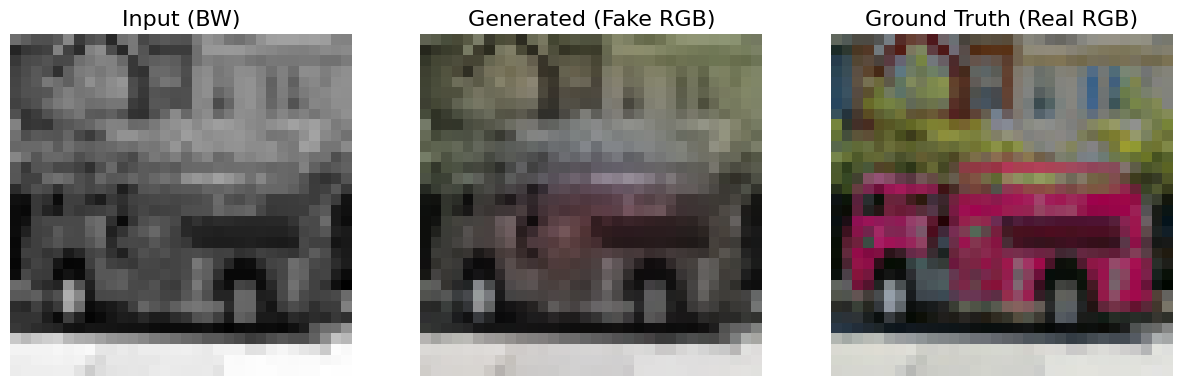

[Epoch 17/20] [Batch 250/391] [G loss: 0.0773] 
[Epoch 17/20] [Batch 260/391] [G loss: 0.0773] 
[Epoch 17/20] [Batch 270/391] [G loss: 0.0773] 
[Epoch 17/20] [Batch 280/391] [G loss: 0.0773] 
[Epoch 17/20] [Batch 290/391] [G loss: 0.0772] 


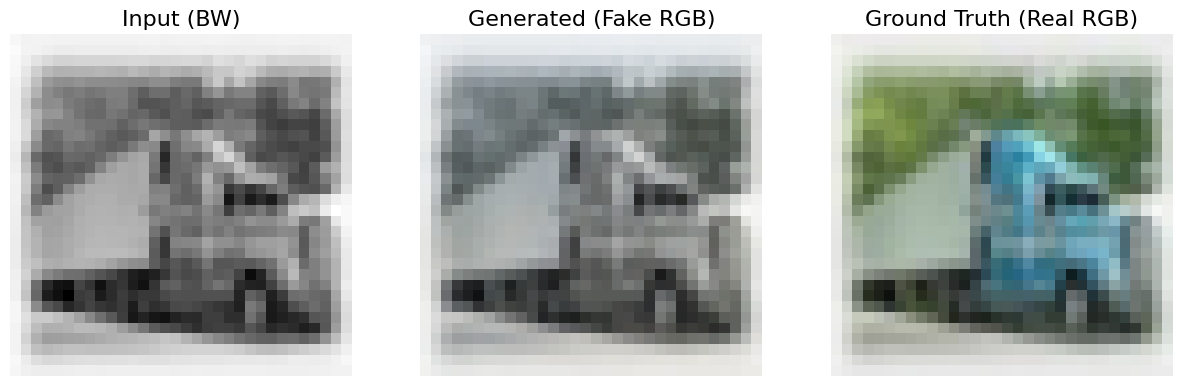

[Epoch 17/20] [Batch 300/391] [G loss: 0.0772] 
[Epoch 17/20] [Batch 310/391] [G loss: 0.0772] 
[Epoch 17/20] [Batch 320/391] [G loss: 0.0771] 
[Epoch 17/20] [Batch 330/391] [G loss: 0.0771] 
[Epoch 17/20] [Batch 340/391] [G loss: 0.0771] 


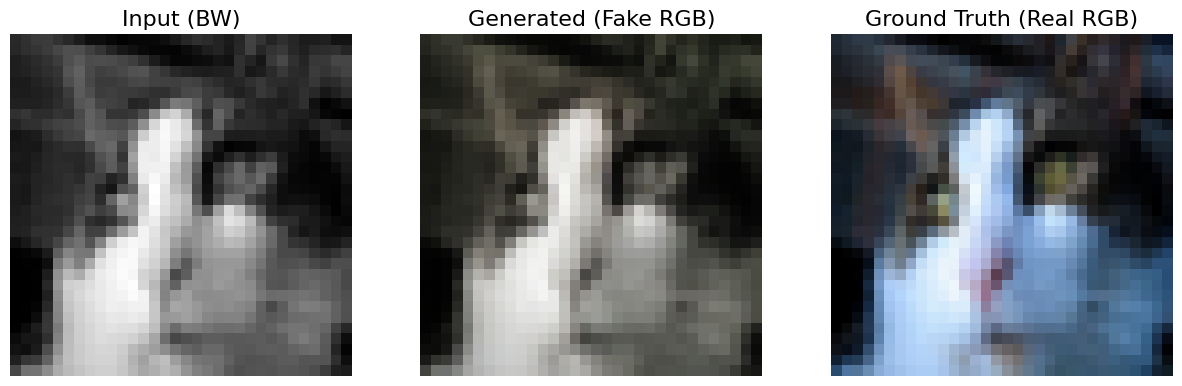

[Epoch 17/20] [Batch 350/391] [G loss: 0.0771] 
[Epoch 17/20] [Batch 360/391] [G loss: 0.0771] 
[Epoch 17/20] [Batch 370/391] [G loss: 0.0771] 
[Epoch 17/20] [Batch 380/391] [G loss: 0.0770] 
[Epoch 17/20] [Batch 390/391] [G loss: 0.0771] 


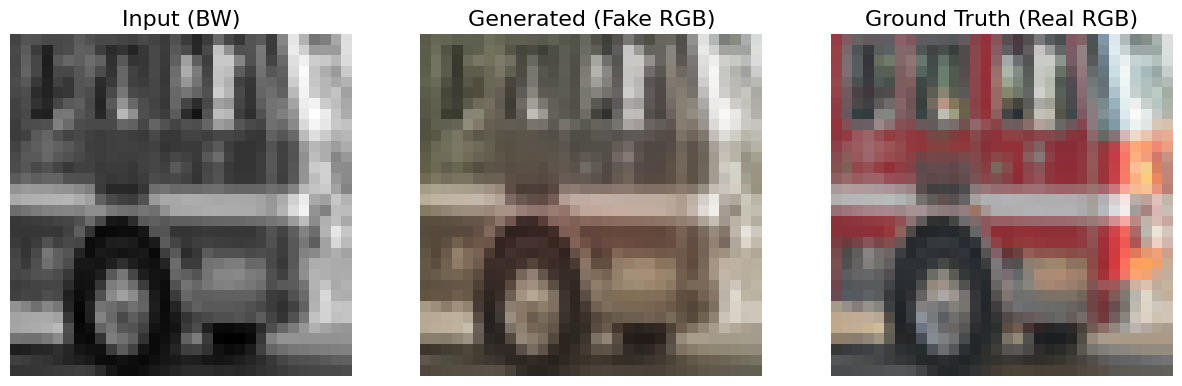

[Epoch 18/20] [Batch 0/391] [G loss: 0.0786] 
[Epoch 18/20] [Batch 10/391] [G loss: 0.0762] 
[Epoch 18/20] [Batch 20/391] [G loss: 0.0759] 
[Epoch 18/20] [Batch 30/391] [G loss: 0.0752] 
[Epoch 18/20] [Batch 40/391] [G loss: 0.0752] 


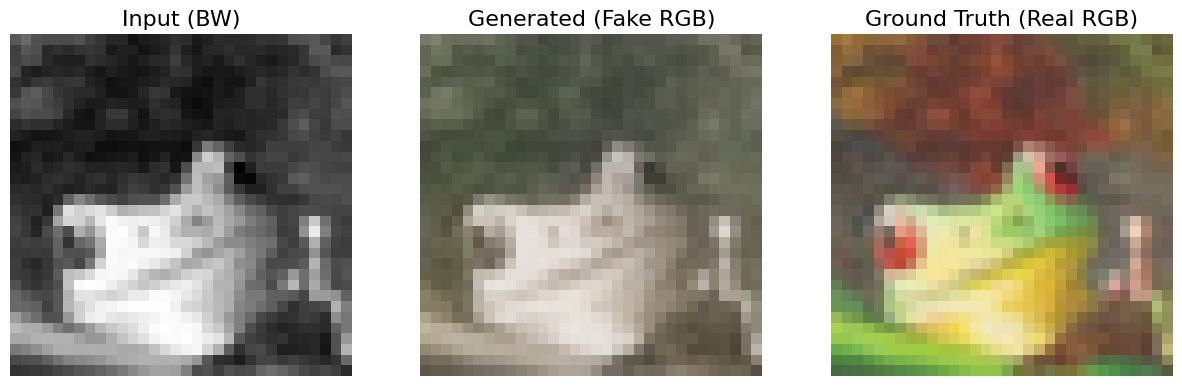

[Epoch 18/20] [Batch 50/391] [G loss: 0.0750] 
[Epoch 18/20] [Batch 60/391] [G loss: 0.0749] 
[Epoch 18/20] [Batch 70/391] [G loss: 0.0747] 
[Epoch 18/20] [Batch 80/391] [G loss: 0.0747] 
[Epoch 18/20] [Batch 90/391] [G loss: 0.0749] 


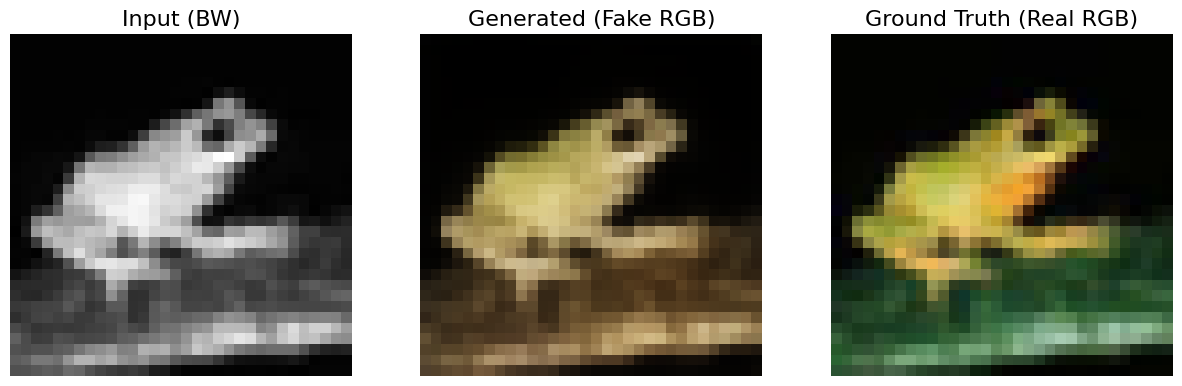

[Epoch 18/20] [Batch 100/391] [G loss: 0.0749] 
[Epoch 18/20] [Batch 110/391] [G loss: 0.0753] 
[Epoch 18/20] [Batch 120/391] [G loss: 0.0753] 
[Epoch 18/20] [Batch 130/391] [G loss: 0.0754] 
[Epoch 18/20] [Batch 140/391] [G loss: 0.0755] 


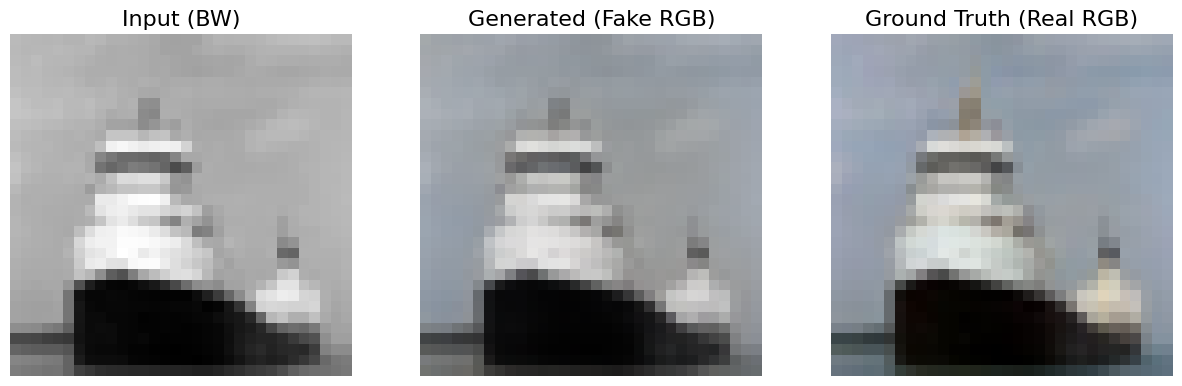

[Epoch 18/20] [Batch 150/391] [G loss: 0.0754] 
[Epoch 18/20] [Batch 160/391] [G loss: 0.0755] 
[Epoch 18/20] [Batch 170/391] [G loss: 0.0755] 
[Epoch 18/20] [Batch 180/391] [G loss: 0.0755] 
[Epoch 18/20] [Batch 190/391] [G loss: 0.0756] 


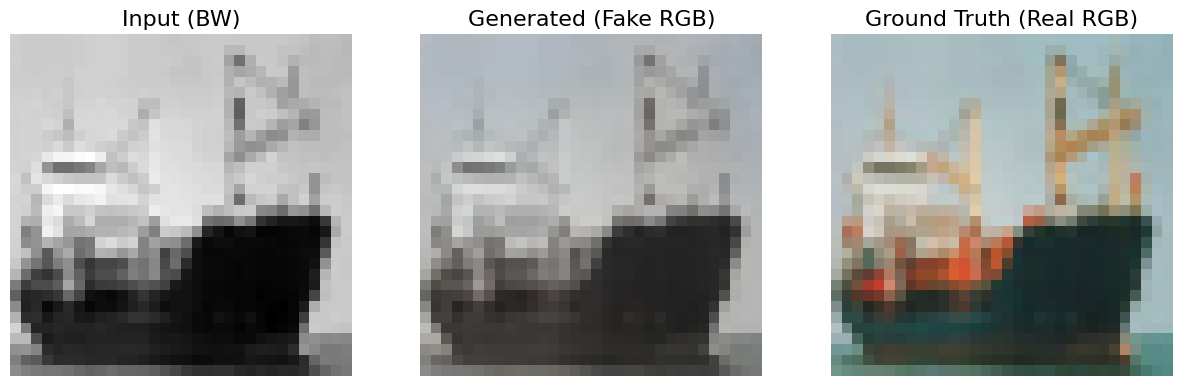

[Epoch 18/20] [Batch 200/391] [G loss: 0.0756] 
[Epoch 18/20] [Batch 210/391] [G loss: 0.0756] 
[Epoch 18/20] [Batch 220/391] [G loss: 0.0756] 
[Epoch 18/20] [Batch 230/391] [G loss: 0.0757] 
[Epoch 18/20] [Batch 240/391] [G loss: 0.0756] 


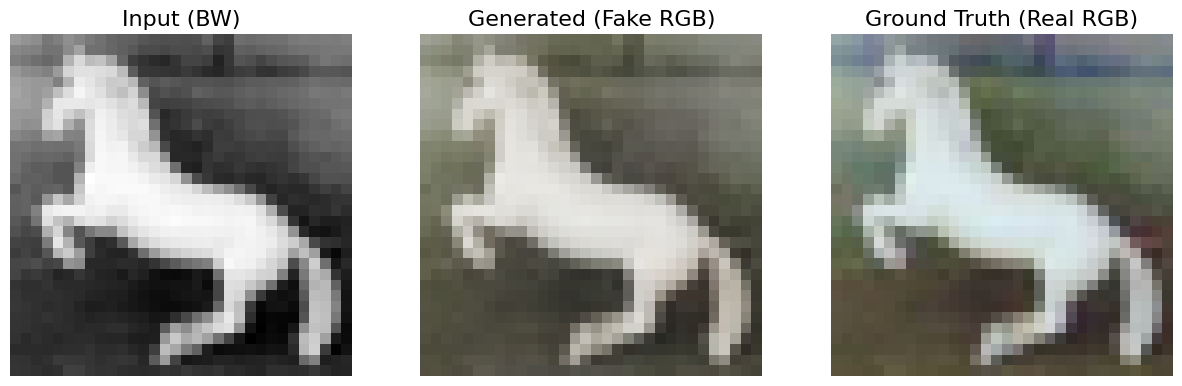

[Epoch 18/20] [Batch 250/391] [G loss: 0.0756] 
[Epoch 18/20] [Batch 260/391] [G loss: 0.0756] 
[Epoch 18/20] [Batch 270/391] [G loss: 0.0756] 
[Epoch 18/20] [Batch 280/391] [G loss: 0.0756] 
[Epoch 18/20] [Batch 290/391] [G loss: 0.0757] 


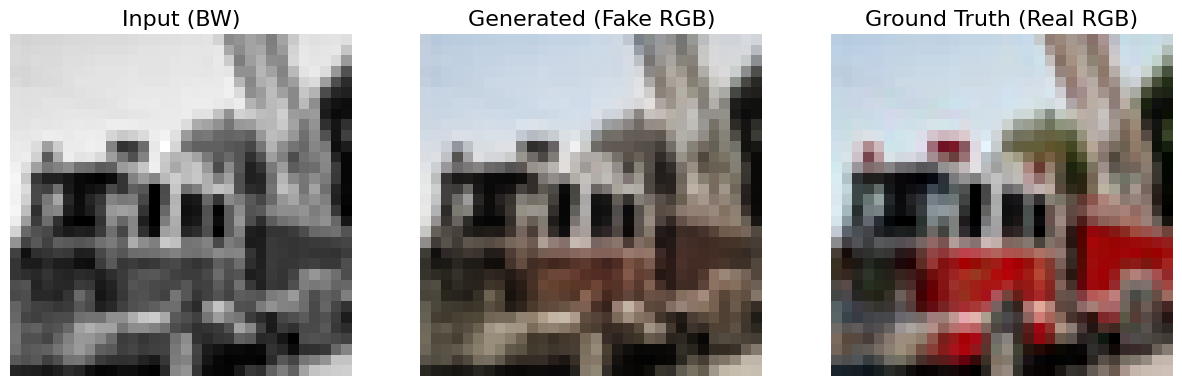

[Epoch 18/20] [Batch 300/391] [G loss: 0.0757] 
[Epoch 18/20] [Batch 310/391] [G loss: 0.0756] 
[Epoch 18/20] [Batch 320/391] [G loss: 0.0756] 
[Epoch 18/20] [Batch 330/391] [G loss: 0.0756] 
[Epoch 18/20] [Batch 340/391] [G loss: 0.0756] 


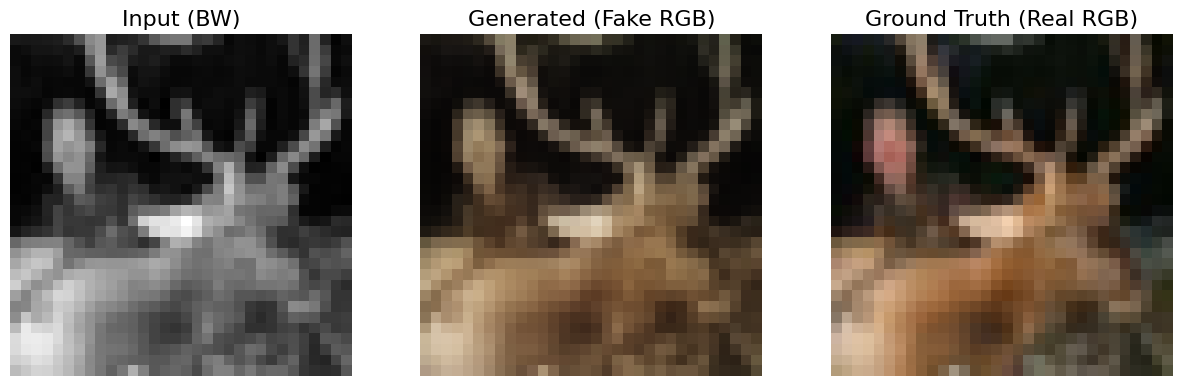

[Epoch 18/20] [Batch 350/391] [G loss: 0.0756] 
[Epoch 18/20] [Batch 360/391] [G loss: 0.0757] 
[Epoch 18/20] [Batch 370/391] [G loss: 0.0758] 
[Epoch 18/20] [Batch 380/391] [G loss: 0.0758] 
[Epoch 18/20] [Batch 390/391] [G loss: 0.0758] 


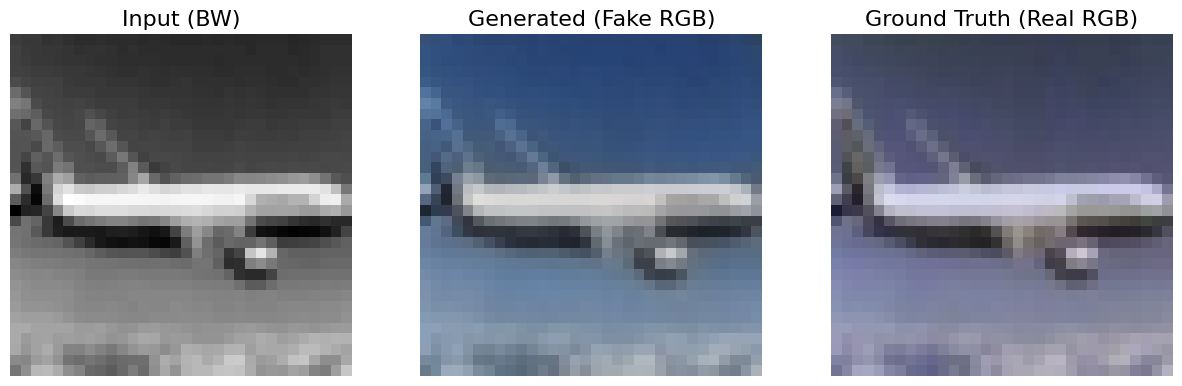

[Epoch 19/20] [Batch 0/391] [G loss: 0.0791] 
[Epoch 19/20] [Batch 10/391] [G loss: 0.0762] 
[Epoch 19/20] [Batch 20/391] [G loss: 0.0744] 
[Epoch 19/20] [Batch 30/391] [G loss: 0.0740] 
[Epoch 19/20] [Batch 40/391] [G loss: 0.0740] 


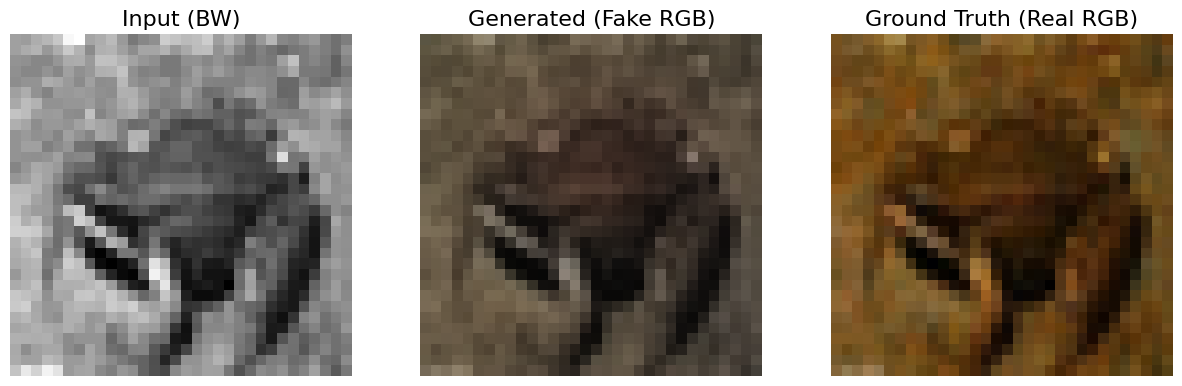

[Epoch 19/20] [Batch 50/391] [G loss: 0.0743] 
[Epoch 19/20] [Batch 60/391] [G loss: 0.0745] 
[Epoch 19/20] [Batch 70/391] [G loss: 0.0742] 
[Epoch 19/20] [Batch 80/391] [G loss: 0.0741] 
[Epoch 19/20] [Batch 90/391] [G loss: 0.0741] 


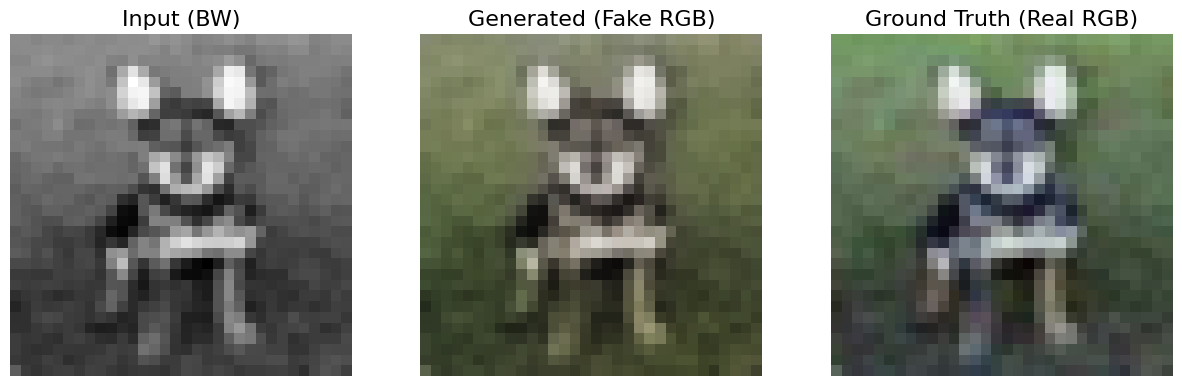

[Epoch 19/20] [Batch 100/391] [G loss: 0.0740] 
[Epoch 19/20] [Batch 110/391] [G loss: 0.0739] 
[Epoch 19/20] [Batch 120/391] [G loss: 0.0741] 
[Epoch 19/20] [Batch 130/391] [G loss: 0.0741] 
[Epoch 19/20] [Batch 140/391] [G loss: 0.0742] 


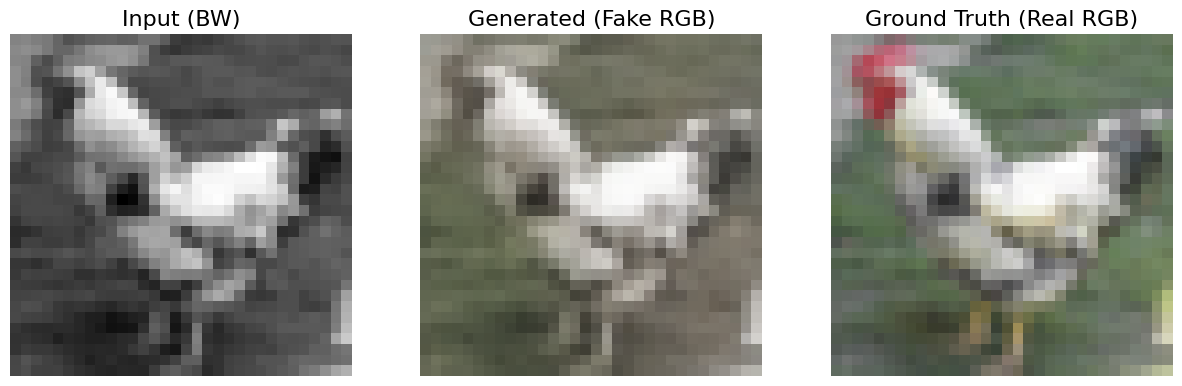

[Epoch 19/20] [Batch 150/391] [G loss: 0.0743] 
[Epoch 19/20] [Batch 160/391] [G loss: 0.0743] 
[Epoch 19/20] [Batch 170/391] [G loss: 0.0743] 
[Epoch 19/20] [Batch 180/391] [G loss: 0.0743] 
[Epoch 19/20] [Batch 190/391] [G loss: 0.0744] 


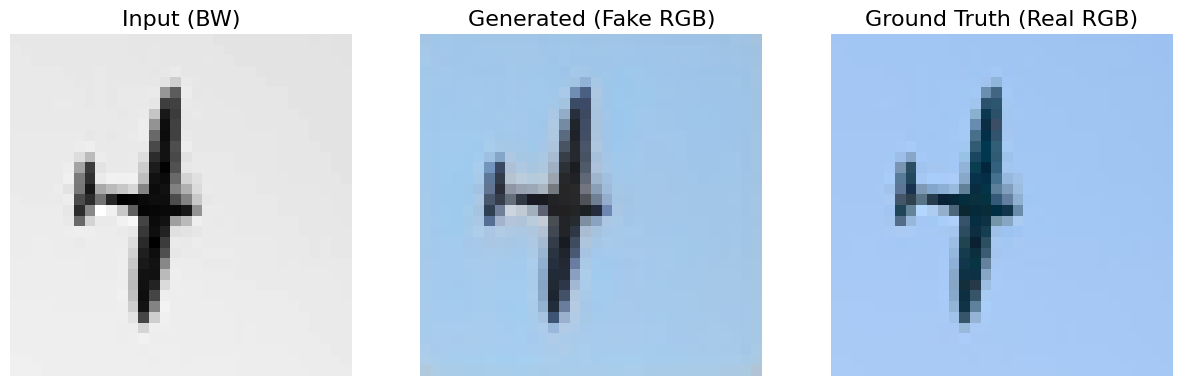

[Epoch 19/20] [Batch 200/391] [G loss: 0.0743] 
[Epoch 19/20] [Batch 210/391] [G loss: 0.0743] 
[Epoch 19/20] [Batch 220/391] [G loss: 0.0743] 
[Epoch 19/20] [Batch 230/391] [G loss: 0.0743] 
[Epoch 19/20] [Batch 240/391] [G loss: 0.0744] 


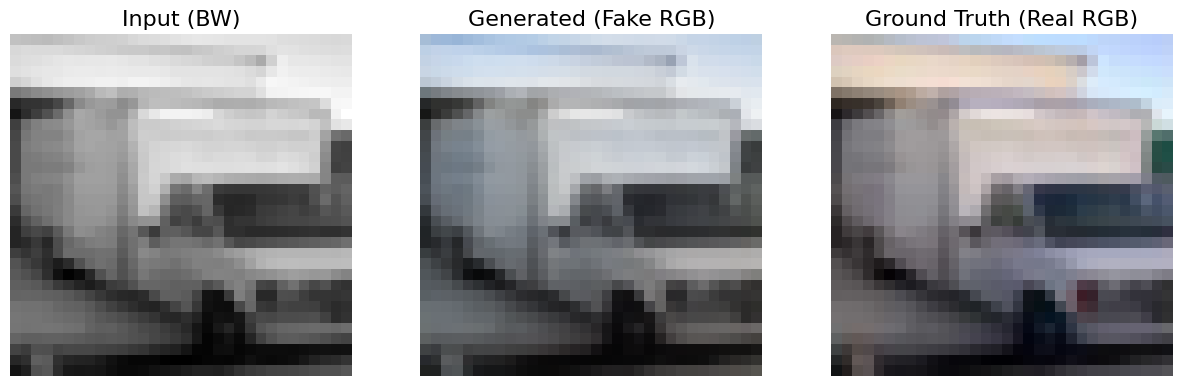

[Epoch 19/20] [Batch 250/391] [G loss: 0.0744] 
[Epoch 19/20] [Batch 260/391] [G loss: 0.0744] 
[Epoch 19/20] [Batch 270/391] [G loss: 0.0744] 
[Epoch 19/20] [Batch 280/391] [G loss: 0.0744] 
[Epoch 19/20] [Batch 290/391] [G loss: 0.0744] 


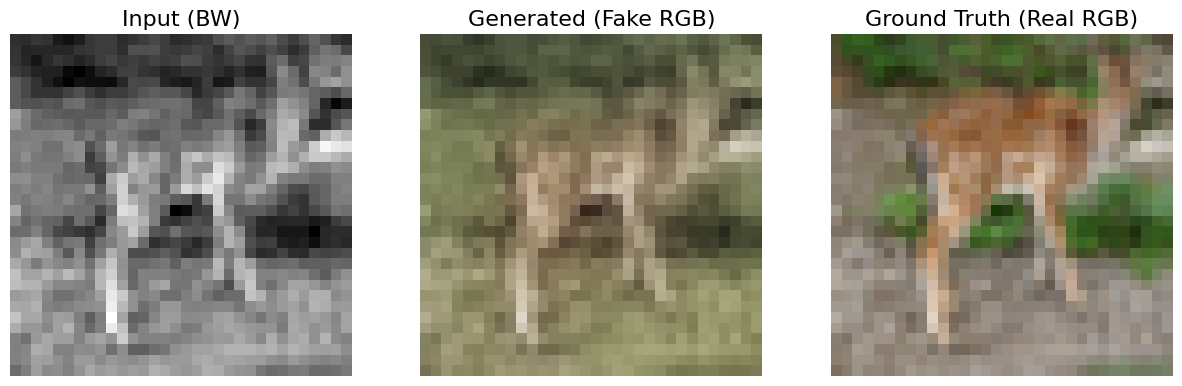

[Epoch 19/20] [Batch 300/391] [G loss: 0.0745] 
[Epoch 19/20] [Batch 310/391] [G loss: 0.0746] 
[Epoch 19/20] [Batch 320/391] [G loss: 0.0745] 
[Epoch 19/20] [Batch 330/391] [G loss: 0.0745] 
[Epoch 19/20] [Batch 340/391] [G loss: 0.0746] 


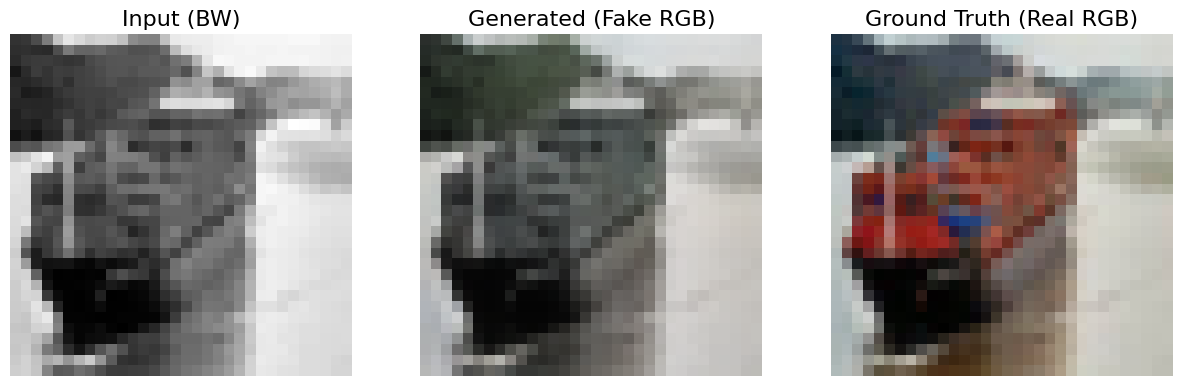

[Epoch 19/20] [Batch 350/391] [G loss: 0.0747] 
[Epoch 19/20] [Batch 360/391] [G loss: 0.0747] 
[Epoch 19/20] [Batch 370/391] [G loss: 0.0747] 
[Epoch 19/20] [Batch 380/391] [G loss: 0.0747] 
[Epoch 19/20] [Batch 390/391] [G loss: 0.0747] 


In [37]:
set_seed(42)

# Training Hyperparameters
img_shape = (32, 32)
num_epochs = 20
batch_size = 128
lr = 2.0e-4
betas = (0.5, 0.999)

# Data
train_dataset = Cifar('CIFAR10', train=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Model, optimizer and criterion (MAE)
generator_mae = CGenerator().to(DEVICE)
optimizer_mae = torch.optim.Adam(generator_mae.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion_mae = nn.L1Loss()

for epoch in range(num_epochs):
    g_avg_loss = []

    for batch_i, (imgs_rgb, imgs_bw) in enumerate(train_loader):
        # Move data to device
        imgs_rgb, imgs_bw = imgs_rgb.to(DEVICE), imgs_bw.to(DEVICE)

        # Generate fake rgb images
        optimizer_mae.zero_grad()
        imgs_rgb_generated = generator_mae(imgs_bw)
        g_loss = criterion_mae(imgs_rgb_generated, imgs_rgb)

        # Backward pass and optimize
        g_loss.backward()
        optimizer_mae.step()

        g_avg_loss.append(g_loss.item())

        # Plot examples
        if batch_i % 50 == 0:
            with torch.no_grad():
                show_colored_images(imgs_rgb, imgs_bw, imgs_rgb_generated)

        # Print progress
        if batch_i % 10 == 0:
            print(f"[Epoch {epoch}/{num_epochs}] [Batch {batch_i}/{len(train_loader)}] "
                  f"[G loss: {np.mean(g_avg_loss):.4f}] ")

# Save model
torch.save(generator_mae.state_dict(), 'generator_mae.pth')

Instead of training the models, we can directly load their pre-trained weights by running:

In [38]:
!wget https://github.com/MatchLab-Imperial/deep-learning-course/raw/master/asset/07_VAE_GAN/cgan_cifar10_epoch20.pth
!wget https://github.com/MatchLab-Imperial/deep-learning-course/raw/master/asset/07_VAE_GAN/cgenerator_mae_cifar10_epoch20.pth

--2026-03-15 23:06:40--  https://github.com/MatchLab-Imperial/deep-learning-course/raw/master/asset/07_VAE_GAN/cgan_cifar10_epoch20.pth
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/MatchLab-Imperial/deep-learning-course/master/asset/07_VAE_GAN/cgan_cifar10_epoch20.pth [following]
--2026-03-15 23:06:40--  https://raw.githubusercontent.com/MatchLab-Imperial/deep-learning-course/master/asset/07_VAE_GAN/cgan_cifar10_epoch20.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 96160593 (92M) [application/octet-stream]
Saving to: ‘cgan_cifar10_epoch20.pth.1’

cgan_cifar10_epoch2 100%[===========

In [39]:
# Pre-trained CGAN
generator_cGAN = CGAN().to(DEVICE)
generator_cGAN.load_state_dict(torch.load('cgan_cifar10_epoch20.pth'))
generator_cGAN.eval()

# Pre-trained MAE model
generator_mae = CGenerator().to(DEVICE)
generator_mae.load_state_dict(torch.load('cgenerator_mae_cifar10_epoch20.pth'))
generator_mae.eval()

CGenerator(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (drop4): Dropout2d(p=0.5, inplace=False)
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (drop5): Dropout2d(p=0.5, inplace=False)
  (up6): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv2d(1024, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (conv6): 

We have loaded both models, and we are ready to compare them. In this task, you are asked to analyse the difference between the quantitative versus the qualitative results. To do so, we provided two pieces of code. The first one will compute the MAE metric for both models in the test dataset. As we know, this metric is widely used on image generation tasks, such as image upsampling, image reconstruction, image translation, and so on.

In [40]:
# Data
test_dataset = Cifar('CIFAR10', train=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Loss
l1_mae, l1_cgan = [], []

with torch.no_grad():  # Disable gradient calculation
    for imgs_rgb, imgs_bw in test_loader:
        imgs_rgb, imgs_bw = imgs_rgb.to(DEVICE), imgs_bw.to(DEVICE)
        imgs_rgb_generated_mae = generator_mae(imgs_bw)
        imgs_rgb_generated_cgan = generator_cGAN(imgs_bw)

        l1_mae.append(F.l1_loss(imgs_rgb_generated_mae, imgs_rgb).item())
        l1_cgan.append(F.l1_loss(imgs_rgb_generated_cgan, imgs_rgb).item())

print("MAE (Trained MAE): {:.4f}".format(np.mean(l1_mae)))
print("MAE (Trained cGAN): {:.4f}".format(np.mean(l1_cgan)))

MAE (Trained MAE): 0.0899
MAE (Trained cGAN): 0.0970


The next piece of code will show coloured examples for both networks, so you can check them visually and discuss which model is better. First, we need to create an iterator object to go through the test dataset:

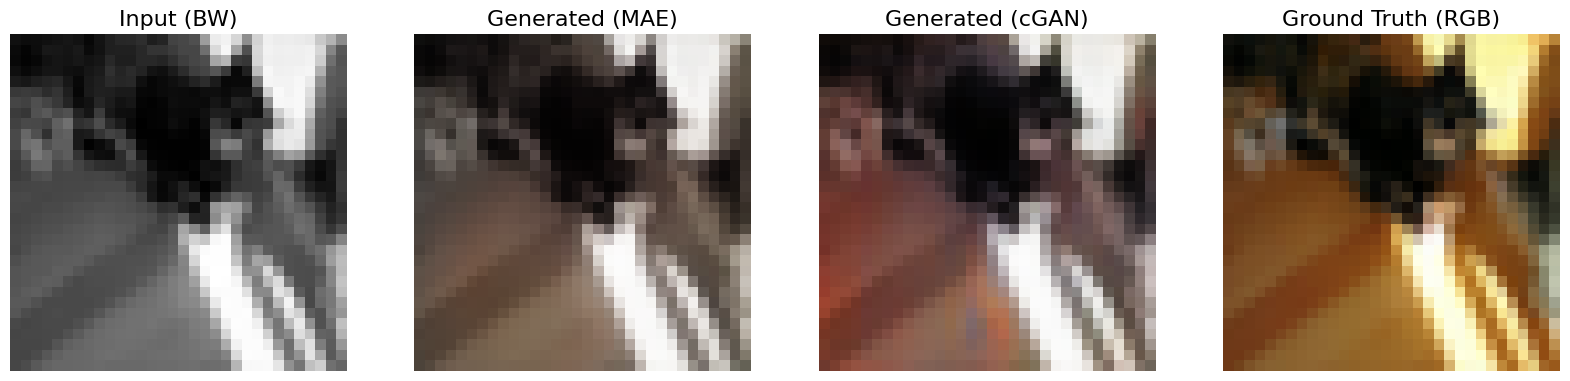

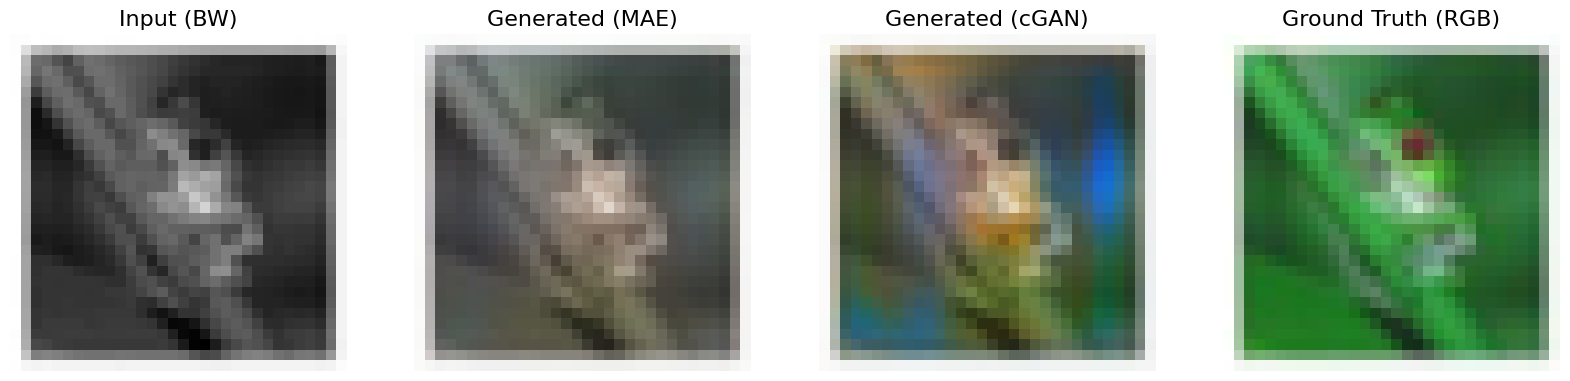

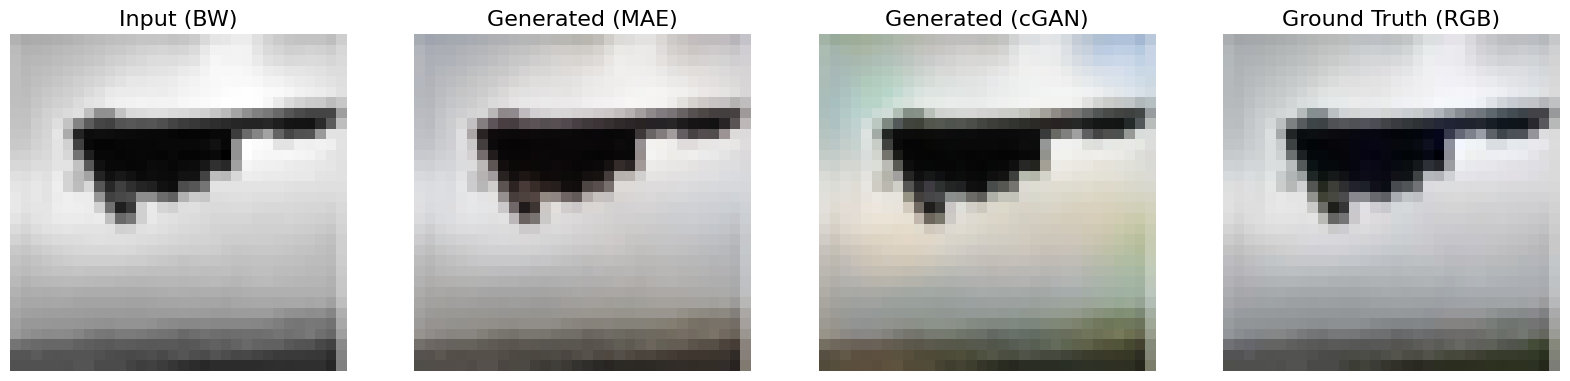

In [41]:
# Change seed and num_samples here to see different samples
set_seed(42)
num_samples = 3

# Data
test_dataset = Cifar('CIFAR10', train=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)

for _ in range(num_samples):
    img_rgb, img_bw = next(iter(test_loader))
    img_rgb, img_bw = img_rgb.to(DEVICE), img_bw.to(DEVICE)

    with torch.no_grad():
        img_rgb_generated_mae = generator_mae(img_bw)
        img_rgb_generated_cgan = generator_cGAN(img_bw)
        show_colored_two_models(img_rgb, img_bw, img_rgb_generated_mae, img_rgb_generated_cgan)

We showed that both models obtain a similar MAE value. If we would only take into account the quantitative metric, as done in many scientific articles, we would say that the MAE model is better. However, in addition to the quantitative results, we need to analyse visually the results produced by the two networks to declare which is the best model.

**Report**


*   Run the previous code to analyse several coloured images for both models. Based on previous results and linked to GAN theory, discuss from the numerical and visual perspective if both models are similar, or whether there is a better one. You can provide in the report visual examples together with their MAE values to support your arguments. The figure of this task can be included in the Appendix. Discussion still needs to go into the main report.